In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import requests
from bs4 import BeautifulSoup
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully!')
stock_sector_map = {
    'AAPL': 'US Technology', 'NVDA': 'US Technology', 'META': 'US Technology',
    'AVGO': 'US Technology', 'GOOGL': 'US Technology',
    'JNJ': 'US Healthcare', 'ABBV': 'US Healthcare', 'LLY': 'US Healthcare',
    'JPM': 'US Financial', 'GS': 'US Financial', 'V': 'US Financial',
    'XOM': 'US Energy', 'MPC': 'US Energy',
    'CAT': 'US Consumer', 'WMT': 'US Consumer', 'COST': 'US Consumer', 'MCD': 'US Consumer',
    'DELTA.BK': 'Thai Stocks', 'ADVANC.BK': 'Thai Stocks', 'KBANK.BK': 'Thai Stocks',
    'PDD': 'Chinese Stocks', 'FUTU': 'Chinese Stocks',
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto',
    'HYG': 'Bonds', 'VCSH': 'Bonds', 'EMLC': 'Bonds',
    'GLD': 'Commodities', 'SLV': 'Commodities', 'COPX': 'Commodities',
}

portfolio_tickers = list(stock_sector_map.keys())
print(f'หุ้นเดิมในพอร์ต: {len(portfolio_tickers)} ตัว')
print(f'กลุ่ม: {len(set(stock_sector_map.values()))} กลุ่ม')
# === 3.1 S&P 500 — ดึงจาก Wikipedia ด้วย pd.read_html (robust กว่า BeautifulSoup) ===
print("📥 ดึงรายชื่อหุ้น S&P 500 จาก Wikipedia...")
try:
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
    resp = requests.get(url, headers=headers, timeout=30)
    from io import StringIO
    tables = pd.read_html(StringIO(resp.text))
    df_sp500 = tables[0]  # ตารางแรกคือ constituents

    # หา column ชื่อ Symbol/Ticker และ GICS Sector
    sym_col = [c for c in df_sp500.columns if 'Symbol' in str(c) or 'Ticker' in str(c)][0]
    sec_col = [c for c in df_sp500.columns if 'GICS Sector' in str(c)][0]

    sp500_tickers = df_sp500[sym_col].str.replace('.', '-', regex=False).tolist()
    sp500_sector_map = dict(zip(
        df_sp500[sym_col].str.replace('.', '-', regex=False),
        df_sp500[sec_col]
    ))

    print(f"  ✅ ได้ {len(sp500_tickers)} ตัว")
except Exception as e:
    print(f"  ❌ ไม่สามารถดึงข้อมูล S&P 500 ได้: {e}")
    sp500_tickers = []
    sp500_sector_map = {}

# === 3.2 SET (Thai Stocks) ===
print("\n📥 รายชื่อหุ้นไทย (SET)...")
thai_tickers_raw = [
    'ADVANC', 'AOT', 'AWC', 'BANPU', 'BBL', 'BDMS', 'BEM', 'BGRIM',
    'BH', 'BTS', 'CBG', 'CENTEL', 'COM7', 'CPALL', 'CPF', 'CPN',
    'CRC', 'DELTA', 'EA', 'EGCO', 'GLOBAL', 'GPSC', 'GULF', 'HMPRO',
    'IVL', 'JMART', 'JMT', 'KBANK', 'KCE', 'KTB', 'KTC',
    'LH', 'MINT', 'MTC', 'OR', 'OSP', 'PTT', 'PTTEP', 'PTTGC',
    'RATCH', 'SAWAD', 'SCB', 'SCC', 'SCGP', 'TISCO', 'TOP',
    'TRUE', 'TTB', 'TU', 'WHA',
    'BEAUTY', 'BCH', 'BCP', 'BJC', 'BLA',
    'GFPT', 'IRPC', 'ITD', 'MAJOR', 'MEGA', 'PLANB',
    'PSL', 'RS', 'SPALI', 'SYNEX',
    'TCAP', 'THANI', 'TPIPP', 'VGI',
]
thai_tickers = [t + '.BK' for t in thai_tickers_raw]
thai_sector_map = {t + '.BK': 'Thai Stocks' for t in thai_tickers_raw}
print(f"  ✅ ได้ {len(thai_tickers)} ตัว")

# === 3.3 Chinese ADRs ===
print("\n📥 รายชื่อหุ้นจีน (ADRs)...")
chinese_tickers = [
    'BABA', 'JD', 'PDD', 'BIDU', 'NIO', 'XPEV', 'LI', 'FUTU',
    'TME', 'BILI', 'IQ', 'ZTO', 'MNSO', 'VNET', 'DIDI',
    'TAL', 'EDU', 'NTES', 'WB', 'HTHT',
]
chinese_sector_map = {t: 'Chinese Stocks' for t in chinese_tickers}
print(f"  ✅ ได้ {len(chinese_tickers)} ตัว")

# === 3.4 ETFs ===
print("\n📥 รายชื่อ ETFs...")
etf_tickers = [
    'TLT', 'IEF', 'SHY', 'LQD', 'HYG', 'VCSH', 'EMLC', 'BND', 'AGG',
    'TIPS', 'MUB', 'BNDX',
    'GLD', 'SLV', 'COPX', 'USO', 'UNG', 'DBA', 'PDBC', 'GSG',
    'PPLT', 'PALL', 'CPER',
    'BTC-USD', 'ETH-USD',
    'EEM', 'VWO', 'EFA', 'VEA', 'MCHI', 'FXI', 'THD',
    'QQQ', 'SPY', 'IWM', 'VTI', 'DIA',
]
etf_sector_map = {
    'TLT': 'Bonds', 'IEF': 'Bonds', 'SHY': 'Bonds', 'LQD': 'Bonds',
    'HYG': 'Bonds', 'VCSH': 'Bonds', 'EMLC': 'Bonds', 'BND': 'Bonds',
    'AGG': 'Bonds', 'TIPS': 'Bonds', 'MUB': 'Bonds', 'BNDX': 'Bonds',
    'GLD': 'Commodities', 'SLV': 'Commodities', 'COPX': 'Commodities',
    'USO': 'Commodities', 'UNG': 'Commodities', 'DBA': 'Commodities',
    'PDBC': 'Commodities', 'GSG': 'Commodities', 'PPLT': 'Commodities',
    'PALL': 'Commodities', 'CPER': 'Commodities',
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto',
    'EEM': 'EM ETF', 'VWO': 'EM ETF', 'EFA': 'Intl ETF', 'VEA': 'Intl ETF',
    'MCHI': 'China ETF', 'FXI': 'China ETF', 'THD': 'Thai ETF',
    'QQQ': 'US ETF', 'SPY': 'US ETF', 'IWM': 'US ETF', 'VTI': 'US ETF', 'DIA': 'US ETF',
}
print(f"  ✅ ได้ {len(etf_tickers)} ตัว")

# === รวมทั้งหมด ===
all_tickers = list(set(sp500_tickers + thai_tickers + chinese_tickers + etf_tickers + portfolio_tickers))
all_tickers.sort()

all_sector_map = {}
all_sector_map.update(sp500_sector_map)
all_sector_map.update(thai_sector_map)
all_sector_map.update(chinese_sector_map)
all_sector_map.update(etf_sector_map)

print(f"\n🎯 รวมทั้งหมด: {len(all_tickers)} ตัว (หลังลบ duplicates)")

import os
import time
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

# สมมติว่ามีตัวแปร all_tickers ถูกประกาศไว้แล้วก่อนหน้านี้
# all_tickers = [...]

start_date='2015-01-01' 
end_date='2024-01-01'

print(f"ช่วงเวลา: {start_date} ถึง {end_date}")
print("⏳ กรุณารอสักครู่...\n")

batch_size = 700
all_data_list = []
tickers_to_download = []
all_data = pd.DataFrame()

# 1. ตรวจสอบไฟล์และหา Tickers ที่ต้องดาวน์โหลด
if os.path.exists('all_data_10_year.csv'):
    print("📂 พบไฟล์ all_data.csv อยู่แล้ว, กำลังโหลด...")
    all_data = pd.read_csv('all_data.csv', index_col=0, parse_dates=True)
    existing_tickers = set(all_data.columns)
    tickers_to_download = [t for t in all_tickers if t not in existing_tickers]
    
    if tickers_to_download:
        print(f"⚠️ พบ {len(tickers_to_download)} ตัวที่ยังไม่มีข้อมูลในไฟล์:")
        print(", ".join(tickers_to_download))
        print("⏳ กำลังดาวน์โหลดข้อมูลที่ขาดหาย...")
    else:
        print("✅ ข้อมูลครบถ้วนแล้ว ไม่มีตัวไหนขาดหาย")
else:        
    tickers_to_download = all_tickers
    print(f"กำลังดาวน์โหลดข้อมูลใหม่ทั้งหมด {len(tickers_to_download)} ตัว...")

# 2. วนลูปดาวน์โหลดเฉพาะ Tickers ที่ต้องการ
if tickers_to_download:
    for i in range(0, len(tickers_to_download), batch_size):
        batch = tickers_to_download[i:i+batch_size]
        batch_num = i // batch_size + 1
        total_batches = (len(tickers_to_download) + batch_size - 1) // batch_size
        print(f"  Batch {batch_num}/{total_batches}: downloading {len(batch)} tickers...", end=" ")
        
        try:
            batch_data = yf.download(batch, start=start_date, end=end_date, auto_adjust=True, threads=True)
            # Handle MultiIndex columns from yf.download
            if isinstance(batch_data.columns, pd.MultiIndex):
                batch_close = batch_data['Close']
            else:
                # Single ticker case
                batch_close = batch_data[['Close']].rename(columns={'Close': batch[0]})
            
            all_data_list.append(batch_close)
            n_cols = batch_close.shape[1] if isinstance(batch_close, pd.DataFrame) else 1
            print(f"✅ ได้ {n_cols} ตัว")
        except Exception as e:
            print(f"❌ Error: {e}")
        
        time.sleep(1)

# 3. นำข้อมูลใหม่มารวมกับข้อมูลเดิม (ตรวจสอบก่อน concat)
if all_data_list:
    new_data = pd.concat(all_data_list, axis=1)
    
    # ถ้ารวมกับไฟล์เดิมที่มีอยู่
    if not all_data.empty:
        all_data = pd.concat([all_data, new_data], axis=1)
    else:
        all_data = new_data
        
    all_data = all_data.loc[:, ~all_data.columns.duplicated()]
    all_data.to_csv('all_data.csv')
    print("💾 อัปเดตและบันทึกไฟล์ all_data.csv เรียบร้อยแล้ว")

print(f"\n📊 สรุปจำนวนข้อมูลทั้งหมด: {all_data.shape[1]} ตัว, {all_data.shape[0]} วัน")

✅ Libraries loaded successfully!
หุ้นเดิมในพอร์ต: 30 ตัว
กลุ่ม: 10 กลุ่ม
📥 ดึงรายชื่อหุ้น S&P 500 จาก Wikipedia...
  ✅ ได้ 503 ตัว

📥 รายชื่อหุ้นไทย (SET)...
  ✅ ได้ 69 ตัว

📥 รายชื่อหุ้นจีน (ADRs)...
  ✅ ได้ 20 ตัว

📥 รายชื่อ ETFs...
  ✅ ได้ 37 ตัว

🎯 รวมทั้งหมด: 629 ตัว (หลังลบ duplicates)
ช่วงเวลา: 2015-01-01 ถึง 2024-01-01
⏳ กรุณารอสักครู่...

กำลังดาวน์โหลดข้อมูลใหม่ทั้งหมด 629 ตัว...
  Batch 1/1: downloading 629 tickers... 

[****                   8%                       ]  53 of 629 completed$GULF.BK: possibly delisted; no price data found  (1d 2015-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420045200, endDate = 1704042000")
[*****                 11%                       ]  67 of 629 completed$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1704085200")
[********              16%                       ]  102 of 629 completed$SNDK: possibly delisted; no price data found  (1d 2015-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1704085200")
[************          26%                       ]  163 of 629 completed$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1704085200")
[**********************47%                       ]  294 of 629 

✅ ได้ 629 ตัว
💾 อัปเดตและบันทึกไฟล์ all_data.csv เรียบร้อยแล้ว

📊 สรุปจำนวนข้อมูลทั้งหมด: 629 ตัว, 3287 วัน


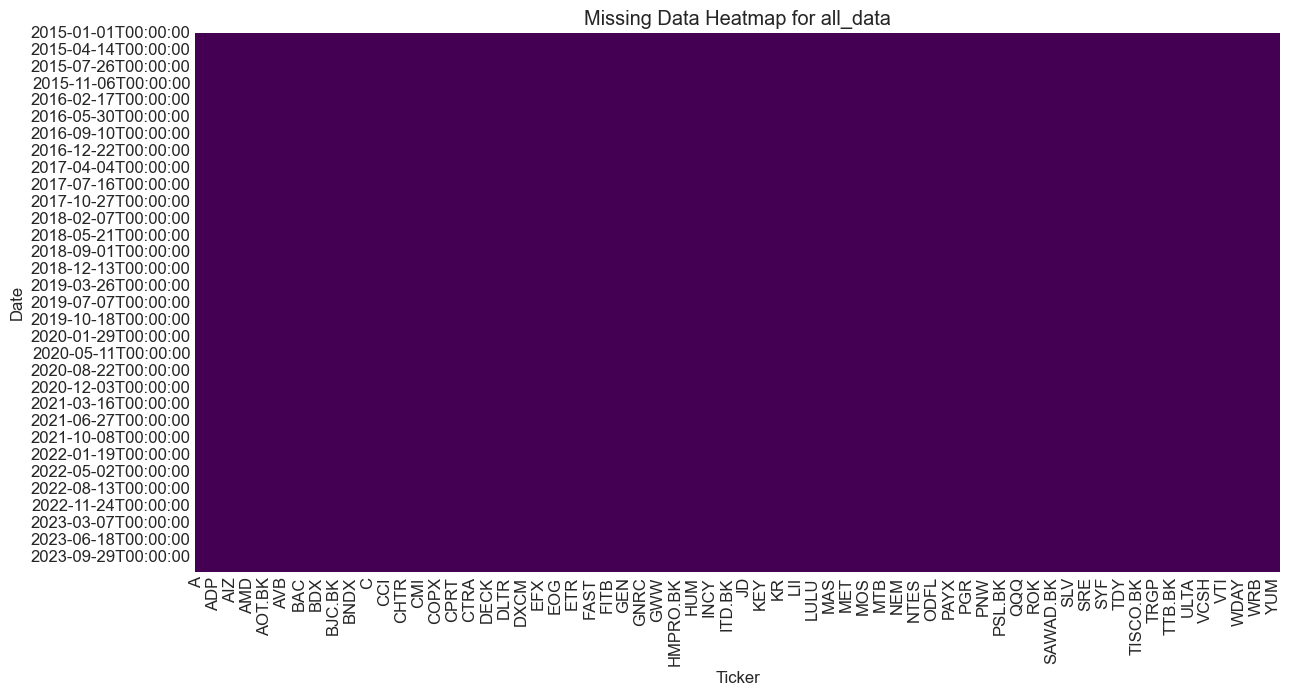

[*********************100%***********************]  1 of 1 completed

  USD/THB range: 29.68 - 38.30

Converted 511 USD assets to THB
Thai assets (60): already in THB


In [2]:
# Define the maximum allowed consecutive gap (e.g., 30 trading days)
max_gap = 252

# Find columns that have a gap of NaNs larger than max_gap
mask = all_data.isnull().rolling(window=max_gap).sum()
cols_with_long_strips = (mask == max_gap).any()

# Filter them out
data_filtered = all_data.loc[:, ~cols_with_long_strips].copy()
data_filtered = data_filtered.ffill().bfill()
sns.heatmap(data_filtered.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap for all_data')
plt.show()
# Currency Conversion: All Prices to THB
data_filtered = data_filtered.copy()
print("Downloading USD/THB exchange rate...")
try:
    usdthb_raw = yf.download("USDTHB=X", start=start_date, end=end_date, auto_adjust=True)
    if isinstance(usdthb_raw.columns, pd.MultiIndex):
        usdthb = usdthb_raw['Close'].iloc[:, 0]
    else:
        usdthb = usdthb_raw['Close']
    usdthb = usdthb.reindex(data_filtered.index).ffill().bfill()
    print(f"  USD/THB range: {float(usdthb.min()):.2f} - {float(usdthb.max()):.2f}")
except Exception as e:
    print(f"  Warning: Could not download USD/THB ({e})")
    print("  Using fixed rate: 35.00 THB/USD")
    usdthb = pd.Series(35.0, index=data_filtered.index)

data_thb = data_filtered.copy()
thai_cols = [t for t in data_filtered.columns if t.endswith(".BK")]
usd_cols = [t for t in data_filtered.columns if not t.endswith(".BK")]

for ticker in usd_cols:
    data_thb[ticker] = data_filtered[ticker] * usdthb.values.flatten()

print(f"\nConverted {len(usd_cols)} USD assets to THB")
print(f"Thai assets ({len(thai_cols)}): already in THB")

data = data_thb



In [3]:
from pathlib import Path
import json

CONFIG_DIR = Path('config')
SETTINGS_PATH = CONFIG_DIR / 'settings.json'
ASSETS_PATH = CONFIG_DIR / 'assets.csv'

with SETTINGS_PATH.open() as f:
    settings = json.load(f)

BASE_CURRENCY = settings.get('base_currency', 'THB')
RANDOM_SEED = settings.get('random_seed', 42)
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

DATA_CFG = settings.get('data', {})
start_date = datetime.fromisoformat(DATA_CFG['start_date']) if DATA_CFG.get('start_date') else datetime.now() - timedelta(days=365 * 4)
end_date = datetime.fromisoformat(DATA_CFG['end_date']) if DATA_CFG.get('end_date') else datetime.now()

portfolio_cfg = settings.get('portfolio', {})
PORTFOLIO_VALUE = portfolio_cfg.get('value', 1_000_000)

currency_cfg = settings.get('currency', {})
FX_TICKERS = currency_cfg.get('fx_pairs', {})

quality_cfg = settings.get('quality_checks', {})
MAX_ABS_DAILY_RETURN = quality_cfg.get('max_abs_daily_return', 0.25)
MAX_ANNUAL_RETURN = quality_cfg.get('max_annual_return', 1.5)

mc_cfg = settings.get('monte_carlo', {})
NUM_MONTE_CARLO = mc_cfg.get('num_portfolios', 5000)

try:
    # Download US 10Y Treasury yield
    tnx = yf.download("^TNX", period="3mo", auto_adjust=True)["Close"]
    RISK_FREE_RATE = float(tnx['^TNX'].iloc[-1]) / 100  # convert from % to decimal
except:
    RISK_FREE_RATE = 0.045  # fallback: 4.5%


[*********************100%***********************]  1 of 1 completed


# Asset Selection


In [4]:
returns = data.pct_change().dropna()

if not returns.empty:
    annual_returns = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)
    sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annual_volatility if annual_volatility.sum() != 0 else pd.Series([0] * len(annual_returns), index=annual_returns.index)

    all_summary = pd.DataFrame({
        'Sector': [all_sector_map.get(t, 'Unknown') for t in returns.columns],
        'Annual Return (%)': (annual_returns * 100).round(2),
        'Annual Vol (%)': (annual_volatility * 100).round(2),
        'Sharpe Ratio': sharpe_ratios.round(3),
    })
    
    print(f"คำนวณสถิติได้: {len(all_summary)} ตัว")
    print(f"\nTop 50 Sharpe Ratio (ทุกตลาด):")
    print("=" * 70)
    display(all_summary.sort_values('Sharpe Ratio', ascending=False).head(50))
else:
    print("ไม่มีข้อมูลสำหรับการคำนวณสถิติ")
    sharpe_ratios = pd.Series(dtype=float)


คำนวณสถิติได้: 571 ตัว

Top 50 Sharpe Ratio (ทุกตลาด):


,Sector,Annual Return (%),Annual Vol (%),Sharpe Ratio
Ticker,,,,
NVDA,Information Technology,44.03,40.70,0.976
BTC-USD,Crypto,55.67,59.27,0.866
AMD,Information Technology,43.24,49.91,0.780
CDNS,Information Technology,24.41,26.85,0.748
FICO,Information Technology,26.01,29.70,0.731
MSCI,Financials,23.49,26.25,0.730
SNPS,Information Technology,22.45,24.90,0.728
CPRT,Industrials,21.27,23.47,0.722
AVGO,Information Technology,25.33,30.07,0.699


In [91]:
returns = np.log(data / data.shift(1)).dropna()

if not returns.empty:
    annual_returns = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)
    sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annual_volatility 

    all_summary = pd.DataFrame({
        'Sector': [all_sector_map.get(t, 'Unknown') for t in returns.columns],
        'Annual Return (%)': (annual_returns * 100).round(2),
        'Annual Vol (%)': (annual_volatility * 100).round(2),
        'Sharpe Ratio': sharpe_ratios.round(3),
    })
    
    print(f"คำนวณสถิติได้: {len(all_summary)} ตัว")
    print(f"\nTop 30 Sharpe Ratio from log returns (ทุกตลาด):")
    print("=" * 70)
    display(all_summary.sort_values('Sharpe Ratio', ascending=False).head(30))
else:
    print("ไม่มีข้อมูลสำหรับการคำนวณสถิติ")
    sharpe_ratios = pd.Series(dtype=float)


คำนวณสถิติได้: 571 ตัว

Top 30 Sharpe Ratio from log returns (ทุกตลาด):


,Sector,Annual Return (%),Annual Vol (%),Sharpe Ratio
Ticker,,,,
NVDA,Information Technology,35.83,40.34,0.781
CDNS,Information Technology,20.82,26.74,0.617
CPRT,Industrials,18.51,23.45,0.605
SNPS,Information Technology,19.35,24.88,0.604
MSCI,Financials,20.04,26.23,0.599
FICO,Information Technology,21.66,29.36,0.591
LLY,Health Care,17.99,23.58,0.580
BTC-USD,Crypto,37.92,59.74,0.562
PGR,Financials,15.80,20.89,0.549


In [100]:
import torch

portfolio_cols = returns.columns

if len(portfolio_cols) > 0 and len(returns.columns) > 0:
    corr_all = returns.corr()
    # new_tickers = [t for t in returns.columns if t not in portfolio_tickers]
    # print(f"หุ้นใหม่ที่ไม่ได้อยู่ในพอร์ตเดิม: {len(new_tickers)} ตัว")

    results = []
    for ticker in portfolio_cols:
        if ticker not in corr_all.columns or ticker not in sharpe_ratios.index:
            continue
        
        valid_portfolio_cols = [c for c in portfolio_cols if c in corr_all.columns]
        if len(valid_portfolio_cols) == 0:
            continue
        
        avg_corr = corr_all.loc[ticker, valid_portfolio_cols].mean()
        max_corr = corr_all.loc[ticker, valid_portfolio_cols].max()
        min_corr = corr_all.loc[ticker, valid_portfolio_cols].min()
        sharpe = float(sharpe_ratios.loc[ticker])
        annual_ret = float(annual_returns.loc[ticker]) * 100
        annual_vol = float(annual_volatility.loc[ticker]) * 100
        sector = all_sector_map.get(ticker, 'Unknown')
        
        if pd.isna(sharpe) or pd.isna(avg_corr):
            continue
        
        results.append({
            'Ticker': ticker,
            'Sector': sector,
            'Annual Return (%)': round(annual_ret, 2),
            'Annual Vol (%)': round(annual_vol, 2),
            'Sharpe': round(sharpe, 3),
            'Avg Corr (vs Portfolio)': round(float(avg_corr), 3),
            'Max Corr': round(float(max_corr), 3),
            'Min Corr': round(float(min_corr), 3),
        })

    if results:
        candidates_df = pd.DataFrame(results)
        good_candidates = candidates_df[candidates_df['Sharpe'] > 0.2].copy()
        
        if not good_candidates.empty:
            good_candidates['Diversification Score'] = (
                good_candidates['Sharpe'] * (1 - good_candidates['Avg Corr (vs Portfolio)'])
            ).round(3)
            good_candidates = good_candidates.sort_values('Diversification Score', ascending=False)

            print(f"\nหุ้นใหม่ที่ผ่านเกณฑ์ (Sharpe > 0.2): {len(good_candidates)} ตัว")

            # === Stratified Top 30: ให้ครบทุก 10 กลุ่ม (Sector) ===
            target_sectors = [
                'Bonds', 'Chinese Stocks', 'Commodities', 'Crypto', 'Thai Stocks',
                'US Consumer', 'US Energy', 'US Financial', 'US Healthcare', 'US Technology'
            ]
            TOP_N = 30
            MIN_PER_SECTOR = 1  # เลือกอย่างน้อย 1 ตัวต่อกลุ่ม (ตามคอมเมนต์เดิมเขียน 3 แต่ตัวแปรคือ 1)

            selected = pd.DataFrame()
            remaining = good_candidates.copy()

            # ขั้นที่ 1: เลือกหุ้นดีสุดจากแต่ละกลุ่ม (Sector) อย่างน้อย MIN_PER_SECTOR ตัว
            for sector in target_sectors:
                sector_stocks = remaining[remaining['Sector'] == sector]
                if not sector_stocks.empty:
                    take_n = min(MIN_PER_SECTOR, len(sector_stocks))
                    top_sector = sector_stocks.head(take_n)
                    selected = pd.concat([selected, top_sector])
                    remaining = remaining[~remaining['Ticker'].isin(top_sector['Ticker'])]

            # ขั้นที่ 2: เติมที่เหลือด้วยหุ้นที่มี Diversification Score สูงสุด
            slots_left = TOP_N - len(selected)
            if slots_left > 0 and not remaining.empty:
                fill = remaining.head(slots_left)
                selected = pd.concat([selected, fill])

            # จัดเรียงตาม Diversification Score
            diversification_selected = selected.sort_values('Diversification Score', ascending=False)

            # =========================================================================
            # การคำนวณ Real Portfolio Metrics ด้วย PyTorch บน GPU
            # =========================================================================
            selected_tickers = diversification_selected['Ticker'].tolist()
            
            # 1. ดึงผลตอบแทนรายวันเฉพาะหุ้นที่ผ่านการคัดเลือกและกำจัดค่า NaNs
            valid_returns = returns[selected_tickers].fillna(0)
            
            # 2. ตั้งค่า PyTorch Device
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            
            # 3. แปลงข้อมูลเป็น Tensor (N_Days x N_Assets)
            returns_tensor = torch.tensor(valid_returns.values, dtype=torch.float32, device=device)
            n_assets = returns_tensor.shape[1]
            
            # 4. กำหนดน้ำหนักการลงทุนแบบเท่ากัน (Equal Weight)
            weights = torch.ones(n_assets, dtype=torch.float32, device=device) / n_assets
            
            # 5. คำนวณผลตอบแทนรายวันของพอร์ตโฟลิโอ (พอร์ตโฟลิโอ Return = Matrix Multiplication)
            port_daily_returns = torch.matmul(returns_tensor, weights)
            
            # 6. คำนวณแบบ Annualized (สมมติ 252 วันทำการ)
            days_in_year = torch.tensor(252.0, device=device)
            real_port_annual_return = port_daily_returns.mean() * days_in_year
            real_port_annual_vol = port_daily_returns.std(unbiased=True) * torch.sqrt(days_in_year)
            
            # 7. คำนวณ Real Sharpe Ratio (สมมติ Risk-Free Rate = 0)
            real_port_sharpe = real_port_annual_return / real_port_annual_vol
            
            # 8. ดึงค่าจาก Tensor กลับมาเป็น Float ธรรมดาเพื่อใช้แสดงผล
            val_real_return = real_port_annual_return.item() * 100
            val_real_vol = real_port_annual_vol.item() * 100
            val_real_sharpe = real_port_sharpe.item()
            # =========================================================================

            # แสดงสรุปจำนวนหุ้นในแต่ละกลุ่ม
            print("\n" + "=" * 100)
            print("🏆 Top 30 หุ้นที่เหมาะกับพอร์ตมากที่สุด (Diversification Score สูงสุด)")
            print("   ✅ คัดเลือกแบบ Stratified: มีตัวแทนจากทุกกลุ่ม (Sector)")
            print("=" * 100)
            print("   Diversification Score = Sharpe × (1 - Avg Corr)")
            
            # === แสดงข้อมูลสรุปของ Best Portfolio ===
            print("\n" + "=" * 100)
            print("🌟 Best Portfolio Selection Summary (Equal Weight Assumed)")
            print("=" * 100)
            print(f"Average Correlation : {diversification_selected['Avg Corr (vs Portfolio)'].mean():.4f}")
            print(f"Average Diversification Score (Fitness):    {diversification_selected['Diversification Score'].mean():.4f}")
            print("-" * 50)
            print(f"Real Annual Return of this Portfolio:     {val_real_return:.4f}%")
            print(f"Real Annual Volatility of this Portfolio: {val_real_vol:.4f}%")
            print(f"Real Sharpe Ratio of this Portfolio:      {val_real_sharpe:.4f}")
            print("=" * 100 + "\n")

            print("\n📊 สรุปจำนวนหุ้นในแต่ละกลุ่ม:")
            sector_counts = diversification_selected.groupby('Sector').size().reset_index(name='จำนวน')
            for _, row in sector_counts.iterrows():
                print(f"   • {row['Sector']:20s}: {row['จำนวน']} ตัว")
            print(f"   {'─' * 30}")
            print(f"   รวมทั้งหมด: {len(diversification_selected)} ตัว\n")

            display(diversification_selected.set_index('Ticker'))

        else:
            print("\n❌ ไม่มีหุ้นใหม่ที่มี Sharpe > 0.2") # ปรับข้อความให้ตรงกับเงื่อนไขในโค้ด
            good_candidates = pd.DataFrame()
    else:
        print("\n❌ ไม่มีหุ้นใหม่ที่สามารถคำนวณหา Correlation ได้ (อาจจะข้อมูลไม่พอ)")
        good_candidates = pd.DataFrame()
else:
    print("\n❌ ไม่มีข้อมูลหุ้นเพียงพอในการเปรียบเทียบ")
    good_candidates = pd.DataFrame()


หุ้นใหม่ที่ผ่านเกณฑ์ (Sharpe > 0.2): 193 ตัว

🏆 Top 30 หุ้นที่เหมาะกับพอร์ตมากที่สุด (Diversification Score สูงสุด)
   ✅ คัดเลือกแบบ Stratified: มีตัวแทนจากทุกกลุ่ม (Sector)
   Diversification Score = Sharpe × (1 - Avg Corr)

🌟 Best Portfolio Selection Summary (Equal Weight Assumed)
Average Correlation : 0.3040
Average Diversification Score (Fitness):    0.3449
--------------------------------------------------
Real Annual Return of this Portfolio:     19.8781%
Real Annual Volatility of this Portfolio: 17.6120%
Real Sharpe Ratio of this Portfolio:      1.1287


📊 สรุปจำนวนหุ้นในแต่ละกลุ่ม:
   • Chinese Stocks      : 1 ตัว
   • Consumer Discretionary: 1 ตัว
   • Consumer Staples    : 1 ตัว
   • Crypto              : 1 ตัว
   • Energy              : 1 ตัว
   • Financials          : 3 ตัว
   • Health Care         : 3 ตัว
   • Industrials         : 5 ตัว
   • Information Technology: 10 ตัว
   • Thai Stocks         : 4 ตัว
   ──────────────────────────────
   รวมทั้งหมด: 30 ตัว



,Sector,Annual Return (%),Annual Vol (%),Sharpe,Avg Corr (vs Portfolio),Max Corr,Min Corr,Diversification Score
Ticker,,,,,,,,
NVDA,Information Technology,35.83,40.34,0.781,0.334,1.0,-0.013,0.520
BTC-USD,Crypto,37.92,59.74,0.562,0.128,1.0,-0.036,0.490
COM7.BK,Thai Stocks,20.14,32.25,0.491,0.060,1.0,-0.058,0.462
LLY,Health Care,17.99,23.58,0.580,0.271,1.0,-0.016,0.423
AMD,Information Technology,31.09,49.02,0.546,0.263,1.0,-0.024,0.402
CDNS,Information Technology,20.82,26.74,0.617,0.379,1.0,-0.031,0.383
SNPS,Information Technology,19.35,24.88,0.604,0.390,1.0,-0.019,0.368
PGR,Financials,15.80,20.89,0.549,0.335,1.0,-0.045,0.365
CPRT,Industrials,18.51,23.45,0.605,0.401,1.0,-0.022,0.362


In [103]:
import torch
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

valid_tickers = data.columns

prices_tensor = torch.tensor(data.values, dtype=torch.float32, device=device)

# คำนวณ Log Return บน GPU
returns_gpu = torch.log(prices_tensor[1:] / prices_tensor[:-1])
n_samples, n_features = returns_gpu.shape


# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
def ledoit_wolf_covariance_gpu(X):
    X_centered = X - torch.mean(X, dim=0)
    sample_cov = torch.matmul(X_centered.T, X_centered) / (n_samples - 1)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = torch.eye(n_features, device=device) * mean_var
    delta = 0.2 
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    return shrunk_cov, sample_cov


def ledoit_wolf_covariance_gpu_dynamic(X):
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    # ทฤษฎี LW ดั้งเดิมมักใช้ n_samples แทน n_samples-1 เพื่อความสะดวกในสูตรคณิตศาสตร์
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # ---------------------------------------------------------
    # ส่วนที่เพิ่มเข้ามา: คำนวณ Dynamic Delta (Optimal Shrinkage)
    # ---------------------------------------------------------
    
    # คำนวณ Squared Distance ระหว่าง Sample Covariance และ Target (d^2)
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    
    # คำนวณ Variance ของสมาชิกใน Sample Covariance (b^2)
    # ใช้การคูณแบบ Element-wise ของข้อมูลที่ Center แล้ว
    X_squared = X_centered ** 2
    # ค่าประมาณความแปรปรวนแบบ Asymptotic
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    # คำนวณค่า Optimal Delta แบบ Dynamic
    # ป้องกันกรณีที่ b_squared มากกว่า d_squared หรือค่า delta หลุดกรอบ [0, 1]
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # ---------------------------------------------------------
    
    # 4. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()

shrunk_cov_gpu, sample_cov_gpu, delta_value = ledoit_wolf_covariance_gpu_dynamic(returns_gpu)

# 5. แปลงเป็น Correlation Matrix
vols = torch.sqrt(torch.diag(shrunk_cov_gpu))
outer_vols = torch.outer(vols, vols)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

# ป้องกันค่าที่เกินขอบเขต [-1, 1] จาก Floating Point Error
corr_matrix_gpu = torch.clamp(corr_matrix_gpu, -1.0, 1.0)


# ก่อนเริ่มบล็อกนี้ สมมติว่ามี valid_tickers, portfolio_cols, portfolio_tickers, all_sector_map อยู่แล้ว
# และ shrunk_cov_gpu, returns_gpu, corr_matrix_gpu ถูกคำนวณเสร็จเรียบร้อยบน GPU

import math

TRADING_DAYS = 252

# ---------------------------------------------------------
# 6. คำนวณ Metrics เชิงลึกจากข้อมูล GPU (Ledoit-Wolf & Log Returns)
# ---------------------------------------------------------
# 6.1 คำนวณ Annual Return จากค่าเฉลี่ยของ Log Returns
mean_daily_returns_gpu = torch.mean(returns_gpu, dim=0)
annual_returns_gpu = mean_daily_returns_gpu * TRADING_DAYS

# 6.2 คำนวณ Annual Volatility จากเส้นทแยงมุมของ Ledoit-Wolf Covariance Matrix
# ค่าที่ได้จะมีความเสถียรมากกว่า Sample Variance ทั่วไป
daily_vols_gpu = torch.sqrt(torch.diag(shrunk_cov_gpu))
annual_volatility_gpu = daily_vols_gpu * math.sqrt(TRADING_DAYS)

# 6.3 คำนวณ Sharpe Ratio (สมมติ Risk-Free Rate = 0 เพื่อการเปรียบเทียบ)
sharpe_ratios_gpu =  (annual_returns_gpu - RISK_FREE_RATE) / annual_volatility_gpu 

# แปลงข้อมูลจาก GPU Tensor กลับเป็น Pandas Series เพื่อแมปกับชื่อหุ้น (Ticker)
lw_annual_returns = pd.Series(annual_returns_gpu.cpu().numpy(), index=valid_tickers)
lw_annual_volatility = pd.Series(annual_volatility_gpu.cpu().numpy(), index=valid_tickers)
lw_sharpe_ratios = pd.Series(sharpe_ratios_gpu.cpu().numpy(), index=valid_tickers)
lw_corr_all = pd.DataFrame(corr_matrix_gpu.cpu().numpy(), index=valid_tickers, columns=valid_tickers)


# ---------------------------------------------------------
# 7. คัดเลือกหุ้นเข้าพอร์ตโดยอิงจาก Ledoit-Wolf Metrics
# ---------------------------------------------------------
if len(portfolio_cols) > 0 and len(valid_tickers) > 0:
    # new_tickers = [t for t in valid_tickers if t not in portfolio_tickers]
    # print(f"🔍 พบหุ้นใหม่ที่ไม่ได้อยู่ในพอร์ตเดิมจำนวน: {len(new_tickers)} ตัว")

    results = []
    for ticker in portfolio_cols:
        if ticker not in lw_corr_all.columns or ticker not in lw_sharpe_ratios.index:
            continue
        
        valid_portfolio_cols = [c for c in portfolio_cols if c in lw_corr_all.columns]
        if len(valid_portfolio_cols) == 0:
            continue
        
        # ดึงค่าพารามิเตอร์ที่คำนวณจากชุดข้อมูล Robust (Ledoit-Wolf Adjusted)
        avg_corr = lw_corr_all.loc[ticker, valid_portfolio_cols].mean()
        max_corr = lw_corr_all.loc[ticker, valid_portfolio_cols].max()
        min_corr = lw_corr_all.loc[ticker, valid_portfolio_cols].min()
        
        sharpe = float(lw_sharpe_ratios.loc[ticker])
        annual_ret = float(lw_annual_returns.loc[ticker]) * 100
        annual_vol = float(lw_annual_volatility.loc[ticker]) * 100
        sector = all_sector_map.get(ticker, 'Unknown')
        
        if pd.isna(sharpe) or pd.isna(avg_corr):
            continue
        
        results.append({
            'Ticker': ticker,
            'Sector': sector,
            'LW Annual Return (%)': round(annual_ret, 2),
            'LW Annual Vol (%)': round(annual_vol, 2),
            'LW Sharpe': round(sharpe, 3),
            'Avg Corr (vs Portfolio)': round(float(avg_corr), 3),
            'Max Corr': round(float(max_corr), 3),
            'Min Corr': round(float(min_corr), 3),
        })
    candidates_df = pd.DataFrame([])
    if results:
        candidates_df = pd.DataFrame(results)
        # คัดกรองเบื้องต้นด้วย Sharpe Ratio ที่ปรับสมูทแล้ว (LW Sharpe > 0.5)
        good_candidates = candidates_df[candidates_df['LW Sharpe'] > 0.2].copy()
        
        if not good_candidates.empty:
            # คำนวณคะแนนกระจายความเสี่ยง โดยให้เครดิตหุ้นที่ Correlation ต่ำและผลตอบแทนปรับด้วยความเสี่ยงสูง
            good_candidates['Diversification Score'] = (
                good_candidates['LW Sharpe'] * (1 - good_candidates['Avg Corr (vs Portfolio)'])
            ).round(3)
            good_candidates = good_candidates.sort_values('Diversification Score', ascending=False)

            print(f"✅ หุ้นใหม่ที่ผ่านเกณฑ์ (LW Sharpe > 0.2): {len(good_candidates)} ตัว")

            # === Stratified Top 30: กระจายความเสี่ยงครอบคลุม 10 กลุ่ม (Sector) ===
            target_sectors = [
                'Bonds', 'Chinese Stocks', 'Commodities', 'Crypto', 'Thai Stocks',
                'US Consumer', 'US Energy', 'US Financial', 'US Healthcare', 'US Technology'
            ]
            TOP_N = 30
            MIN_PER_SECTOR = 1

            selected = pd.DataFrame()
            remaining = good_candidates.copy()

            # ขั้นที่ 1: การันตีพื้นที่ให้แต่ละกลุ่มอุตสาหกรรม (อย่างน้อย MIN_PER_SECTOR ตัว)
            for sector in target_sectors:
                sector_stocks = remaining[remaining['Sector'] == sector]
                if not sector_stocks.empty:
                    take_n = min(MIN_PER_SECTOR, len(sector_stocks))
                    top_sector = sector_stocks.head(take_n)
                    selected = pd.concat([selected, top_sector])
                    remaining = remaining[~remaining['Ticker'].isin(top_sector['Ticker'])]

            # ขั้นที่ 2: เติมโควต้าที่เหลือด้วยหุ้นที่มี Diversification Score สูงสุดจากกลุ่มใดก็ได้
            slots_left = TOP_N - len(selected)
            if slots_left > 0 and not remaining.empty:
                fill = remaining.head(slots_left)
                selected = pd.concat([selected, fill])

            # จัดเรียงผลลัพธ์สุดท้าย
            lw_diversification_selected = selected.sort_values('Diversification Score', ascending=False)

            # =========================================================================
            # การคำนวณ Real Portfolio Metrics ด้วย Ledoit-Wolf Covariance บน PyTorch (GPU)
            # =========================================================================
            selected_tickers = lw_diversification_selected['Ticker'].tolist()
            
            # 1. หา Index ของหุ้นที่ถูกเลือก เพื่อไป Slice ข้อมูลจาก Tensor บน GPU
            valid_tickers_list = list(valid_tickers)
            selected_indices = [valid_tickers_list.index(t) for t in selected_tickers]
            
            # 2. ดึง Annual Returns เฉพาะหุ้นที่อยู่ในพอร์ต
            selected_annual_returns = annual_returns_gpu[selected_indices]
            
            # 3. ดึง Covariance Matrix ย่อยเฉพาะหุ้นในพอร์ต (Subset Matrix) และคูณแปลงเป็นรายปี
            selected_cov_matrix = shrunk_cov_gpu[selected_indices][:, selected_indices] * TRADING_DAYS
            
            # 4. กำหนดน้ำหนักแบบเท่ากัน (Equal Weight) บน GPU
            n_selected = len(selected_tickers)
            weights = torch.ones(n_selected, dtype=torch.float32, device=device) / n_selected
            
            # 5. คำนวณ Portfolio Annual Return (R_p = w^T * R)
            real_port_annual_return = torch.dot(weights, selected_annual_returns)
            
            # 6. คำนวณ Portfolio Annual Volatility ด้วยสมการ Sigma_p = sqrt(w^T * Cov * w)
            # ใช้ unsqueeze เพื่อแปลงมิติเป็น (1, N) และ (N, 1) สำหรับการคูณเมทริกซ์
            port_var = torch.matmul(weights.unsqueeze(0), torch.matmul(selected_cov_matrix, weights.unsqueeze(1)))
            real_port_annual_vol = torch.sqrt(port_var.squeeze())
            
            # 7. คำนวณ Real Sharpe Ratio ของพอร์ต
            real_port_sharpe = (real_port_annual_return - RISK_FREE_RATE) / real_port_annual_vol
            
            # 8. แปลงข้อมูลจาก GPU Tensor กลับเป็น Float สำหรับแสดงผล
            val_real_return = real_port_annual_return.item() * 100
            val_real_vol = real_port_annual_vol.item() * 100
            val_real_sharpe = real_port_sharpe.item()
            # =========================================================================

            # === แสดงข้อมูลสรุป ===
            print("\n" + "=" * 100)
            print("🏆 Top 30 หุ้นแนะนำที่ช่วยเพิ่มประสิทธิภาพและกระจายความเสี่ยงให้พอร์ตมากที่สุด")
            print("   (อ้างอิงจาก Robust Volatility และ Correlation ด้วยวิธี Ledoit-Wolf Shrinkage)")
            print("=" * 100)
            print("   💡 วิธีคิดคะแนน: Diversification Score = LW Sharpe × (1 - Avg Corr)")
            
            print("\n" + "=" * 100)
            print("🌟 ภาพรวมผลลัพธ์ของ Portfolio สมมติที่ดีที่สุด (Equal Weight)")
            print("=" * 100)
            print(f"Average Correlation :                     {lw_diversification_selected['Avg Corr (vs Portfolio)'].mean():.4f}")
            print(f"Average Diversification Score :           {lw_diversification_selected['Diversification Score'].mean():.4f}")
            print("-" * 50)
            print(f"Real Annual Return of this Portfolio:     {val_real_return:.4f}%")
            print(f"Real Annual Volatility of this Portfolio: {val_real_vol:.4f}%")
            print(f"Real Sharpe Ratio of this Portfolio:      {val_real_sharpe:.4f}")
            print("=" * 100 + "\n")

            print("\n📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:")
            sector_counts = lw_diversification_selected.groupby('Sector').size().reset_index(name='จำนวน')
            for _, row in sector_counts.iterrows():
                print(f"   • {row['Sector']:20s}: {row['จำนวน']} ตัว")
            print(f"   {'─' * 30}")
            print(f"   รวมรายชื่อทั้งหมด: {len(lw_diversification_selected)} ตัว\n")

            display(lw_diversification_selected.set_index('Ticker'))

        else:
            print("\n❌ ไม่มีหุ้นใหม่ที่ผ่านเกณฑ์ (LW Sharpe > 0.2)") # ปรับข้อความให้ตรงกับเงื่อนไขในโค้ด
            good_candidates = pd.DataFrame()
    else:
        print("\n❌ ไม่มีหุ้นใหม่ที่สามารถนำมาคำนวณค่าสหสัมพันธ์ (Correlation) ได้")
        good_candidates = pd.DataFrame()
else:
    print("\n❌ ข้อมูลในพอร์ตโฟลิโอหรือข้อมูลหุ้นใหม่ไม่เพียงพอสำหรับการวิเคราะห์")
    good_candidates = pd.DataFrame()

Using device: cuda
✅ หุ้นใหม่ที่ผ่านเกณฑ์ (LW Sharpe > 0.2): 187 ตัว

🏆 Top 30 หุ้นแนะนำที่ช่วยเพิ่มประสิทธิภาพและกระจายความเสี่ยงให้พอร์ตมากที่สุด
   (อ้างอิงจาก Robust Volatility และ Correlation ด้วยวิธี Ledoit-Wolf Shrinkage)
   💡 วิธีคิดคะแนน: Diversification Score = LW Sharpe × (1 - Avg Corr)

🌟 ภาพรวมผลลัพธ์ของ Portfolio สมมติที่ดีที่สุด (Equal Weight)
Average Correlation :                     0.2864
Average Diversification Score :           0.3497
--------------------------------------------------
Real Annual Return of this Portfolio:     19.9144%
Real Annual Volatility of this Portfolio: 17.5447%
Real Sharpe Ratio of this Portfolio:      0.8890


📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:
   • Chinese Stocks      : 1 ตัว
   • Consumer Discretionary: 1 ตัว
   • Consumer Staples    : 1 ตัว
   • Crypto              : 1 ตัว
   • Energy              : 1 ตัว
   • Financials          : 3 ตัว
   • Health Care         : 3 ตัว
   • Industrials         : 5 ตัว
   • Informat

,Sector,LW Annual Return (%),LW Annual Vol (%),LW Sharpe,Avg Corr (vs Portfolio),Max Corr,Min Corr,Diversification Score
Ticker,,,,,,,,
NVDA,Information Technology,35.83,40.35,0.781,0.319,1.0,-0.013,0.532
BTC-USD,Crypto,37.92,59.36,0.566,0.123,1.0,-0.035,0.496
COM7.BK,Thai Stocks,20.14,32.47,0.487,0.057,1.0,-0.054,0.459
LLY,Health Care,17.99,24.12,0.567,0.252,1.0,-0.015,0.424
AMD,Information Technology,31.09,48.84,0.548,0.252,1.0,-0.021,0.410
CDNS,Information Technology,20.82,27.15,0.608,0.356,1.0,-0.030,0.392
SNPS,Information Technology,19.35,25.36,0.593,0.366,1.0,-0.018,0.376
CPRT,Industrials,18.52,24.00,0.592,0.374,1.0,-0.021,0.371
FICO,Information Technology,21.66,29.68,0.584,0.368,1.0,-0.017,0.369


In [104]:
import torch
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import linkage, leaves_list,fcluster
from scipy.spatial.distance import squareform
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

valid_tickers = data.columns

prices_tensor = torch.tensor(data.values, dtype=torch.float32, device=device)

# คำนวณ Log Return บน GPU
returns_gpu = torch.log(prices_tensor[1:] / prices_tensor[:-1])
n_samples, n_features = returns_gpu.shape


# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
def ledoit_wolf_covariance_gpu_dynamic(X):
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # ---------------------------------------------------------
    # คำนวณ Dynamic Delta (Optimal Shrinkage)
    # ---------------------------------------------------------
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    
    X_squared = X_centered ** 2
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # 4. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()

shrunk_cov_gpu, sample_cov_gpu, delta_value = ledoit_wolf_covariance_gpu_dynamic(returns_gpu)

# 5. แปลงเป็น Correlation Matrix บน GPU
vols = torch.sqrt(torch.diag(shrunk_cov_gpu))
outer_vols = torch.outer(vols, vols)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

# ป้องกันค่าที่เกินขอบเขต [-1, 1] จาก Floating Point Error
corr_matrix_gpu = torch.clamp(corr_matrix_gpu, -1.0, 1.0)


# ---------------------------------------------------------
# 5.5. Quasi-Diagonalization (Hierarchical Clustering)
# ---------------------------------------------------------
# คำนวณ Distance Matrix บน GPU: D = sqrt(0.5 * (1 - Correlation))
dist_matrix_gpu = torch.sqrt(torch.clamp(0.5 * (1.0 - corr_matrix_gpu), min=0.0))

# ย้าย Distance Matrix ไป CPU เฉพาะขั้นตอน SciPy Linkage
dist_matrix_cpu = dist_matrix_gpu.cpu().numpy()

# แปลงเป็น Condensed Distance Matrix 
condensed_dist = squareform(dist_matrix_cpu, checks=False)

# คำนวณ Linkage Matrix (ใช้ Ward Linkage เป็นมาตรฐานสำหรับ HRP)
Z = linkage(condensed_dist, method='ward')

# ดึงลำดับ Quasi-Diagonal จากโครงสร้าง Tree
sort_ix_cpu = leaves_list(Z)

# โอนลำดับกลับมาบน GPU เพื่อทำการจัดเรียง (Slicing) Tensor อย่างรวดเร็ว
sort_ix_gpu = torch.tensor(sort_ix_cpu, device=device)

# อัปเดตตัวแปรแบบ Quasi-Diagonal
# quasi_diag_corr_matrix_gpu = corr_matrix_gpu[sort_ix_gpu][:, sort_ix_gpu]
# quasi_diag_shrunk_cov_gpu = shrunk_cov_gpu[sort_ix_gpu][:, sort_ix_gpu]
# quasi_diag_returns_gpu = returns_gpu[:, sort_ix_gpu]
# quasi_diag_tickers = [valid_tickers[i] for i in sort_ix_cpu]


# ก่อนเริ่มบล็อกนี้ สมมติว่ามี portfolio_cols, portfolio_tickers, all_sector_map อยู่แล้ว
TRADING_DAYS = 252

# ---------------------------------------------------------
# 6. คำนวณ Metrics รายตัวจากข้อมูลบน GPU โดยตรง
# ---------------------------------------------------------
# คำนวณ Mean Return รายวันบน GPU
daily_returns_gpu = torch.mean(returns_gpu, dim=0) 
annual_returns_gpu = (daily_returns_gpu * TRADING_DAYS)

# ดึงค่า Volatility รายวัน (Standard Deviation) จากแนวทแยงมุมของ Shrunk Covariance

daily_vols_gpu = torch.sqrt(torch.diag(shrunk_cov_gpu))
annual_vols_gpu = (daily_vols_gpu * math.sqrt(TRADING_DAYS))

# คำนวณ Annualised Sharpe Ratio บน GPU
sharpe_ratios_gpu =  (annual_returns_gpu - RISK_FREE_RATE) / annual_vols_gpu

# ย้ายข้อมูลที่จำเป็นกลับมาที่ CPU เพื่อใช้งานกับ DataFrame 
sharpe_ratios_cpu = sharpe_ratios_gpu.cpu().numpy()
annual_returns_cpu = annual_returns_gpu.cpu().numpy()
annual_vols_cpu = annual_vols_gpu.cpu().numpy()



# สร้าง DataFrame สำหรับ Correlation Matrix ภาพรวมเพื่อให้เรียกดูง่ายในขั้นตอนถัดไป
corr_matrix_all_df = pd.DataFrame(corr_matrix_gpu.cpu().numpy(), index=valid_tickers, columns=valid_tickers)


# ---------------------------------------------------------
# 7. คัดเลือกหุ้นเข้าพอร์ตโดยใช้ Clustering (HRP) + Max Sharpe
# ---------------------------------------------------------
if len(valid_tickers) > 0:
    # 7.1 จัดกลุ่มหุ้นด้วย Hierarchical Clustering
    num_clusters = min(30, len(valid_tickers))
    cluster_labels = fcluster(Z, num_clusters, criterion='maxclust')
    
    selected_stocks = []
    selected_indices = []

    for i in range(1, num_clusters + 1):
        cluster_indices = (cluster_labels == i).nonzero()[0]
        
        # ข้ามถ้ากลุ่มนี้ว่างเปล่า
        if len(cluster_indices) == 0:
            continue
            
        # หา index ของหุ้นในกลุ่มนี้ที่มี Sharpe Ratio สูงที่สุด (argmax)
        max_sharpe_idx = cluster_indices[sharpe_ratios_cpu[cluster_indices].argmax()]
        
        selected_indices.append(max_sharpe_idx)
        ticker_name = valid_tickers[max_sharpe_idx]
        selected_stocks.append(ticker_name)

    print(f"🎯 คัดเลือกหุ้นตัวแทนที่มี Sharpe สูงสุดจาก {num_clusters} กลุ่ม ได้ทั้งหมด: {len(selected_stocks)} ตัว")

    # 7.2 กรองเฉพาะหุ้นที่ยังไม่มีในพอร์ตเดิม
    # if 'portfolio_tickers' in locals() and len(portfolio_tickers) > 0:
    #     new_tickers = [t for t in selected_stocks if t not in portfolio_tickers]
    # else:
    new_tickers = selected_stocks
    # portfolio_cols = []

    print(f"🔍 เป็นหุ้นใหม่ที่สามารถนำมาพิจารณาเข้าพอร์ตจำนวน: {len(new_tickers)} ตัว")

    # 7.3 สร้าง candidates_df เพื่อสรุปผล
    results = []
    valid_portfolio_cols = [c for c in portfolio_cols if c in corr_matrix_all_df.columns]

    for ticker in new_tickers:
        idx = list(valid_tickers).index(ticker)
        
        sharpe = sharpe_ratios_cpu[idx]
        annual_ret = annual_returns_cpu[idx] * 100
        annual_vol = annual_vols_cpu[idx] * 100
        sector = all_sector_map.get(ticker, 'Unknown') if 'all_sector_map' in locals() else 'Unknown'
        
        # คำนวณสหสัมพันธ์เทียบกับหุ้นในพอร์ต (ถ้ามี)
        if len(valid_portfolio_cols) > 0:
            avg_corr = corr_matrix_all_df.loc[ticker, valid_portfolio_cols].mean()
            max_corr = corr_matrix_all_df.loc[ticker, valid_portfolio_cols].max()
            min_corr = corr_matrix_all_df.loc[ticker, valid_portfolio_cols].min()
        else:
            avg_corr, max_corr, min_corr = 0.0, 0.0, 0.0
            
        results.append({
            'Ticker': ticker,
            'Sector': sector,
            'LW Annual Return (%)': round(float(annual_ret), 2),
            'LW Annual Vol (%)': round(float(annual_vol), 2),
            'LW Sharpe': round(float(sharpe), 3),
            'Avg Corr (vs Portfolio)': round(float(avg_corr), 3),
            'Max Corr': round(float(max_corr), 3),
            'Min Corr': round(float(min_corr), 3),
        })
    candidates_df = pd.DataFrame([])
    if results:
        candidates_df = pd.DataFrame(results)
        
        # 7.4 คำนวณคะแนนและจัดเรียง
        # ถ้ามีพอร์ตเดิม ให้ใช้ Correlation มาช่วยลดความเสี่ยง (Decorrelation)
        if len(valid_portfolio_cols) > 0:
            candidates_df['Diversification Score'] = (
                candidates_df['LW Sharpe'] * (1 - candidates_df['Avg Corr (vs Portfolio)'])
            ).round(3)
        else:
            candidates_df['Diversification Score'] = candidates_df['LW Sharpe'].round(3)

        lw_sharpe_cluster_selected = candidates_df.sort_values('Diversification Score', ascending=False)

        # =========================================================================
        # การคำนวณ Real Portfolio Metrics ด้วย Ledoit-Wolf Covariance บน PyTorch (GPU)
        # =========================================================================
        selected_tickers = lw_sharpe_cluster_selected['Ticker'].tolist()
        
        # 1. หา Index ของหุ้นตัวแทน เพื่อ Slice ข้อมูลจาก Tensor บน GPU
        valid_tickers_list = list(valid_tickers)
        selected_indices = [valid_tickers_list.index(t) for t in selected_tickers]
        
        # 2. ดึง Annual Returns เฉพาะหุ้นในกลุ่ม
        selected_annual_returns = annual_returns_gpu[selected_indices]
        
        # 3. ดึง Covariance Matrix ย่อยเฉพาะหุ้นในกลุ่ม และคูณเป็นรายปี
        selected_cov_matrix = shrunk_cov_gpu[selected_indices][:, selected_indices] * TRADING_DAYS
        
        # 4. กำหนดน้ำหนักแบบเท่ากัน (Equal Weight) บน GPU
        n_selected = len(selected_tickers)
        weights = torch.ones(n_selected, dtype=torch.float32, device=device) / n_selected
        
        # 5. คำนวณ Portfolio Annual Return (R_p = w^T * R)
        real_port_annual_return = torch.dot(weights, selected_annual_returns)
        
        # 6. คำนวณ Portfolio Annual Volatility ด้วยสมการ Sigma_p = sqrt(w^T * Cov * w)
        port_var = torch.matmul(weights.unsqueeze(0), torch.matmul(selected_cov_matrix, weights.unsqueeze(1)))
        real_port_annual_vol = torch.sqrt(port_var.squeeze())
        
        # 7. คำนวณ Real Sharpe Ratio ของพอร์ต (ใช้ RISK_FREE_RATE จาก Global Scope ของคุณ)
        real_port_sharpe = (real_port_annual_return - RISK_FREE_RATE) / real_port_annual_vol
        
        # 8. แปลงข้อมูลจาก GPU Tensor กลับเป็น Float สำหรับแสดงผล
        val_real_return = real_port_annual_return.item() * 100
        val_real_vol = real_port_annual_vol.item() * 100
        val_real_sharpe = real_port_sharpe.item()
        # =========================================================================

        print("\n" + "=" * 100)
        print("🏆 Top หุ้นตัวแทนที่ดีที่สุดจากแต่ละ Cluster (Max Sharpe)")
        print("   (อ้างอิงจาก Robust Volatility และ Correlation ด้วยวิธี Ledoit-Wolf Shrinkage)")
        print("=" * 100)
        
        # จัดการกรณีที่อาจไม่มี valid_portfolio_cols
        avg_corr_display = lw_sharpe_cluster_selected['Avg Corr (vs Portfolio)'].mean() if len(valid_portfolio_cols) > 0 else 0.0
        
        print(f"Average Correlation :                     {avg_corr_display:.4f}")
        print(f"Average Diversification Score :           {lw_sharpe_cluster_selected['Diversification Score'].mean():.4f}")
        print("-" * 50)
        print(f"Real Annual Return of this Portfolio:     {val_real_return:.4f}%")
        print(f"Real Annual Volatility of this Portfolio: {val_real_vol:.4f}%")
        print(f"Real Sharpe Ratio of this Portfolio:      {val_real_sharpe:.4f}")
        print("=" * 100 + "\n")

        print("\n📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:")
        sector_counts = lw_sharpe_cluster_selected.groupby('Sector').size().reset_index(name='จำนวน')
        for _, row in sector_counts.iterrows():
            print(f"   • {row['Sector']:20s}: {row['จำนวน']} ตัว")
        print(f"   {'─' * 30}")
        print(f"   รวมรายชื่อทั้งหมด: {len(lw_sharpe_cluster_selected)} ตัว\n")

        # แสดงผล DataFrame
        display(lw_sharpe_cluster_selected.set_index('Ticker'))

    else:
        print("\n❌ ไม่มีหุ้นใหม่ที่ผ่านเกณฑ์เพื่อจัดทำสรุป")
        candidates_df = pd.DataFrame()
else:
    print("\n❌ ข้อมูลไม่เพียงพอสำหรับการวิเคราะห์ Cluster")
    candidates_df = pd.DataFrame()

Using device: cuda
🎯 คัดเลือกหุ้นตัวแทนที่มี Sharpe สูงสุดจาก 30 กลุ่ม ได้ทั้งหมด: 30 ตัว
🔍 เป็นหุ้นใหม่ที่สามารถนำมาพิจารณาเข้าพอร์ตจำนวน: 30 ตัว

🏆 Top หุ้นตัวแทนที่ดีที่สุดจากแต่ละ Cluster (Max Sharpe)
   (อ้างอิงจาก Robust Volatility และ Correlation ด้วยวิธี Ledoit-Wolf Shrinkage)
Average Correlation :                     0.2735
Average Diversification Score :           0.2410
--------------------------------------------------
Real Annual Return of this Portfolio:     14.6673%
Real Annual Volatility of this Portfolio: 14.1807%
Real Sharpe Ratio of this Portfolio:      0.7299


📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:
   • Bonds               : 1 ตัว
   • Chinese Stocks      : 1 ตัว
   • Commodities         : 1 ตัว
   • Consumer Discretionary: 1 ตัว
   • Consumer Staples    : 2 ตัว
   • Crypto              : 1 ตัว
   • Energy              : 1 ตัว
   • Financials          : 3 ตัว
   • Health Care         : 3 ตัว
   • Industrials         : 5 ตัว
   • Information Techn

,Sector,LW Annual Return (%),LW Annual Vol (%),LW Sharpe,Avg Corr (vs Portfolio),Max Corr,Min Corr,Diversification Score
Ticker,,,,,,,,
NVDA,Information Technology,35.83,40.35,0.781,0.319,1.0,-0.013,0.532
BTC-USD,Crypto,37.92,59.36,0.566,0.123,1.0,-0.035,0.496
COM7.BK,Thai Stocks,20.14,32.47,0.487,0.057,1.0,-0.054,0.459
LLY,Health Care,17.99,24.12,0.567,0.252,1.0,-0.015,0.424
CPRT,Industrials,18.52,24.00,0.592,0.374,1.0,-0.021,0.371
PGR,Financials,15.80,21.57,0.532,0.309,1.0,-0.043,0.368
AVGO,Information Technology,20.80,30.38,0.543,0.368,1.0,-0.010,0.343
TPL,Energy,20.95,37.79,0.440,0.261,1.0,-0.048,0.325
TISCO.BK,Thai Stocks,11.15,19.19,0.356,0.095,1.0,-0.042,0.322


In [105]:
import torch
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import linkage, leaves_list,fcluster
from scipy.spatial.distance import squareform
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

valid_tickers = data.columns

prices_tensor = torch.tensor(data.values, dtype=torch.float32, device=device)

# คำนวณ Log Return บน GPU
returns_gpu = torch.log(prices_tensor[1:] / prices_tensor[:-1])
n_samples, n_features = returns_gpu.shape


# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
def ledoit_wolf_covariance_gpu_dynamic(X):
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # ---------------------------------------------------------
    # คำนวณ Dynamic Delta (Optimal Shrinkage)
    # ---------------------------------------------------------
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    
    X_squared = X_centered ** 2
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # 4. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()

shrunk_cov_gpu, sample_cov_gpu, delta_value = ledoit_wolf_covariance_gpu_dynamic(returns_gpu)

# 5. แปลงเป็น Correlation Matrix บน GPU
vols = torch.sqrt(torch.diag(shrunk_cov_gpu))
outer_vols = torch.outer(vols, vols)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

# ป้องกันค่าที่เกินขอบเขต [-1, 1] จาก Floating Point Error
corr_matrix_gpu = torch.clamp(corr_matrix_gpu, -1.0, 1.0)


# ---------------------------------------------------------
# 5.5. Quasi-Diagonalization (Hierarchical Clustering)
# ---------------------------------------------------------
# คำนวณ Distance Matrix บน GPU: D = sqrt(0.5 * (1 - Correlation))
dist_matrix_gpu = torch.sqrt(torch.clamp(0.5 * (1.0 - corr_matrix_gpu), min=0.0))

# ย้าย Distance Matrix ไป CPU เฉพาะขั้นตอน SciPy Linkage
dist_matrix_cpu = dist_matrix_gpu.cpu().numpy()

# แปลงเป็น Condensed Distance Matrix 
condensed_dist = squareform(dist_matrix_cpu, checks=False)

# คำนวณ Linkage Matrix (ใช้ Ward Linkage เป็นมาตรฐานสำหรับ HRP)
Z = linkage(condensed_dist, method='ward')

# ดึงลำดับ Quasi-Diagonal จากโครงสร้าง Tree
sort_ix_cpu = leaves_list(Z)

# โอนลำดับกลับมาบน GPU เพื่อทำการจัดเรียง (Slicing) Tensor อย่างรวดเร็ว
sort_ix_gpu = torch.tensor(sort_ix_cpu, device=device)

# อัปเดตตัวแปรแบบ Quasi-Diagonal
quasi_diag_corr_matrix_gpu = corr_matrix_gpu[sort_ix_gpu][:, sort_ix_gpu]
quasi_diag_shrunk_cov_gpu = shrunk_cov_gpu[sort_ix_gpu][:, sort_ix_gpu]
quasi_diag_returns_gpu = returns_gpu[:, sort_ix_gpu]
quasi_diag_tickers = [valid_tickers[i] for i in sort_ix_cpu]


# ก่อนเริ่มบล็อกนี้ สมมติว่ามี portfolio_cols, portfolio_tickers, all_sector_map อยู่แล้ว
TRADING_DAYS = 252

# ---------------------------------------------------------
# 6. คำนวณ Metrics รายตัวจากข้อมูลบน GPU โดยตรง
# ---------------------------------------------------------
# คำนวณ Mean Return รายวันบน GPU
daily_returns_gpu = torch.mean(returns_gpu, dim=0) 
annual_returns_gpu = (daily_returns_gpu * TRADING_DAYS)

# ดึงค่า Volatility รายวัน (Standard Deviation) จากแนวทแยงมุมของ Shrunk Covariance

daily_vols_gpu = torch.sqrt(torch.diag(shrunk_cov_gpu))
annual_vols_gpu = (daily_vols_gpu * math.sqrt(TRADING_DAYS))

# คำนวณ Annualised Sharpe Ratio บน GPU
sharpe_ratios_gpu =  (annual_returns_gpu - RISK_FREE_RATE) / annual_vols_gpu
diversification_scores_gpu = sharpe_ratios_gpu * (1 - torch.mean(corr_matrix_gpu, dim=0))

# ย้ายข้อมูลที่จำเป็นกลับมาที่ CPU เพื่อใช้งานกับ DataFrame 
sharpe_ratios_cpu = sharpe_ratios_gpu.cpu().numpy()
annual_returns_cpu = annual_returns_gpu.cpu().numpy()
annual_vols_cpu = annual_vols_gpu.cpu().numpy()


# สร้าง DataFrame สำหรับ Correlation Matrix ภาพรวมเพื่อให้เรียกดูง่ายในขั้นตอนถัดไป
corr_matrix_all_df = pd.DataFrame(corr_matrix_gpu.cpu().numpy(), index=valid_tickers, columns=valid_tickers)


# ---------------------------------------------------------
# 7. คัดเลือกหุ้นเข้าพอร์ตโดยใช้ Clustering (HRP) + Max Sharpe
# ---------------------------------------------------------
if len(valid_tickers) > 0:
    # 7.1 จัดกลุ่มหุ้นด้วย Hierarchical Clustering
    num_clusters = min(30, len(valid_tickers))
    cluster_labels = fcluster(Z, num_clusters, criterion='maxclust')
    
    selected_stocks = []
    selected_indices = []

    for i in range(1, num_clusters + 1):
        cluster_indices = (cluster_labels == i).nonzero()[0]
        
        # ข้ามถ้ากลุ่มนี้ว่างเปล่า
        if len(cluster_indices) == 0:
            continue
            
        # หา index ของหุ้นในกลุ่มนี้ที่มี Diversification Score สูงที่สุด (argmax)
        max_diversification_idx = cluster_indices[diversification_scores_gpu[cluster_indices].argmax()]
        
        selected_indices.append(max_diversification_idx)
        ticker_name = valid_tickers[max_diversification_idx]
        selected_stocks.append(ticker_name)

    print(f"🎯 คัดเลือกหุ้นตัวแทนที่มี Diversification Score สูงสุดจาก {num_clusters} กลุ่ม ได้ทั้งหมด: {len(selected_stocks)} ตัว")

    # 7.2 กรองเฉพาะหุ้นที่ยังไม่มีในพอร์ตเดิม
    # if 'portfolio_tickers' in locals() and len(portfolio_tickers) > 0:
    #     new_tickers = [t for t in selected_stocks if t not in portfolio_tickers]
    # else:
    new_tickers = selected_stocks
    # portfolio_cols = []

    print(f"🔍 เป็นหุ้นใหม่ที่สามารถนำมาพิจารณาเข้าพอร์ตจำนวน: {len(new_tickers)} ตัว")

    # 7.3 สร้าง candidates_df เพื่อสรุปผล
    results = []
    valid_portfolio_cols = [c for c in portfolio_cols if c in corr_matrix_all_df.columns]

    for ticker in new_tickers:
        idx = list(valid_tickers).index(ticker)
        
        sharpe = sharpe_ratios_cpu[idx]
        annual_ret = annual_returns_cpu[idx] * 100
        annual_vol = annual_vols_cpu[idx] * 100
        sector = all_sector_map.get(ticker, 'Unknown') if 'all_sector_map' in locals() else 'Unknown'
        
        # คำนวณสหสัมพันธ์เทียบกับหุ้นในพอร์ต (ถ้ามี)
        if len(valid_portfolio_cols) > 0:
            avg_corr = corr_matrix_all_df.loc[ticker, valid_portfolio_cols].mean()
            max_corr = corr_matrix_all_df.loc[ticker, valid_portfolio_cols].max()
            min_corr = corr_matrix_all_df.loc[ticker, valid_portfolio_cols].min()
        else:
            avg_corr, max_corr, min_corr = 0.0, 0.0, 0.0
            
        results.append({
            'Ticker': ticker,
            'Sector': sector,
            'LW Annual Return (%)': round(float(annual_ret), 2),
            'LW Annual Vol (%)': round(float(annual_vol), 2),
            'LW Sharpe': round(float(sharpe), 3),
            'Avg Corr (vs Portfolio)': round(float(avg_corr), 3),
            'Max Corr': round(float(max_corr), 3),
            'Min Corr': round(float(min_corr), 3),
        })
    if results:
        candidates_df = pd.DataFrame(results)
        
        # 7.4 คำนวณคะแนนและจัดเรียง
        # ถ้ามีพอร์ตเดิม ให้ใช้ Correlation มาช่วยลดความเสี่ยง (Decorrelation)
        if len(valid_portfolio_cols) > 0:
            candidates_df['Diversification Score'] = (
                candidates_df['LW Sharpe'] * (1 - candidates_df['Avg Corr (vs Portfolio)'])
            ).round(3)
        else:
            candidates_df['Diversification Score'] = candidates_df['LW Sharpe'].round(3)
            
        lw_diversification_cluster_selected = candidates_df.sort_values('Diversification Score', ascending=False)

        # =========================================================================
        # การคำนวณ Real Portfolio Metrics ด้วย Ledoit-Wolf Covariance บน PyTorch (GPU)
        # =========================================================================
        selected_tickers = lw_diversification_cluster_selected['Ticker'].tolist()
        
        # 1. หา Index ของหุ้นตัวแทน เพื่อ Slice ข้อมูลจาก Tensor บน GPU
        valid_tickers_list = list(valid_tickers)
        selected_indices = [valid_tickers_list.index(t) for t in selected_tickers]
        
        # 2. ดึง Annual Returns เฉพาะหุ้นในกลุ่มที่ถูกเลือก
        selected_annual_returns = annual_returns_gpu[selected_indices]
        
        # 3. ดึง Covariance Matrix ย่อยเฉพาะหุ้นในกลุ่ม และคูณให้เป็นรายปี
        selected_cov_matrix = shrunk_cov_gpu[selected_indices][:, selected_indices] * TRADING_DAYS
        
        # 4. กำหนดน้ำหนักแบบเท่ากัน (Equal Weight) บน GPU
        n_selected = len(selected_tickers)
        weights = torch.ones(n_selected, dtype=torch.float32, device=device) / n_selected
        
        # 5. คำนวณ Portfolio Annual Return (R_p = w^T * R)
        real_port_annual_return = torch.dot(weights, selected_annual_returns)
        
        # 6. คำนวณ Portfolio Annual Volatility ด้วยสมการ Sigma_p = sqrt(w^T * Cov * w)
        port_var = torch.matmul(weights.unsqueeze(0), torch.matmul(selected_cov_matrix, weights.unsqueeze(1)))
        real_port_annual_vol = torch.sqrt(port_var.squeeze())
        
        # 7. คำนวณ Real Sharpe Ratio ของพอร์ต (ดึงตัวแปร RISK_FREE_RATE จาก Global Scope)
        rf_rate = RISK_FREE_RATE if 'RISK_FREE_RATE' in globals() or 'RISK_FREE_RATE' in locals() else 0.0
        real_port_sharpe = (real_port_annual_return - rf_rate) / real_port_annual_vol
        
        # 8. แปลงข้อมูลจาก GPU Tensor กลับเป็น Float ธรรมดาสำหรับแสดงผล
        val_real_return = real_port_annual_return.item() * 100
        val_real_vol = real_port_annual_vol.item() * 100
        val_real_sharpe = real_port_sharpe.item()
        # =========================================================================

        print("\n" + "=" * 100)
        print("🏆 Top หุ้นตัวแทนที่ดีที่สุดจากแต่ละ Cluster (Max Diversification Score)")
        print("   (อ้างอิงจาก Robust Volatility และ Correlation ด้วยวิธี Ledoit-Wolf Shrinkage)")
        print("=" * 100)
        
        # จัดการกรณีที่อาจไม่มี valid_portfolio_cols สำหรับการอ้างอิง
        avg_corr_display = lw_diversification_cluster_selected['Avg Corr (vs Portfolio)'].mean() if len(valid_portfolio_cols) > 0 else 0.0
        
        print(f"Average Correlation :                     {avg_corr_display:.4f}")
        print(f"Average Diversification Score :           {lw_diversification_cluster_selected['Diversification Score'].mean():.4f}")
        print("-" * 50)
        print(f"Real Annual Return of this Portfolio:     {val_real_return:.4f}%")
        print(f"Real Annual Volatility of this Portfolio: {val_real_vol:.4f}%")
        print(f"Real Sharpe Ratio of this Portfolio:      {val_real_sharpe:.4f}")
        print("=" * 100 + "\n")

        print("\n📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:")
        sector_counts = lw_diversification_cluster_selected.groupby('Sector').size().reset_index(name='จำนวน')
        for _, row in sector_counts.iterrows():
            print(f"   • {row['Sector']:20s}: {row['จำนวน']} ตัว")
        print(f"   {'─' * 30}")
        print(f"   รวมรายชื่อทั้งหมด: {len(lw_diversification_cluster_selected)} ตัว\n")

        # แสดงผล DataFrame
        display(lw_diversification_cluster_selected.set_index('Ticker'))

    else:
        print("\n❌ ไม่มีหุ้นใหม่ที่ผ่านเกณฑ์เพื่อจัดทำสรุป")
        candidates_df = pd.DataFrame()
else:
    print("\n❌ ข้อมูลไม่เพียงพอสำหรับการวิเคราะห์ Cluster")
    candidates_df = pd.DataFrame()

Using device: cuda
🎯 คัดเลือกหุ้นตัวแทนที่มี Diversification Score สูงสุดจาก 30 กลุ่ม ได้ทั้งหมด: 30 ตัว
🔍 เป็นหุ้นใหม่ที่สามารถนำมาพิจารณาเข้าพอร์ตจำนวน: 30 ตัว

🏆 Top หุ้นตัวแทนที่ดีที่สุดจากแต่ละ Cluster (Max Diversification Score)
   (อ้างอิงจาก Robust Volatility และ Correlation ด้วยวิธี Ledoit-Wolf Shrinkage)
Average Correlation :                     0.2674
Average Diversification Score :           0.2417
--------------------------------------------------
Real Annual Return of this Portfolio:     14.7131%
Real Annual Volatility of this Portfolio: 14.0917%
Real Sharpe Ratio of this Portfolio:      0.7377


📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:
   • Bonds               : 1 ตัว
   • Chinese Stocks      : 1 ตัว
   • Commodities         : 1 ตัว
   • Consumer Discretionary: 1 ตัว
   • Consumer Staples    : 2 ตัว
   • Crypto              : 1 ตัว
   • Energy              : 1 ตัว
   • Financials          : 4 ตัว
   • Health Care         : 3 ตัว
   • Industrials         

,Sector,LW Annual Return (%),LW Annual Vol (%),LW Sharpe,Avg Corr (vs Portfolio),Max Corr,Min Corr,Diversification Score
Ticker,,,,,,,,
NVDA,Information Technology,35.83,40.35,0.781,0.319,1.0,-0.013,0.532
BTC-USD,Crypto,37.92,59.36,0.566,0.123,1.0,-0.035,0.496
COM7.BK,Thai Stocks,20.14,32.47,0.487,0.057,1.0,-0.054,0.459
LLY,Health Care,17.99,24.12,0.567,0.252,1.0,-0.015,0.424
CPRT,Industrials,18.52,24.00,0.592,0.374,1.0,-0.021,0.371
PGR,Financials,15.80,21.57,0.532,0.309,1.0,-0.043,0.368
AVGO,Information Technology,20.80,30.38,0.543,0.368,1.0,-0.010,0.343
TPL,Energy,20.95,37.79,0.440,0.261,1.0,-0.048,0.325
TISCO.BK,Thai Stocks,11.15,19.19,0.356,0.095,1.0,-0.042,0.322


Index(['A', 'AAPL', 'ABBV', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP',
       ...
       'WTW', 'WY', 'WYNN', 'XEL', 'XOM', 'XYL', 'YUM', 'ZBH', 'ZBRA', 'ZTS'],
      dtype='str', name='Ticker', length=571)

🚀 Executing 2D-ACO on: cuda

🎯 คัดเลือกหุ้นด้วย 2D-ACO + Ledoit-Wolf เสร็จสิ้น ได้ทั้งหมด: 30 ตัว

🏆 Top หุ้นตัวแทนที่ดีที่สุดจาก 2D-ACO (Maximize Ledoit-Wolf True Sharpe)
   (โมเดลเรียนรู้คู่หุ้นที่จัดเข้าพอร์ตแล้วลดความผันผวนรวมได้ดีที่สุด)
Average Correlation (Individual to Port): 0.2760
Average Decorrelation Score:              0.2952
--------------------------------------------------
Real Annual Return of this Portfolio:     17.5645%
Real Annual Volatility of this Portfolio: 15.5357%
Real Sharpe Ratio of this Portfolio:      0.8527


📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:
   • Consumer Discretionary: 1 ตัว
   • Crypto              : 1 ตัว
   • Energy              : 1 ตัว
   • Health Care         : 3 ตัว
   • Industrials         : 3 ตัว
   • Information Technology: 11 ตัว
   • Materials           : 1 ตัว
   • Real Estate         : 1 ตัว
   • Thai Stocks         : 7 ตัว
   • US ETF              : 1 ตัว
   ──────────────────────────────
   รวมรายชื่อทั้งหมด: 30 ตัว

,Sector,LW Annual Return (%),LW Annual Vol (%),LW Sharpe,Avg Corr (vs Portfolio),Max Corr,Min Corr,Diversification Score
Ticker,,,,,,,,
NVDA,Information Technology,35.830002,40.349998,0.781,0.366,0.623,0.016,0.495
BTC-USD,Crypto,37.919998,59.360001,0.566,0.157,0.207,0.018,0.477
COM7.BK,Thai Stocks,20.139999,32.470001,0.487,0.115,0.338,-0.015,0.431
LLY,Health Care,17.990000,24.120001,0.567,0.244,0.446,-0.001,0.428
AMD,Information Technology,31.090000,48.840000,0.548,0.297,0.593,0.026,0.385
CPRT,Industrials,18.520000,24.000000,0.592,0.368,0.607,0.011,0.374
FICO,Information Technology,21.660000,29.680000,0.584,0.371,0.588,0.038,0.368
CDNS,Information Technology,20.820000,27.150000,0.608,0.394,0.644,0.010,0.368
FIX,Industrials,20.030001,32.130001,0.489,0.300,0.553,0.032,0.342


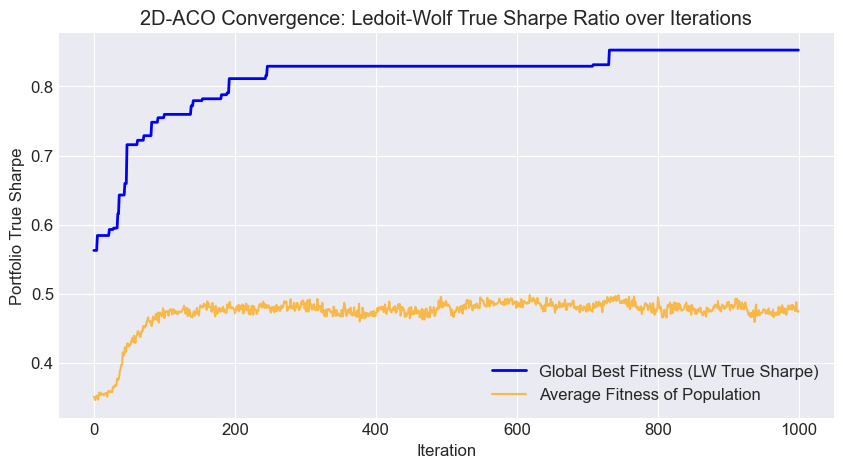

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import math

# =========================================================================
# Step 1: เตรียมข้อมูลจาก Ledoit-Wolf (รันบน GPU)
# =========================================================================
# สมมติว่ามี valid_tickers, returns_gpu, shrunk_cov_gpu, corr_matrix_gpu กำหนดไว้แล้ว
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Executing 2D-ACO on: {device}")

tickers = list(valid_tickers)
num_assets = len(tickers)
target_assets = 30
rf_rate = RISK_FREE_RATE if 'RISK_FREE_RATE' in globals() or 'RISK_FREE_RATE' in locals() else 0.0

# คำนวณค่าสถิติรายตัวจากชุดข้อมูล Ledoit-Wolf บน GPU 
mean_returns_gpu = torch.mean(returns_gpu, dim=0)
vols_gpu = torch.sqrt(torch.diag(shrunk_cov_gpu))

ind_ann_return_gpu = mean_returns_gpu * 252
ind_ann_vol_gpu = vols_gpu * math.sqrt(252)
ind_sharpe_gpu = (ind_ann_return_gpu - rf_rate) / ind_ann_vol_gpu

# ปรับค่า Heuristic (LW Sharpe) ให้เป็นบวกเสมอเพื่อใช้เป็นความน่าจะเป็น
min_sharpe = torch.min(ind_sharpe_gpu)
heuristic_gpu = ind_sharpe_gpu - min_sharpe + 1e-4

# =========================================================================
# Step 2: กำหนดพารามิเตอร์ 2D-ACO
# =========================================================================
num_ants = 500
num_iterations = 1000  # ลดลงจาก 10k เพราะ 2D ACO แบบ Step-by-step มีความซับซ้อนกว่า
alpha = 1.0            # น้ำหนัก 2D Pheromones (เรียนรู้คู่หุ้นที่จัดพอร์ตด้วยกันแล้วดี)
beta = 2.0             # น้ำหนัก Heuristic (LW Sharpe รายตัว)
evaporation_rate = 0.1
Q = 1.0                 # ปริมาณ Pheromone ที่มดปล่อยลงบนเส้นทางที่เลือก (ปรับตามความเหมาะสม)

# สร้าง Pheromones แบบ 2 มิติ (n_assets x n_assets) และแบบ 1 มิติสำหรับก้าวแรก
pheromones_2d = torch.ones((num_assets, num_assets), dtype=torch.float32, device=device)
pheromones_start = torch.ones(num_assets, dtype=torch.float32, device=device)

global_best_portfolio = None
global_best_fitness = -np.inf
convergence_curve = []
avg_fitness_curve = []

# =========================================================================
# Step 3: Run the Vectorized 2D-ACO Algorithm
# =========================================================================
for iteration in range(num_iterations):
    # ป้องกันค่า Pheromone ล้นหรือติดลบ
    pheromones_start = torch.clamp(pheromones_start, min=0.01, max=10.0)
    pheromones_2d = torch.clamp(pheromones_2d, min=0.01, max=10.0)
    
    # ตัวแปรจำลองการเดินของมดแต่ละตัว
    available_mask = torch.ones((num_ants, num_assets), dtype=torch.bool, device=device)
    paths = torch.zeros((num_ants, target_assets), dtype=torch.long, device=device)
    W = torch.zeros((num_ants, num_assets), dtype=torch.float32, device=device)

    # --- มดเดินทีละก้าว (Step-by-step) บน GPU ---
    for step in range(target_assets):
        if step == 0:
            p_matrix = pheromones_start.unsqueeze(0).expand(num_ants, -1)
        else:
            last_picked = paths[:, step - 1]
            p_matrix = pheromones_2d[last_picked, :] 
            
        h_matrix = heuristic_gpu.unsqueeze(0).expand(num_ants, -1)
        
        # คำนวณความน่าจะเป็น
        probs = (p_matrix ** alpha) * (h_matrix ** beta)
        probs = probs * available_mask # บังคับให้ความน่าจะเป็นของหุ้นที่เลือกไปแล้วเป็น 0
        probs = probs + (1e-8 * available_mask) # กันกรณีผลรวมเป็น 0
        probs = probs / probs.sum(dim=1, keepdim=True)
        
        # เลือกหุ้น 1 ตัวจากความน่าจะเป็นที่อัปเดตใหม่
        chosen = torch.multinomial(probs, num_samples=1).squeeze(1)
        
        paths[:, step] = chosen
        W[torch.arange(num_ants, device=device), chosen] = 1.0 / target_assets
        available_mask[torch.arange(num_ants, device=device), chosen] = False

    # --- คำนวณ True Fitness ด้วย Ledoit-Wolf Covariance ---
    # R_p = w^T * R
    port_returns = torch.matmul(W, mean_returns_gpu) * 252
    # Sigma_p = sqrt(w^T * Cov * w)
    port_variances = torch.sum(torch.matmul(W, shrunk_cov_gpu) * W, dim=1) * 252
    port_vols = torch.sqrt(port_variances)
    
    # Fitness คือ True Sharpe Ratio 
    fitnesses = (port_returns - rf_rate) / port_vols
    
    avg_fitness_curve.append(fitnesses.mean().item())
    
    # หาประชากรมดที่ทำคะแนนดีที่สุดในรอบนี้
    iter_best_idx = torch.argmax(fitnesses)
    iter_best_fitness = fitnesses[iter_best_idx].item()
    iter_best_path = paths[iter_best_idx]
    
    if iter_best_fitness > global_best_fitness:
        global_best_fitness = iter_best_fitness
        global_best_portfolio = iter_best_path.cpu().numpy()
        
    convergence_curve.append(global_best_fitness)
    
    # --- อัปเดต 2D Pheromones ด้วยเส้นทางของมดที่ดีที่สุด ---
    pheromones_start *= (1 - evaporation_rate)
    pheromones_2d *= (1 - evaporation_rate)
    
    # หยอด Pheromone ลงในหุ้นตัวแรก และเส้นทางคู่ขนาน (Synergy Edges)
    pheromones_start[iter_best_path[0]] += Q * iter_best_fitness
    for i in range(target_assets - 1):
        u = iter_best_path[i]
        v = iter_best_path[i + 1]
        # อัปเดตแบบ Undirected Edge เพราะลำดับการซื้อในพอร์ตไม่มีผล
        pheromones_2d[u, v] += Q * iter_best_fitness
        pheromones_2d[v, u] += Q * iter_best_fitness

# =========================================================================
# Step 4: จัดเตรียม DataFrame สรุปผล
# =========================================================================
best_tickers = [tickers[i] for i in global_best_portfolio]
print(f"\n🎯 คัดเลือกหุ้นด้วย 2D-ACO + Ledoit-Wolf เสร็จสิ้น ได้ทั้งหมด: {len(best_tickers)} ตัว")

# ดึงข้อมูลกลับมาทำตาราง
ind_ann_return_cpu = ind_ann_return_gpu.cpu().numpy()
ind_ann_vol_cpu = ind_ann_vol_gpu.cpu().numpy()
ind_sharpe_cpu = ind_sharpe_gpu.cpu().numpy()
corr_matrix_cpu = corr_matrix_gpu.cpu().numpy()

results = []
for idx in global_best_portfolio:
    ticker = tickers[idx]
    
    sharpe = ind_sharpe_cpu[idx]
    annual_ret = ind_ann_return_cpu[idx] * 100
    annual_vol = ind_ann_vol_cpu[idx] * 100
    sector = all_sector_map.get(ticker, 'Unknown') if 'all_sector_map' in locals() else 'Unknown'
    
    # คำนวณ Correlation สกัดเฉพาะหุ้นที่เข้าพอร์ต (ใช้ Index เพื่อความแม่นยำ)
    sub_corr = corr_matrix_cpu[idx, global_best_portfolio]
    avg_corr = np.mean(sub_corr)
    
    mask = np.ones(len(sub_corr), dtype=bool)
    mask[np.where(global_best_portfolio == idx)[0][0]] = False
    
    max_corr = np.max(sub_corr[mask]) if len(sub_corr[mask]) > 0 else 1.0
    min_corr = np.min(sub_corr[mask]) if len(sub_corr[mask]) > 0 else 1.0
    
    results.append({
        'Ticker': ticker,
        'Sector': sector,
        'LW Annual Return (%)': round(annual_ret, 2),
        'LW Annual Vol (%)': round(annual_vol, 2),
        'LW Sharpe': round(sharpe, 3),
        'Avg Corr (vs Portfolio)': round(avg_corr, 3),
        'Max Corr': round(max_corr, 3),
        'Min Corr': round(min_corr, 3),
        'Diversification Score': round(sharpe * (1 - avg_corr), 3)
    })

aco_selected_df = pd.DataFrame(results).sort_values('Diversification Score', ascending=False)

# =========================================================================
# Step 5: การคำนวณ Real Portfolio Metrics (Ledoit-Wolf True Sharpe)
# =========================================================================
# ดึง Weight จากโมเดลที่ดีที่สุด
best_weights = torch.zeros(num_assets, dtype=torch.float32, device=device)
best_weights[torch.tensor(global_best_portfolio, device=device)] = 1.0 / target_assets

# คำนวณความเสี่ยงรวมของพอร์ต
real_port_annual_return = torch.dot(best_weights, mean_returns_gpu) * 252
real_port_var = torch.dot(best_weights, torch.matmul(shrunk_cov_gpu, best_weights)) * 252
real_port_annual_vol = torch.sqrt(real_port_var)
real_port_sharpe = (real_port_annual_return - rf_rate) / real_port_annual_vol

val_real_return = real_port_annual_return.item() * 100
val_real_vol = real_port_annual_vol.item() * 100
val_real_sharpe = real_port_sharpe.item()

print("\n" + "=" * 100)
print("🏆 Top หุ้นตัวแทนที่ดีที่สุดจาก 2D-ACO (Maximize Ledoit-Wolf True Sharpe)")
print("   (โมเดลเรียนรู้คู่หุ้นที่จัดเข้าพอร์ตแล้วลดความผันผวนรวมได้ดีที่สุด)")
print("=" * 100)

print(f"Average Correlation (Individual to Port): {aco_selected_df['Avg Corr (vs Portfolio)'].mean():.4f}")
print(f"Average Decorrelation Score:              {aco_selected_df['Diversification Score'].mean():.4f}")
print("-" * 50)
print(f"Real Annual Return of this Portfolio:     {val_real_return:.4f}%")
print(f"Real Annual Volatility of this Portfolio: {val_real_vol:.4f}%")
print(f"Real Sharpe Ratio of this Portfolio:      {val_real_sharpe:.4f}")
print("=" * 100 + "\n")

print("\n📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:")
sector_counts = aco_selected_df.groupby('Sector').size().reset_index(name='จำนวน')
for _, row in sector_counts.iterrows():
    print(f"   • {row['Sector']:20s}: {row['จำนวน']} ตัว")
print(f"   {'─' * 30}")
print(f"   รวมรายชื่อทั้งหมด: {len(aco_selected_df)} ตัว\n")

from IPython.display import display
display(aco_selected_df.set_index('Ticker'))

# =========================================================================
# Step 6: Plot Convergence Curve
# =========================================================================
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, label='Global Best Fitness (LW True Sharpe)', color='b', linewidth=2)
plt.plot(avg_fitness_curve, label='Average Fitness of Population', color='orange', alpha=0.7)
plt.title('2D-ACO Convergence: Ledoit-Wolf True Sharpe Ratio over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Portfolio True Sharpe')
plt.legend()
plt.grid(True)
plt.show()


🚀 เริ่มรัน 2D-ACO บน cuda (Ants: 500, Epochs: 1000)...

🏆 Top หุ้นตัวแทนที่ดีที่สุดจาก 2D-ACO (เรียนรู้ Synergy ข้าม Cluster)
   (รันประมวลผลบน cuda คัดเลือกจาก 30 กลุ่ม)
Average Correlation (Individual to Port): 0.2526
Average Decorrelation Score:              0.3731
--------------------------------------------------
Real Annual Return of this Portfolio:     14.4358%
Real Annual Volatility of this Portfolio: 13.8341%
Real Sharpe Ratio of this Portfolio:      0.7314


📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:
   • Bonds               : 1 ตัว
   • Chinese Stocks      : 1 ตัว
   • Commodities         : 2 ตัว
   • Consumer Discretionary: 1 ตัว
   • Consumer Staples    : 2 ตัว
   • Crypto              : 1 ตัว
   • Energy              : 1 ตัว
   • Financials          : 4 ตัว
   • Health Care         : 3 ตัว
   • Industrials         : 4 ตัว
   • Information Technology: 3 ตัว
   • Real Estate         : 2 ตัว
   • Thai Stocks         : 4 ตัว
   • Utilities           : 1 ตัว
  

,Sector,Annual Return (%),Annual Vol (%),Sharpe,Avg Corr (vs Portfolio),Max Corr,Min Corr,Diversification Score
Ticker,,,,,,,,
NVDA,Information Technology,35.83,40.35,0.888,0.312,0.594,0.036,0.611
COM7.BK,Thai Stocks,20.14,32.47,0.620,0.077,0.212,-0.038,0.572
LLY,Health Care,17.99,24.12,0.746,0.251,0.436,0.027,0.559
BTC-USD,Crypto,37.92,59.36,0.639,0.146,0.193,0.041,0.545
PGR,Financials,15.80,21.57,0.733,0.292,0.484,0.019,0.518
TISCO.BK,Thai Stocks,11.15,19.19,0.581,0.108,0.249,-0.022,0.518
CPRT,Industrials,18.52,24.00,0.772,0.347,0.517,0.024,0.503
COST,Consumer Staples,13.70,20.01,0.685,0.313,0.454,0.015,0.470
AVGO,Information Technology,20.80,30.38,0.685,0.341,0.594,0.042,0.451


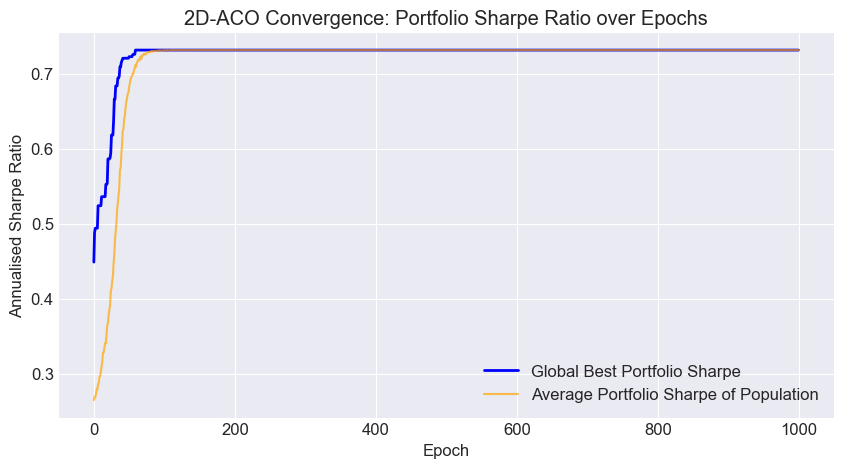

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import math

# ---------------------------------------------------------
# 10. เลือกหุ้น 1 ตัวแทนจากแต่ละ Cluster ด้วย 2D Ant Colony Optimization บน GPU
# (เรียนรู้ความสัมพันธ์/Synergy ข้าม Cluster)
# ---------------------------------------------------------

# สมมติว่ามี valid_tickers, returns_gpu, shrunk_cov_gpu, cluster_labels, num_clusters, all_sector_map ถูกประกาศไว้แล้ว
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# คำนวณ Mean Return และ Volatility รายวันบน GPU
mean_returns_gpu = torch.mean(returns_gpu, dim=0)
vols_gpu = torch.sqrt(torch.diag(shrunk_cov_gpu))

# คำนวณ Annualised Sharpe Ratio ใช้เป็น Heuristic (Local Greedy)
sharpe_ratios_gpu = math.sqrt(252) * (mean_returns_gpu / vols_gpu)

# --- พารามิเตอร์ของระบบ ACO ---
num_ants = 500       # จำนวนมดที่เดินพร้อมกัน 
num_epochs = 1000       # จำนวนรอบในการเรียนรู้
alpha = 1.0           # น้ำหนัก Pheromone (ความสำคัญของ Synergy จากมดรุ่นก่อน)
beta = 2.0            # น้ำหนัก Heuristic (ความน่าสนใจของหุ้นรายตัว)
evaporation = 0.1     # อัตราการระเหยของ Pheromone 
Q = 1.0               # ปริมาณ Pheromone ที่มดเก่งที่สุดจะปล่อยออกมา

# ปรับค่า Heuristic ให้เป็นบวกทั้งหมด
min_sharpe = torch.min(sharpe_ratios_gpu)
heuristic_gpu = sharpe_ratios_gpu - min_sharpe + 1e-4 

# --- สร้าง 2D Pheromones ---
n_features = len(mean_returns_gpu)
pheromones_2d = torch.ones((n_features, n_features), device=device)
pheromones_start = torch.ones(n_features, device=device)

# เตรียมข้อมูล Indices ของแต่ละ Cluster
cluster_indices_list = []
for i in range(1, num_clusters + 1):
    indices = torch.tensor((cluster_labels == i).nonzero()[0], device=device)
    cluster_indices_list.append(indices)

best_global_sharpe = -float('inf')
best_global_portfolio = None

# ตัวแปรสำหรับพลอตกราฟ Convergence
convergence_curve = []
avg_fitness_curve = []

print(f"\n🚀 เริ่มรัน 2D-ACO บน {device} (Ants: {num_ants}, Epochs: {num_epochs})...")

for epoch in range(num_epochs):
    W = torch.zeros((num_ants, n_features), device=device)
    paths = torch.zeros((num_ants, num_clusters), dtype=torch.long, device=device)
    last_picked = None 

    # --- มดเดินเลือกหุ้นทีละ Cluster ---
    for step, cluster_indices in enumerate(cluster_indices_list):
        num_stocks_in_cluster = len(cluster_indices)
        h_cluster = heuristic_gpu[cluster_indices] 
        
        if step == 0:
            p_cluster = pheromones_start[cluster_indices]
            probs = (p_cluster ** alpha) * (h_cluster ** beta)
            probs = probs / torch.sum(probs) 
            
            chosen_local_idx = torch.multinomial(probs, num_samples=num_ants, replacement=True)
            chosen_global_idx = cluster_indices[chosen_local_idx]
            
        else:
            p_matrix = pheromones_2d[last_picked.unsqueeze(1), cluster_indices.unsqueeze(0)]
            h_matrix = h_cluster.unsqueeze(0).expand(num_ants, -1)
            
            probs = (p_matrix ** alpha) * (h_matrix ** beta)
            probs = probs / torch.sum(probs, dim=1, keepdim=True)
            
            chosen_local_idx = torch.multinomial(probs, num_samples=1).squeeze(1)
            chosen_global_idx = cluster_indices[chosen_local_idx]

        W[torch.arange(num_ants, device=device), chosen_global_idx] = 1.0 / num_clusters
        paths[:, step] = chosen_global_idx
        last_picked = chosen_global_idx

    # --- คำนวณ Global Fitness (Portfolio Sharpe Ratio) ---
    port_returns = torch.matmul(W, mean_returns_gpu) * 252
    port_variances = torch.sum(torch.matmul(W, shrunk_cov_gpu) * W, dim=1) * 252
    port_vols = torch.sqrt(port_variances)
    port_sharpes = (port_returns - RISK_FREE_RATE) / port_vols

    # เก็บค่าเฉลี่ย Sharpe Ratio ของมดทั้งหมดในรอบนี้
    avg_fitness_curve.append(port_sharpes.mean().item())
    
    max_sharpe_epoch, best_ant_idx_epoch = torch.max(port_sharpes, dim=0)
    
    if max_sharpe_epoch > best_global_sharpe:
        best_global_sharpe = max_sharpe_epoch.item()
        best_global_portfolio = W[best_ant_idx_epoch].clone()
        
    convergence_curve.append(best_global_sharpe)
        
    # --- อัปเดต 2D Pheromones ---
    pheromones_start = pheromones_start * (1 - evaporation)
    pheromones_2d = pheromones_2d * (1 - evaporation)
    
    best_path_epoch = paths[best_ant_idx_epoch]
    pheromones_start[best_path_epoch[0]] += Q * max_sharpe_epoch
    
    for step in range(num_clusters - 1):
        u = best_path_epoch[step] 
        v = best_path_epoch[step + 1]
        pheromones_2d[u, v] += Q * max_sharpe_epoch

# ---------------------------------------------------------
# สร้างตารางสรุปผลลัพธ์ (สไตล์เดียวกับ HRP)
# ---------------------------------------------------------
best_portfolio_indices = (best_global_portfolio > 0).nonzero(as_tuple=True)[0].cpu().numpy()
selected_stocks_aco = [valid_tickers[idx] for idx in best_portfolio_indices]

# แปลง Shrunk Covariance เป็น Correlation Matrix เพื่อไว้แสดงในตาราง
outer_vols = torch.outer(vols_gpu, vols_gpu)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

results = []
for idx in best_portfolio_indices:
    ticker = valid_tickers[idx]
    
    sharpe = sharpe_ratios_gpu[idx].item()
    annual_ret = mean_returns_gpu[idx].item() * 252 * 100
    annual_vol = vols_gpu[idx].item() * math.sqrt(252) * 100
    sector = all_sector_map.get(ticker, 'Unknown') if 'all_sector_map' in locals() else 'Unknown'
    
    # คำนวณ Correlation เทียบกับหุ้นตัวอื่นๆ ที่ถูกเลือกด้วยกัน
    sub_corr = corr_matrix_gpu[idx, best_portfolio_indices]
    avg_corr = sub_corr.mean().item()
    
    # คำนวณ Max/Min (ยกเว้นตัวเอง)
    mask = torch.ones(len(sub_corr), dtype=torch.bool)
    mask[np.where(best_portfolio_indices == idx)[0][0]] = False
    
    max_corr = sub_corr[mask].max().item() if len(sub_corr[mask]) > 0 else 1.0
    min_corr = sub_corr[mask].min().item() if len(sub_corr[mask]) > 0 else 1.0
    
    # เพิ่มการคำนวณ Diversification Score (Decorrelation)
    diversification_score = sharpe * (1 - avg_corr)
    
    results.append({
        'Ticker': ticker,
        'Sector': sector,
        'Annual Return (%)': round(annual_ret, 2),
        'Annual Vol (%)': round(annual_vol, 2),
        'Sharpe': round(sharpe, 3),
        'Avg Corr (vs Portfolio)': round(avg_corr, 3),
        'Max Corr': round(max_corr, 3),
        'Min Corr': round(min_corr, 3),
        'Diversification Score': round(diversification_score, 3) # เพิ่มคอลัมน์นี้
    })

if results:
    # เปลี่ยนมาจัดเรียงตาม Diversification Score เพื่อให้สอดคล้องกับเวอร์ชันก่อนหน้า
    aco_cluster_selected_df = pd.DataFrame(results).sort_values('Diversification Score', ascending=False)

    # =========================================================================
    # การคำนวณ Real Portfolio Metrics บน PyTorch (GPU) สำหรับ 2D-ACO
    # =========================================================================
    # 1. คำนวณ Portfolio Annual Return (R_p = w^T * R)
    real_port_annual_return = torch.dot(best_global_portfolio, mean_returns_gpu) * 252
    
    # 2. คำนวณ Portfolio Annual Volatility ด้วยสมการ Sigma_p = sqrt(w^T * Cov * w)
    port_var = torch.dot(best_global_portfolio, torch.matmul(shrunk_cov_gpu, best_global_portfolio))
    real_port_annual_vol = torch.sqrt(port_var * 252)
    
    # 3. คำนวณ Real Sharpe Ratio ของพอร์ต
    rf_rate = RISK_FREE_RATE if 'RISK_FREE_RATE' in globals() or 'RISK_FREE_RATE' in locals() else 0.0
    real_port_sharpe = (real_port_annual_return - rf_rate) / real_port_annual_vol
    
    # 4. แปลงข้อมูลจาก Tensor กลับเป็น Float ธรรมดา
    val_real_return = real_port_annual_return.item() * 100
    val_real_vol = real_port_annual_vol.item() * 100
    val_real_sharpe = real_port_sharpe.item()
    # =========================================================================

    print("\n" + "=" * 100)
    print("🏆 Top หุ้นตัวแทนที่ดีที่สุดจาก 2D-ACO (เรียนรู้ Synergy ข้าม Cluster)")
    print("=" * 100)
    
    print(f"Average Correlation (Individual to Port): {aco_cluster_selected_df['Avg Corr (vs Portfolio)'].mean():.4f}")
    print(f"Average Decorrelation Score:              {aco_cluster_selected_df['Diversification Score'].mean():.4f}") # เพิ่มบรรทัดนี้
    print("-" * 50)
    print(f"Real Annual Return of this Portfolio:     {val_real_return:.4f}%")
    print(f"Real Annual Volatility of this Portfolio: {val_real_vol:.4f}%")
    print(f"Real Sharpe Ratio of this Portfolio:      {val_real_sharpe:.4f}")
    print("=" * 100 + "\n")

    print("\n📊 สรุปสัดส่วนหุ้นที่ได้รับคัดเลือกในแต่ละกลุ่มอุตสาหกรรม:")
    sector_counts = aco_cluster_selected_df.groupby('Sector').size().reset_index(name='จำนวน')
    for _, row in sector_counts.iterrows():
        print(f"   • {row['Sector']:20s}: {row['จำนวน']} ตัว")
    print(f"   {'─' * 30}")
    print(f"   รวมรายชื่อทั้งหมด: {len(aco_cluster_selected_df)} ตัว\n")

    # แสดงผล DataFrame
    from IPython.display import display
    display(aco_cluster_selected_df.set_index('Ticker'))

# ---------------------------------------------------------
# พลอตกราฟ Convergence 
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(convergence_curve, label='Global Best Portfolio Sharpe', color='b', linewidth=2)
plt.plot(avg_fitness_curve, label='Average Portfolio Sharpe of Population', color='orange', alpha=0.7)
plt.title('2D-ACO Convergence: Portfolio Sharpe Ratio over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Annualised Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()

In [139]:
start_date

datetime.datetime(2022, 3, 21, 0, 0)


--- Starting Phase 3: Walk-Forward Optimization ---


[*********************100%***********************]  31 of 31 completed


Total trading days: 3286. Starting rolling window process...
Rebalanced for trading period: 2017-01-27 to 2017-03-30
Rebalanced for trading period: 2017-03-31 to 2017-06-01
Rebalanced for trading period: 2017-06-02 to 2017-08-03
Rebalanced for trading period: 2017-08-04 to 2017-10-05
Rebalanced for trading period: 2017-10-06 to 2017-12-07
Rebalanced for trading period: 2017-12-08 to 2018-02-08
Rebalanced for trading period: 2018-02-09 to 2018-04-12
Rebalanced for trading period: 2018-04-13 to 2018-06-14
Rebalanced for trading period: 2018-06-15 to 2018-08-16
Rebalanced for trading period: 2018-08-17 to 2018-10-18
Rebalanced for trading period: 2018-10-19 to 2018-12-20
Rebalanced for trading period: 2018-12-21 to 2019-02-21
Rebalanced for trading period: 2019-02-22 to 2019-04-25
Rebalanced for trading period: 2019-04-26 to 2019-06-27
Rebalanced for trading period: 2019-06-28 to 2019-08-29
Rebalanced for trading period: 2019-08-30 to 2019-10-31
Rebalanced for trading period: 2019-11-01 t

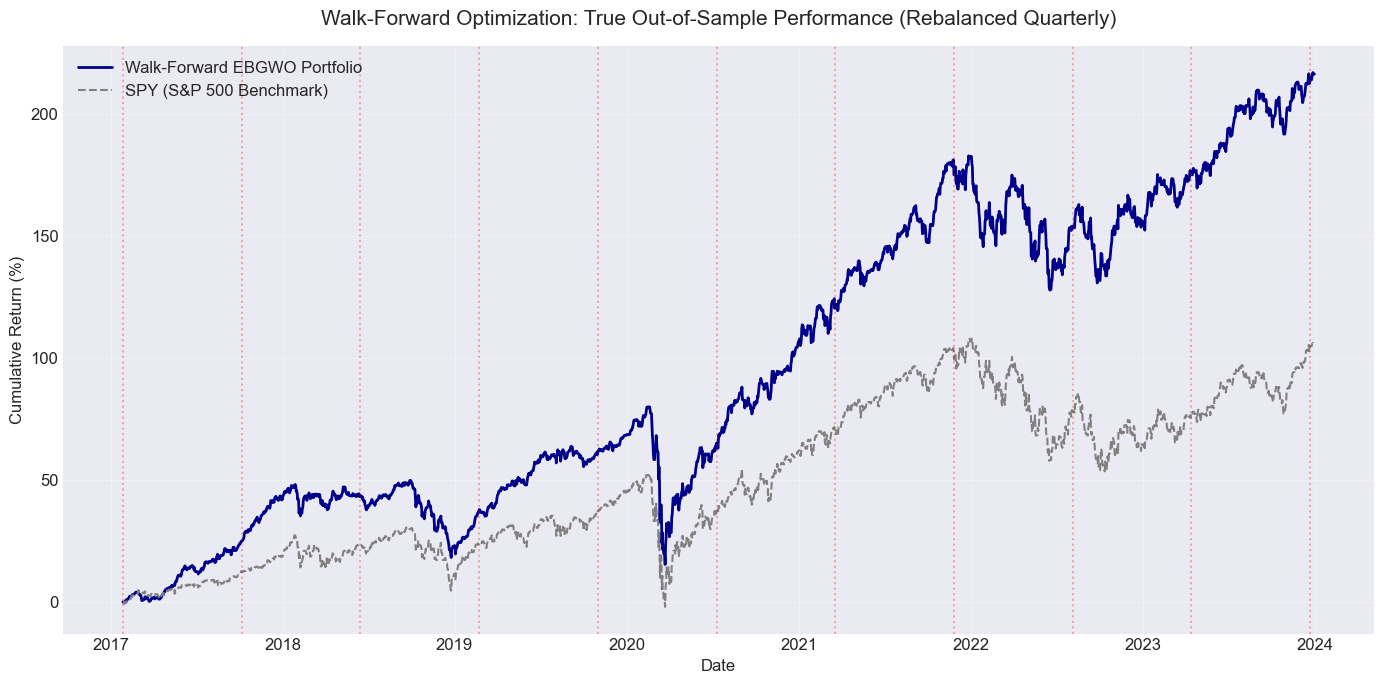


=== Walk-Forward Performance Metrics ===
Annualized Return:      12.40%
Annualized Volatility:  13.54%
Sharpe Ratio:           0.9158

=== Walk-Forward Performance Metrics ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 216.34%               | 105.45%
Annualized Return      | 12.40%               | 8.45%
Annualized Volatility  | 13.54%               | 15.94%
Sharpe Ratio           | 0.9158                | 0.5304
Max Drawdown           | -35.95%               | -35.75%
--------------------------------------------------------------------


In [145]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf

# สมมติว่า valid_tickers และ selected_stocks ถูกกำหนดไว้แล้วจากขั้นตอนก่อนหน้า
# selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]


def ledoit_wolf_covariance_gpu_dynamic(X):
    """ฟังก์ชัน Ledoit-Wolf Dynamic Shrinkage ที่คุณให้มา"""
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # 4. คำนวณ Dynamic Delta (Optimal Shrinkage)
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    X_squared = X_centered ** 2
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # 5. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()


def optimize_weights_ebgwo_monte_carlo_entropy(train_returns_gpu, max_weight=0.1, lambda_ent=0.05, num_wolves=500, iterations=1000):
    """
    EBGWO Optimization + Monte Carlo + Entropy Regularization
    *อัปเดต: ใช้ Ledoit-Wolf Shrinkage Covariance ในการคำนวณ Volatility*
    """
    num_days, num_assets = train_returns_gpu.shape
    device = train_returns_gpu.device
    RISK_FREE_RATE = 0.0434
    
    # log_n ป้องกันการหารด้วยศูนย์ถ้ามีสินทรัพย์เดียว
    log_n = math.log(num_assets) if num_assets > 1 else 1.0
    ST = 0.4
    eps = 1e-10 
    
    # 1. Initialize Wolves (Population)
    wolves = torch.rand((num_wolves, num_assets), dtype=torch.float32, device=device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True)
    
    best_weights_global = None
    best_fitness_global = -float('inf')
    
    for iteration in range(iterations):
        
        # ========================================================
        # MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        mc_indices = torch.randint(0, num_days, (num_days,), device=device)
        mc_returns = train_returns_gpu[mc_indices]
        
        # --- 1. คำนวณ Portfolio Return ---
        # แทนที่จะคำนวณ Return รายวันของทุกตัว เราสามารถหาค่าเฉลี่ยของ mc_returns ได้เลย แล้วคูณน้ำหนักเพื่อความรวดเร็ว
        mc_mean_returns = mc_returns.mean(dim=0) # Shape: (num_assets)
        port_ann_return = torch.matmul(wolves, mc_mean_returns) * 252 # Shape: (num_wolves)
        
        # --- 2. คำนวณ Portfolio Volatility ด้วย Ledoit-Wolf ---
        # สร้าง LW Covariance matrix จากข้อมูล Monte Carlo รอบนี้
        shrunk_cov, _, _ = ledoit_wolf_covariance_gpu_dynamic(mc_returns) # Shape: (num_assets, num_assets)
        
        # คำนวณ Variance ของพอร์ตโฟลิโอสำหรับหมาป่า "ทุกตัว" พร้อมกัน: variance = w^T * Sigma * w
        # ใช้ Broadcasting เพื่อความรวดเร็วบน GPU
        port_variance = torch.sum(wolves * torch.matmul(wolves, shrunk_cov), dim=1) # Shape: (num_wolves)
        
        # แปลงเป็น Annualized Volatility
        port_ann_vol = torch.sqrt(port_variance * 252)
        
        # --- 3. คำนวณ Sharpe Ratio ---
        sharpe_ratios = torch.where(port_ann_vol > 0, 
                                    (port_ann_return - RISK_FREE_RATE) / port_ann_vol, 
                                    torch.zeros_like(port_ann_return))
        
        # --- 4. คำนวณ Normalised Entropy (H(w) / log(n)) ---
        entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
        norm_entropy = entropy / log_n
        
        # --- 5. คำนวณ Penalty (จำกัด max_weight) ---
        weight_penalties = torch.sum(torch.relu(wolves - max_weight), dim=1) * 100.0
        
        # ========================================================
        # TOTAL FITNESS
        # ========================================================
        fitnesses = sharpe_ratios + (lambda_ent * norm_entropy) - weight_penalties
        
        # 6. คัดเลือก Alpha, Beta, Delta (Top 3)
        sorted_indices = torch.argsort(fitnesses, descending=True)
        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        alpha_fitness = fitnesses[sorted_indices[0]].item()
        
        # อัปเดต Global Best
        if alpha_fitness > best_fitness_global:
            best_fitness_global = alpha_fitness
            best_weights_global = alpha_pos.cpu().numpy()
            
        # 7. อัปเดตตำแหน่งหมาป่า (EBGWO Core)
        a = 2.0 - iteration * (2.0 / iterations)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        
        exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
        random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    return best_weights_global



print("\n--- Starting Phase 3: Walk-Forward Optimization ---")

start_date='2015-01-01' 
end_date='2024-01-01'
    
# ดึงข้อมูลทั้งหมดตั้งแต่ต้นจนถึงปัจจุบันเพื่อทำ Walk-Forward (รวมข้อมูลที่ยังไม่เห็นด้วย)
all_tickers = selected_stocks + ['SPY']
print(f"Downloading full dataset for Walk-Forward...")
full_data = yf.download(all_tickers, start=start_date, end=end_date)['Close']
max_gap = 365

# Find columns that have a gap of NaNs larger than max_gap
mask = full_data.isnull().rolling(window=max_gap).sum()
cols_with_long_strips = (mask == max_gap).any()

# Filter them out
data = full_data.loc[:, ~cols_with_long_strips].copy()
full_data = full_data.ffill().bfill()

# คำนวณ Log Returns
full_returns = np.log(full_data / full_data.shift(1)).dropna()
# full_returns =  full_data.pct_change().dropna()
# แยกข้อมูล
port_full_returns = full_returns[selected_stocks]
spy_full_returns = full_returns['SPY']

# ย้ายข้อมูลหุ้นที่เลือกไปบน GPU
returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

# --- ตั้งค่าตัวแปร Walk-Forward ---
LOOKBACK_WINDOW = 252 * 3  # ใช้ข้อมูลย้อนหลัง 3 ปี (756 วัน) ในการ Train
STEP_SIZE = 21*3             # เทรด (Out-of-sample) 3 เดือน (63 วัน) แล้วค่อย Rebalance ใหม่
total_days = returns_gpu_full.shape[0]
all_weights_history = []  # <--- เพิ่มตัวแปรนี้เพื่อแก้ Error
out_of_sample_port_returns = []
out_of_sample_spy_returns = []
rebalance_dates = []

print(f"Total trading days: {total_days}. Starting rolling window process...")

# ลูปเพื่อสไลด์หน้าต่างเวลา
for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
    train_end = start_idx + LOOKBACK_WINDOW
    test_end = min(train_end + STEP_SIZE, total_days)
    
    # ดึงวันที่ (เพื่อเอาไว้พิมพ์ดูเฉยๆ)
    trade_start_date = port_full_returns.index[train_end].strftime('%Y-%m-%d')
    trade_end_date = port_full_returns.index[test_end-1].strftime('%Y-%m-%d')
    
    # 1. ข้อมูล In-Sample (Train)
    train_returns = returns_gpu_full[start_idx:train_end]
    
    # 2. รัน EBGWO เพื่อหาน้ำหนัก (อาจใช้เวลาเล็กน้อยในแต่ละลูป)
    # ใน Loop Walk-Forward
    best_weights = optimize_weights_ebgwo_monte_carlo_entropy(
        train_returns, 
        max_weight=0.05, 
        lambda_ent=0.00,  # ปรับเพิ่มถ้าอยากให้พอร์ตกระจายหุ้นมากขึ้น
        num_wolves=2000, 
        iterations=200
    )
    
    # 3. ข้อมูล Out-of-Sample (Test) - ข้อมูลอนาคตที่โมเดลไม่เคยเห็นตอน Train
    test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
    
    # คำนวณผลตอบแทนพอร์ตโฟลิโอในหน้าต่าง Out-of-Sample
    period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
    period_spy_return = spy_full_returns.iloc[train_end:test_end].values
    
    # เก็บผลลัพธ์
    out_of_sample_port_returns.extend(period_port_return)
    out_of_sample_spy_returns.extend(period_spy_return)
    rebalance_dates.append(trade_start_date)
    all_weights_history.append(best_weights)
    
    print(f"Rebalanced for trading period: {trade_start_date} to {trade_end_date}")

# --- ประมวลผลและแสดงผลกราฟ Equity Curve แท้จริง (True Out-of-Sample) ---
# สร้าง Index วันที่ให้ตรงกับช่วงเวลาเทรดทั้งหมด (ตัด 3 ปีแรกของการ Train ทิ้งไป)
trade_dates = port_full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + len(out_of_sample_port_returns)]

# คำนวณ Cumulative Returns
cum_port_returns = np.cumprod(1 + np.array(out_of_sample_port_returns)) - 1
cum_spy_returns = np.cumprod(1 + np.array(out_of_sample_spy_returns)) - 1

# พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
plt.plot(trade_dates, cum_port_returns * 100, label='Walk-Forward EBGWO Portfolio', color='darkblue', linewidth=2)
plt.plot(trade_dates, cum_spy_returns * 100, label='SPY (S&P 500 Benchmark)', color='gray', linestyle='--', linewidth=1.5)

# เพิ่มเส้นประแนวตั้งเพื่อแสดงจังหวะการ Rebalance (ทุกๆ 1 ปี เพื่อไม่ให้รกเกินไป)
for i, date in enumerate(rebalance_dates):
    if i % 4 == 0: # 4 ไตรมาส = 1 ปี
        plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.3)

plt.title('Walk-Forward Optimization: True Out-of-Sample Performance (Rebalanced Quarterly)', fontsize=15, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- แสดง Metrics รวมของ Walk-Forward ---
wf_ann_return = np.mean(out_of_sample_port_returns) * 252
wf_ann_vol = np.std(out_of_sample_port_returns) * math.sqrt(252)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0

print("\n=== Walk-Forward Performance Metrics ===")
print(f"Annualized Return:      {wf_ann_return:.2%}")
print(f"Annualized Volatility:  {wf_ann_vol:.2%}")
print(f"Sharpe Ratio:           {wf_sharpe:.4f}")
# --- ประมวลผล Metrics สำหรับ Walk-Forward Portfolio และ SPY (Benchmark) ---

# แปลง list เป็น numpy array เพื่อการคำนวณที่ง่ายขึ้น
port_returns_arr = np.array(out_of_sample_port_returns)
spy_returns_arr = np.array(out_of_sample_spy_returns)

# 1. Cumulative Return
wf_cum_return = cum_port_returns[-1]
spy_cum_return = cum_spy_returns[-1]

# 2. Annualized Return
wf_ann_return = np.mean(port_returns_arr) * 252
spy_ann_return = np.mean(spy_returns_arr) * 252

# 3. Annualized Volatility
wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)

# 4. Sharpe Ratio (ใช้ 0 Risk-Free rate เพื่อเปรียบเทียบเชิงสัมพัทธ์ตามปกติ)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0

# 5. Max Drawdown
# สำหรับ Portfolio
rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
wf_max_dd = np.min(drawdown_port)

# สำหรับ SPY
rolling_max_spy = np.maximum.accumulate(1 + cum_spy_returns)
drawdown_spy = (1 + cum_spy_returns) / rolling_max_spy - 1
spy_max_dd = np.min(drawdown_spy)

# --- แสดงผลตารางแบบฟอร์แมต ---
print("\n=== Walk-Forward Performance Metrics ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return:.2%} {'':<13} | {spy_cum_return:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return:.2%} {'':<13} | {spy_ann_return:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol:.2%} {'':<13} | {spy_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe:.4f} {'':<14} | {spy_sharpe:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd:.2%} {'':<13} | {spy_max_dd:.2%}")
print("-" * 68)

In [141]:
portfolio_dfs = {
    "Diversification Selected": diversification_selected,
    "LW Diversification Selected": lw_diversification_selected,
    "LW Sharpe Cluster Selected": lw_sharpe_cluster_selected,
    "LW Div Cluster Selected": lw_diversification_cluster_selected,
    "ACO Selected": aco_selected_df,
    "ACO Cluster Selected": aco_cluster_selected_df
}

--- Extracting Unique Tickers from all Portfolios ---
Total unique assets to download: 61


[*********************100%***********************]  62 of 62 completed



[Diversification Selected] Starting Walk-Forward Optimization...

[LW Diversification Selected] Starting Walk-Forward Optimization...

[LW Sharpe Cluster Selected] Starting Walk-Forward Optimization...

[LW Div Cluster Selected] Starting Walk-Forward Optimization...

[ACO Selected] Starting Walk-Forward Optimization...

[ACO Cluster Selected] Starting Walk-Forward Optimization...

--- Starting Phase 6: Year 2025 Analysis ---


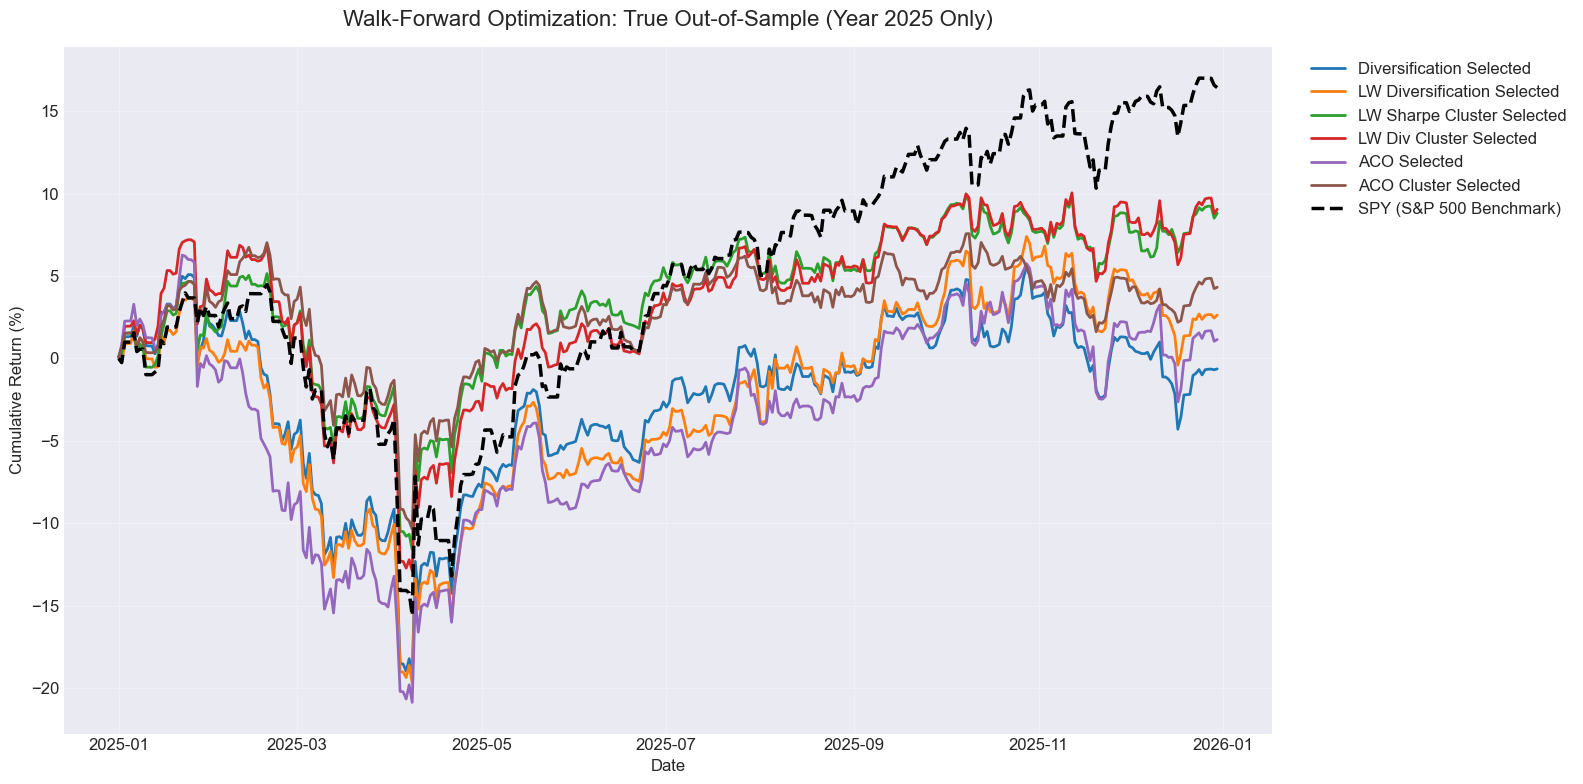


=== Walk-Forward Performance Metrics (Year 2025 Only) ===
Strategy Name                       | Cum Return | Ann Ret  | Ann Vol  | Sharpe  | Max DD  
-------------------------------------------------------------------------------------
Diversification Selected            |    -0.63% |   0.94% |  16.59% | -0.2052 | -23.14%
LW Diversification Selected         |     2.64% |   3.08% |  15.98% | -0.0789 | -22.56%
LW Sharpe Cluster Selected          |     8.82% |   6.79% |  13.72% |  0.1787 | -15.95%
LW Div Cluster Selected             |     9.06% |   7.07% |  14.58% |  0.1871 | -18.75%
ACO Selected                        |     1.15% |   2.28% |  17.24% | -0.1193 | -25.54%
ACO Cluster Selected                |     4.33% |   3.69% |  12.32% | -0.0528 | -16.26%
-------------------------------------------------------------------------------------
SPY (Benchmark)                     |    16.44% |  11.81% |  15.98% |  0.4674 | -19.21%


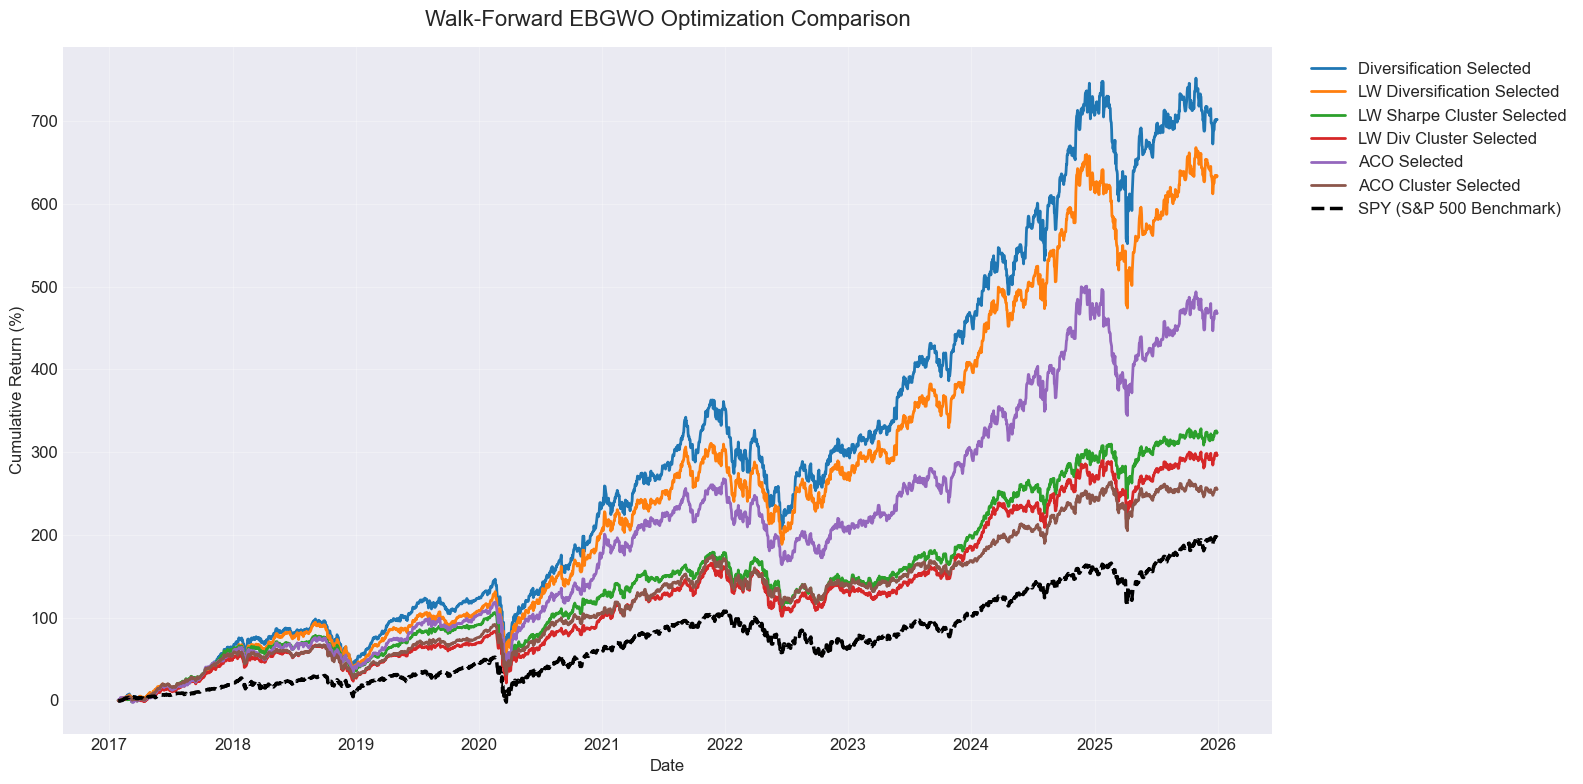


Strategy Name                       | Cum Return | Ann Ret  | Ann Vol  | Sharpe  | Max DD  
--------------------------------------------------------------------------------
Diversification Selected            |   702.09% |  17.53% |  16.87% |  1.0394 | -36.38%
LW Diversification Selected         |   634.09% |  16.85% |  16.89% |  0.9973 | -35.49%
LW Sharpe Cluster Selected          |   324.09% |  12.12% |  13.72% |  0.8829 | -35.07%
LW Div Cluster Selected             |   296.71% |  11.64% |  13.99% |  0.8321 | -34.03%
ACO Selected                        |   468.01% |  14.74% |  16.10% |  0.9154 | -36.28%
ACO Cluster Selected                |   255.09% |  10.58% |  12.51% |  0.8460 | -31.45%
--------------------------------------------------------------------------------
SPY (Benchmark)                     |   196.39% |   9.60% |  15.42% |  0.6222 | -35.75%


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance 

# ---------------------------------------------------------
# 1. ฟังก์ชัน EBGWO (เดิมของคุณ)
# ---------------------------------------------------------
def ledoit_wolf_covariance_gpu_dynamic(X):
    """ฟังก์ชัน Ledoit-Wolf Dynamic Shrinkage ที่คุณให้มา"""
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # 4. คำนวณ Dynamic Delta (Optimal Shrinkage)
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    X_squared = X_centered ** 2
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # 5. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()


def optimize_weights_ebgwo_monte_carlo_entropy(train_returns_gpu, max_weight=0.1, lambda_ent=0.05, num_wolves=500, iterations=1000):
    """
    EBGWO Optimization + Monte Carlo + Entropy Regularization
    *อัปเดต: ใช้ Ledoit-Wolf Shrinkage Covariance ในการคำนวณ Volatility*
    """
    num_days, num_assets = train_returns_gpu.shape
    device = train_returns_gpu.device
    RISK_FREE_RATE = 0.0434
    
    # log_n ป้องกันการหารด้วยศูนย์ถ้ามีสินทรัพย์เดียว
    log_n = math.log(num_assets) if num_assets > 1 else 1.0
    ST = 0.4
    eps = 1e-10 
    
    # 1. Initialize Wolves (Population)
    wolves = torch.rand((num_wolves, num_assets), dtype=torch.float32, device=device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True)
    
    best_weights_global = None
    best_fitness_global = -float('inf')
    
    for iteration in range(iterations):
        
        # ========================================================
        # MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        mc_indices = torch.randint(0, num_days, (num_days,), device=device)
        mc_returns = train_returns_gpu[mc_indices]
        
        # --- 1. คำนวณ Portfolio Return ---
        # แทนที่จะคำนวณ Return รายวันของทุกตัว เราสามารถหาค่าเฉลี่ยของ mc_returns ได้เลย แล้วคูณน้ำหนักเพื่อความรวดเร็ว
        mc_mean_returns = mc_returns.mean(dim=0) # Shape: (num_assets)
        port_ann_return = torch.matmul(wolves, mc_mean_returns) * 252 # Shape: (num_wolves)
        
        # --- 2. คำนวณ Portfolio Volatility ด้วย Ledoit-Wolf ---
        # สร้าง LW Covariance matrix จากข้อมูล Monte Carlo รอบนี้
        shrunk_cov, _, _ = ledoit_wolf_covariance_gpu_dynamic(mc_returns) # Shape: (num_assets, num_assets)
        
        # คำนวณ Variance ของพอร์ตโฟลิโอสำหรับหมาป่า "ทุกตัว" พร้อมกัน: variance = w^T * Sigma * w
        # ใช้ Broadcasting เพื่อความรวดเร็วบน GPU
        port_variance = torch.sum(wolves * torch.matmul(wolves, shrunk_cov), dim=1) # Shape: (num_wolves)
        
        # แปลงเป็น Annualized Volatility
        port_ann_vol = torch.sqrt(port_variance * 252)
        
        # --- 3. คำนวณ Sharpe Ratio ---
        sharpe_ratios = torch.where(port_ann_vol > 0, 
                                    (port_ann_return - RISK_FREE_RATE) / port_ann_vol, 
                                    torch.zeros_like(port_ann_return))
        
        # --- 4. คำนวณ Normalised Entropy (H(w) / log(n)) ---
        entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
        norm_entropy = entropy / log_n
        
        # --- 5. คำนวณ Penalty (จำกัด max_weight) ---
        weight_penalties = torch.sum(torch.relu(wolves - max_weight), dim=1) * 100.0
        
        # ========================================================
        # TOTAL FITNESS
        # ========================================================
        fitnesses = sharpe_ratios + (lambda_ent * norm_entropy) - weight_penalties
        
        # 6. คัดเลือก Alpha, Beta, Delta (Top 3)
        sorted_indices = torch.argsort(fitnesses, descending=True)
        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        alpha_fitness = fitnesses[sorted_indices[0]].item()
        
        # อัปเดต Global Best
        if alpha_fitness > best_fitness_global:
            best_fitness_global = alpha_fitness
            best_weights_global = alpha_pos.cpu().numpy()
            
        # 7. อัปเดตตำแหน่งหมาป่า (EBGWO Core)
        a = 2.0 - iteration * (2.0 / iterations)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        
        exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
        random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    return best_weights_global


# ---------------------------------------------------------
# 2. ดึง Ticker ทั้งหมดแบบไม่ซ้ำ และดาวน์โหลดข้อมูลครั้งเดียว
# ---------------------------------------------------------
print("--- Extracting Unique Tickers from all Portfolios ---")
all_unique_tickers = set()

for name, df in portfolio_dfs.items():
    # ตรวจสอบว่า Ticker อยู่ที่ Index หรือ Column
    tickers = df.index.tolist() if df.index.name == 'Ticker' else df['Ticker'].tolist()
    all_unique_tickers.update(tickers)

all_unique_tickers = list(all_unique_tickers)
print(f"Total unique assets to download: {len(all_unique_tickers)}")

start_date = '2015-01-01' 
end_date = '2025-12-31'
all_download_tickers = all_unique_tickers + ['SPY']

print(f"Downloading full dataset for Walk-Forward...")
ull_data = yf.download(all_tickers, start=start_date, end="2025-12-31")['Close']

# จัดการ Missing Data
max_gap = 365
mask = full_data.isnull().rolling(window=max_gap).sum()
cols_with_long_strips = (mask == max_gap).any()
data = full_data.loc[:, ~cols_with_long_strips].copy()
full_data = data.ffill().bfill()

# Currency Conversion: All Prices to THB
data_filtered = full_data.copy()
print("Downloading USD/THB exchange rate...")
try:
    usdthb_raw = yf.download("USDTHB=X", start=start_date, end=end_date, auto_adjust=True)
    if isinstance(usdthb_raw.columns, pd.MultiIndex):
        usdthb = usdthb_raw['Close'].iloc[:, 0]
    else:
        usdthb = usdthb_raw['Close']
    usdthb = usdthb.reindex(data_filtered.index).ffill().bfill()
    print(f"  USD/THB range: {float(usdthb.min()):.2f} - {float(usdthb.max()):.2f}")
except Exception as e:
    print(f"  Warning: Could not download USD/THB ({e})")
    print("  Using fixed rate: 35.00 THB/USD")
    usdthb = pd.Series(35.0, index=data_filtered.index)

full_data = data_filtered.copy()

thai_cols = [t for t in data_filtered.columns if t.endswith(".BK")]
usd_cols = [t for t in data_filtered.columns if not t.endswith(".BK")]

for ticker in usd_cols:
    data_thb[ticker] = data_filtered[ticker] * usdthb.values.flatten()

print(f"\nConverted {len(usd_cols)} USD assets to THB")
print(f"Thai assets ({len(thai_cols)}): already in THB")

data = data_thb

# คำนวณ Log Returns สำหรับหุ้นทั้งหมด
full_returns = np.log(full_data / full_data.shift(1)).dropna()
spy_full_returns = full_returns['SPY']

# ---------------------------------------------------------
# 3. สร้างฟังก์ชันเพื่อรัน Pipeline สำหรับแต่ละพอร์ต
# ---------------------------------------------------------
def run_walk_forward_for_portfolio(portfolio_name, selected_stocks, full_returns, spy_full_returns):
    print(f"\n[{portfolio_name}] Starting Walk-Forward Optimization...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # กรองเอาเฉพาะ Ticker ที่ถูกเลือกและมีข้อมูลอยู่จริง
    valid_selected_stocks = [t for t in selected_stocks if t in full_returns.columns]
    port_full_returns = full_returns[valid_selected_stocks]
    returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

    LOOKBACK_WINDOW = 252 * 3  
    STEP_SIZE = 21 * 3         
    total_days = returns_gpu_full.shape[0]
    
    out_of_sample_port_returns = []
    
    # ปรับ max_weight แบบไดนามิก เพื่อป้องกัน error กรณีที่หุ้นในพอร์ตน้อยเกินไป
    dynamic_max_weight = max(0.05, (1.0 / len(valid_selected_stocks)) + 0.05)

    for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
        train_end = start_idx + LOOKBACK_WINDOW
        test_end = min(train_end + STEP_SIZE, total_days)
        
        train_returns = returns_gpu_full[start_idx:train_end]
        
        best_weights = optimize_weights_ebgwo_monte_carlo_entropy(
            train_returns, 
            max_weight=dynamic_max_weight, 
            lambda_ent=0.00,  
            num_wolves=500, # ปรับลงเล็กน้อยเพื่อให้รันหลายพอร์ตได้เร็วขึ้น (เพิ่มได้ถ้าต้องการ)
            iterations=1000
        )
        
        test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
        period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
        out_of_sample_port_returns.extend(period_port_return)
        
    # คำนวณ Metrics
    port_returns_arr = np.array(out_of_sample_port_returns)
    cum_port_returns = np.cumprod(1 + port_returns_arr) - 1
    
    wf_cum_return = cum_port_returns[-1]
    wf_ann_return = np.mean(port_returns_arr) * 252
    wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
    wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
    
    rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
    drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
    wf_max_dd = np.min(drawdown_port)
    
    return {
        "Strategy": portfolio_name,
        "Cum Return": wf_cum_return,
        "Ann Return": wf_ann_return,
        "Ann Volatility": wf_ann_vol,
        "Sharpe Ratio": wf_sharpe,
        "Max Drawdown": wf_max_dd,
        "OOS_Returns_Array": port_returns_arr, # ส่งกลับไปพล็อต
        "OOS_Cum_Returns_Array": cum_port_returns
    }

# ---------------------------------------------------------
# 4. วนลูปผ่านทุก DataFrame ใน portfolio_dfs
# ---------------------------------------------------------
all_strategy_results = []
spy_oos_returns = None
trade_dates = None

for name, df in portfolio_dfs.items():
    selected_stocks = df.index.tolist() if df.index.name == 'Ticker' else df['Ticker'].tolist()
    
    res = run_walk_forward_for_portfolio(name, selected_stocks, full_returns, spy_full_returns)
    all_strategy_results.append(res)
    
    # เก็บ Benchmark Date และ SPY Returns เพียงครั้งเดียวจากลูปแรก
    if spy_oos_returns is None:
        LOOKBACK_WINDOW = 252 * 3
        test_len = len(res["OOS_Returns_Array"])
        trade_dates = full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + test_len]
        
        # คราฟต์ SPY Out of sample ตามช่วงเวลาเดียวกัน
        spy_returns_arr = spy_full_returns.iloc[LOOKBACK_WINDOW : LOOKBACK_WINDOW + test_len].values
        spy_returns_daily_arr = spy_returns_arr # <--- เพิ่มบรรทัดนี้เพื่อเก็บรายวันไว้ใช้ใน Step 6
        spy_cum_returns = np.cumprod(1 + spy_returns_arr) - 1
        
        spy_ann_return = np.mean(spy_returns_arr) * 252
        spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)
        spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0
        
        rolling_max_spy = np.maximum.accumulate(1 + spy_cum_returns)
        spy_max_dd = np.min((1 + spy_cum_returns) / rolling_max_spy - 1)
        
        spy_oos_returns = spy_cum_returns

# ---------------------------------------------------------
# 5. แสดงผลลัพธ์ (ตาราง & กราฟ)
# ---------------------------------------------------------
# =========================================================
# 6. วิเคราะห์ผลตอบแทนเฉพาะปี 2025 (Year 2025 Only)
# =========================================================
print("\n" + "="*80)
print("--- Starting Phase 6: Year 2025 Analysis ---")

# สร้างเงื่อนไขเพื่อกรองเฉพาะวันที่อยู่ในปี 2025
mask_2025 = trade_dates.year == 2025

if not mask_2025.any():
    print("⚠️ ไม่มีข้อมูลสำหรับปี 2025 ในชุดทดสอบ (Out-of-Sample)")
else:
    dates_2025 = trade_dates[mask_2025]
    
    # ---------------------------------------------------------
    # คำนวณ SPY (Benchmark) เฉพาะปี 2025
    # ---------------------------------------------------------
    spy_returns_2025 = spy_returns_daily_arr[mask_2025]
    cum_spy_2025 = np.cumprod(1 + spy_returns_2025) - 1
    
    spy_cum_ret_25 = cum_spy_2025[-1] if len(cum_spy_2025) > 0 else 0
    spy_ann_ret_25 = np.mean(spy_returns_2025) * 252
    spy_ann_vol_25 = np.std(spy_returns_2025) * math.sqrt(252)
    spy_sharpe_25 = (spy_ann_ret_25 - 0.0434) / spy_ann_vol_25 if spy_ann_vol_25 > 0 else 0
    
    rolling_max_spy_25 = np.maximum.accumulate(1 + cum_spy_2025)
    spy_max_dd_25 = np.min((1 + cum_spy_2025) / rolling_max_spy_25 - 1) if len(cum_spy_2025) > 0 else 0
    
    results_2025 = []
    
    # ---------------------------------------------------------
    # คำนวณแต่ละ Portfolio และพล็อตกราฟเฉพาะปี 2025
    # ---------------------------------------------------------
    plt.figure(figsize=(16, 8))
    
    for res in all_strategy_results:
        # ดึง Daily Return เฉพาะปี 2025 จากที่เก็บไว้ใน Step 3-4
        port_returns_2025 = res["OOS_Returns_Array"][mask_2025]
        
        # 1. คำนวณ Cumulative Return (เริ่มนับ 0 ใหม่ใน 2025)
        cum_port_2025 = np.cumprod(1 + port_returns_2025) - 1
        
        wf_cum_ret_25 = cum_port_2025[-1] if len(cum_port_2025) > 0 else 0
        wf_ann_ret_25 = np.mean(port_returns_2025) * 252
        wf_ann_vol_25 = np.std(port_returns_2025) * math.sqrt(252)
        wf_sharpe_25 = (wf_ann_ret_25 - 0.0434) / wf_ann_vol_25 if wf_ann_vol_25 > 0 else 0
        
        rolling_max_port_25 = np.maximum.accumulate(1 + cum_port_2025)
        wf_max_dd_25 = np.min((1 + cum_port_2025) / rolling_max_port_25 - 1) if len(cum_port_2025) > 0 else 0
        
        # เก็บผลลัพธ์ลง List
        results_2025.append({
            "Strategy": res["Strategy"],
            "Cum Return": wf_cum_ret_25,
            "Ann Return": wf_ann_ret_25,
            "Ann Vol": wf_ann_vol_25,
            "Sharpe": wf_sharpe_25,
            "Max DD": wf_max_dd_25
        })
        
        # พล็อตกราฟสำหรับพอร์ตนี้
        plt.plot(dates_2025, cum_port_2025 * 100, label=res["Strategy"], linewidth=2)
        
    # พล็อต SPY
    plt.plot(dates_2025, cum_spy_2025 * 100, label='SPY (S&P 500 Benchmark)', color='black', linestyle='--', linewidth=2.5)
    
    # วาดเส้นประแสดงวัน Rebalance (เฉพาะปี 2025)
    # สมมติว่าดึงวันที่ Rebalance แรกสุดของพอร์ตแรกมาใช้เพื่อไม่ให้รกเกินไป
    # *ถ้าไม่ได้เก็บ rebalance_dates ไว้ใน Loop ก่อนหน้า สามารถข้ามการวาดเส้นประได้*
    
    plt.title('Walk-Forward Optimization: True Out-of-Sample (Year 2025 Only)', fontsize=16, pad=15)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (%)')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # แสดงตารางเปรียบเทียบปี 2025
    # ---------------------------------------------------------
    print("\n=== Walk-Forward Performance Metrics (Year 2025 Only) ===")
    print(f"{'Strategy Name':<35} | {'Cum Return':<10} | {'Ann Ret':<8} | {'Ann Vol':<8} | {'Sharpe':<7} | {'Max DD':<8}")
    print("-" * 85)

    for r25 in results_2025:
        print(f"{r25['Strategy']:<35} | {r25['Cum Return']:>9.2%} | {r25['Ann Return']:>7.2%} | {r25['Ann Vol']:>7.2%} | {r25['Sharpe']:>7.4f} | {r25['Max DD']:>7.2%}")

    print("-" * 85)
    print(f"{'SPY (Benchmark)':<35} | {spy_cum_ret_25:>9.2%} | {spy_ann_ret_25:>7.2%} | {spy_ann_vol_25:>7.2%} | {spy_sharpe_25:>7.4f} | {spy_max_dd_25:>7.2%}")
    print("=" * 85)

# กราฟรวมทุกพอร์ต
plt.figure(figsize=(16, 8))
for res in all_strategy_results:
    plt.plot(trade_dates, res["OOS_Cum_Returns_Array"] * 100, label=res["Strategy"], linewidth=2)

plt.plot(trade_dates, spy_oos_returns * 100, label='SPY (S&P 500 Benchmark)', color='black', linestyle='--', linewidth=2.5)

plt.title('Walk-Forward EBGWO Optimization Comparison', fontsize=16, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1)) # นำ Legend ไว้ด้านขวาไม่บังเส้น
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ตารางเปรียบเทียบ
print("\n" + "="*80)
print(f"{'Strategy Name':<35} | {'Cum Return':<10} | {'Ann Ret':<8} | {'Ann Vol':<8} | {'Sharpe':<7} | {'Max DD':<8}")
print("-" * 80)

for res in all_strategy_results:
    print(f"{res['Strategy']:<35} | {res['Cum Return']:>9.2%} | {res['Ann Return']:>7.2%} | {res['Ann Volatility']:>7.2%} | {res['Sharpe Ratio']:>7.4f} | {res['Max Drawdown']:>7.2%}")

# พิมพ์ SPY ท้ายตาราง
print("-" * 80)
print(f"{'SPY (Benchmark)':<35} | {spy_cum_returns[-1]:>9.2%} | {spy_ann_return:>7.2%} | {spy_ann_vol:>7.2%} | {spy_sharpe:>7.4f} | {spy_max_dd:>7.2%}")
print("=" * 80)


--- Extracting Unique Tickers from all Portfolios ---
Total unique assets to download: 61


[*********************100%***********************]  31 of 31 completed


[*********************100%***********************]  1 of 1 completed


  USD/THB range: 29.68 - 38.30

Converted 53 USD assets to THB
Thai assets (9): already in THB

[Diversification Selected] Starting Walk-Forward Optimization...

[LW Diversification Selected] Starting Walk-Forward Optimization...

[LW Sharpe Cluster Selected] Starting Walk-Forward Optimization...

[LW Div Cluster Selected] Starting Walk-Forward Optimization...

[ACO Selected] Starting Walk-Forward Optimization...

[ACO Cluster Selected] Starting Walk-Forward Optimization...

--- Generating Convergence Graph ---


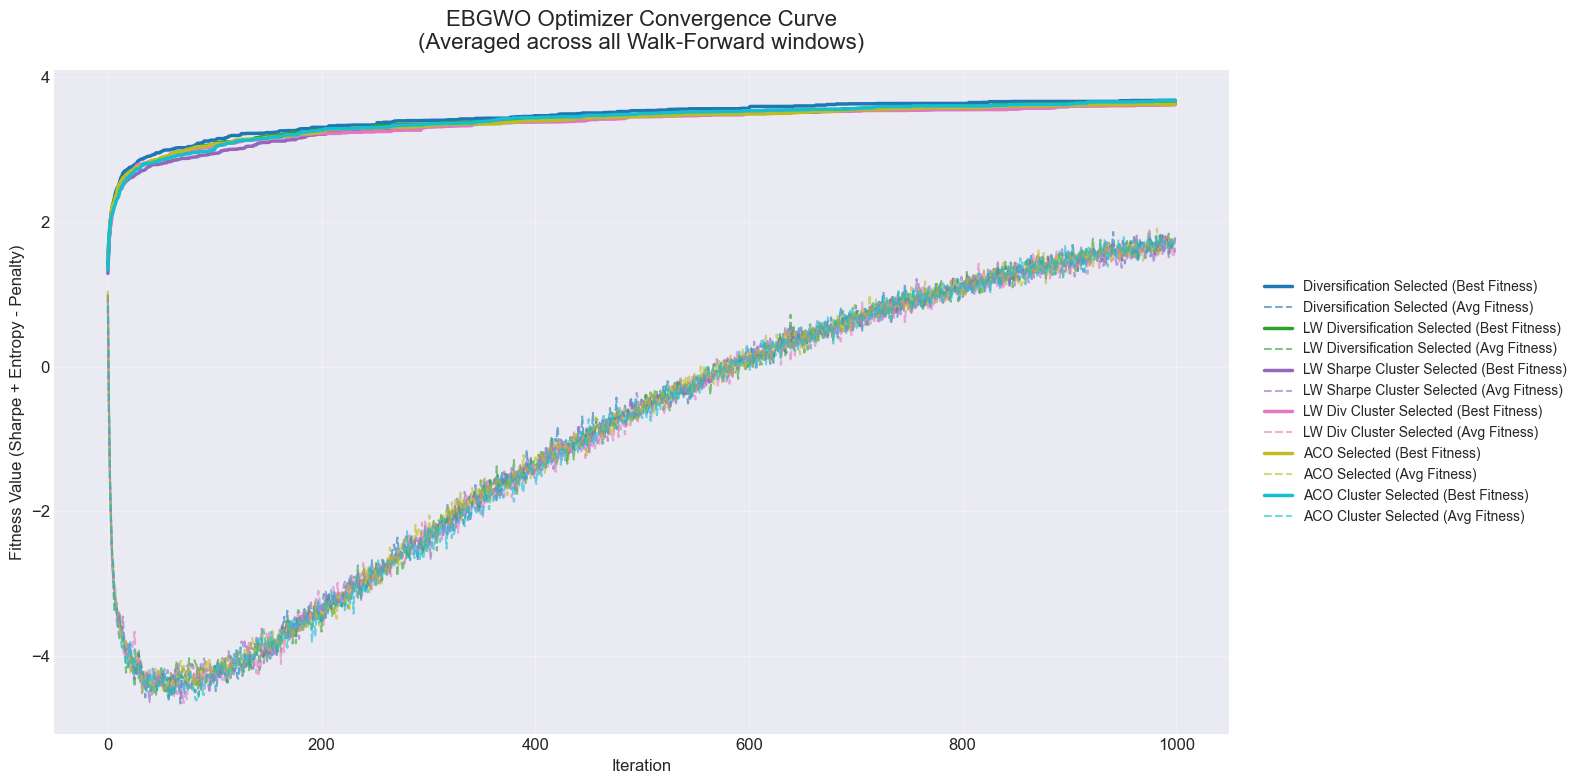


--- Starting Phase 6: Year 2025 Analysis ---


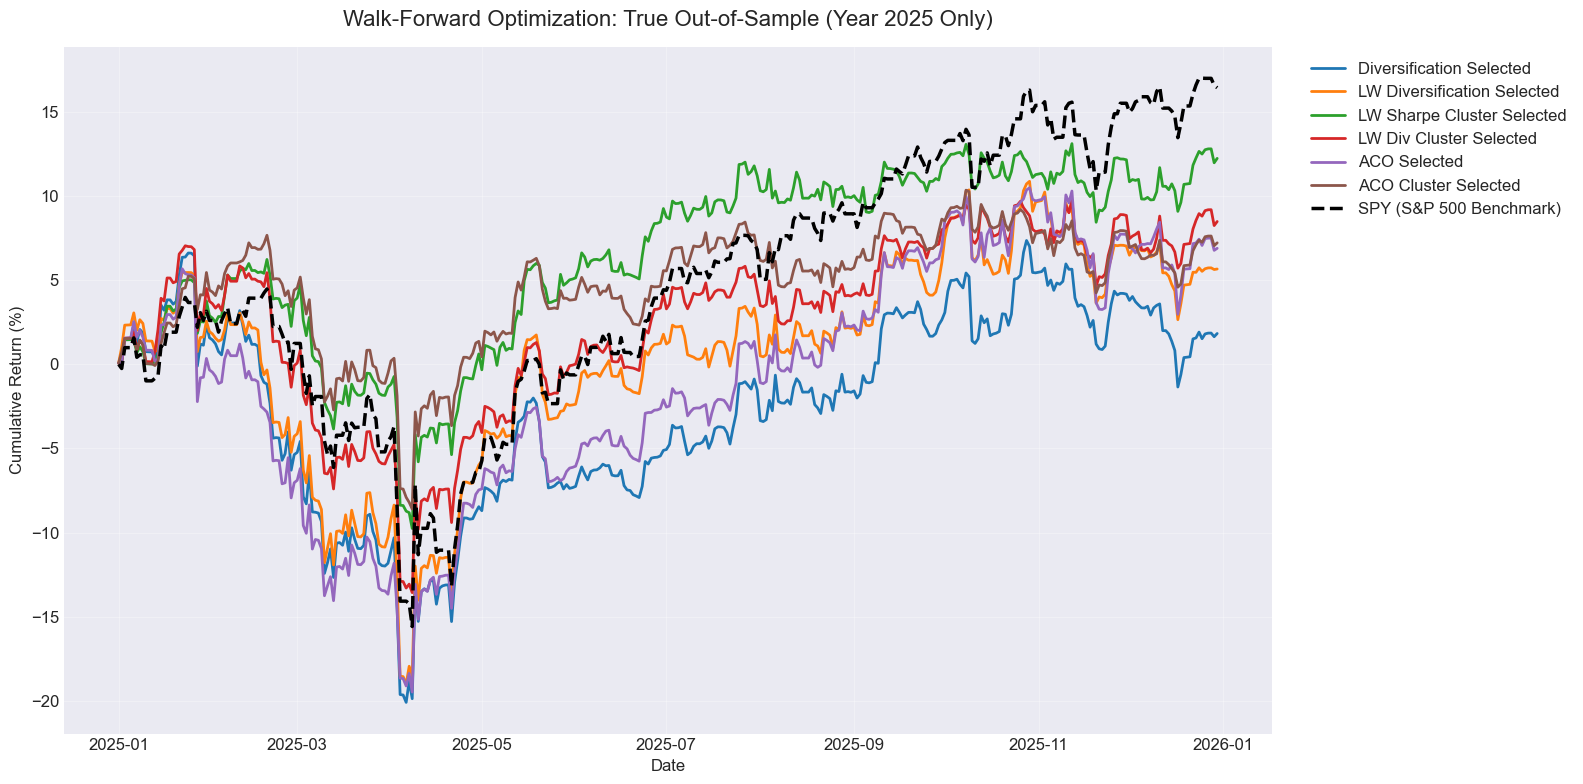


=== Walk-Forward Performance Metrics (Year 2025 Only) ===
Strategy Name                       | Cum Return | Ann Ret  | Ann Vol  | Sharpe  | Max DD  
-------------------------------------------------------------------------------------
Diversification Selected            |     1.83% |   2.77% |  17.37% | -0.0904 | -25.06%
LW Diversification Selected         |     5.67% |   5.30% |  17.18% |  0.0557 | -23.21%
LW Sharpe Cluster Selected          |    12.25% |   8.81% |  12.70% |  0.3516 | -15.06%
LW Div Cluster Selected             |     8.49% |   6.68% |  14.36% |  0.1627 | -19.27%
ACO Selected                        |     6.90% |   6.12% |  17.29% |  0.1028 | -23.81%
ACO Cluster Selected                |     7.22% |   5.59% |  12.32% |  0.1013 | -15.12%
-------------------------------------------------------------------------------------
SPY (Benchmark)                     |    16.44% |  11.81% |  15.98% |  0.4674 | -19.21%


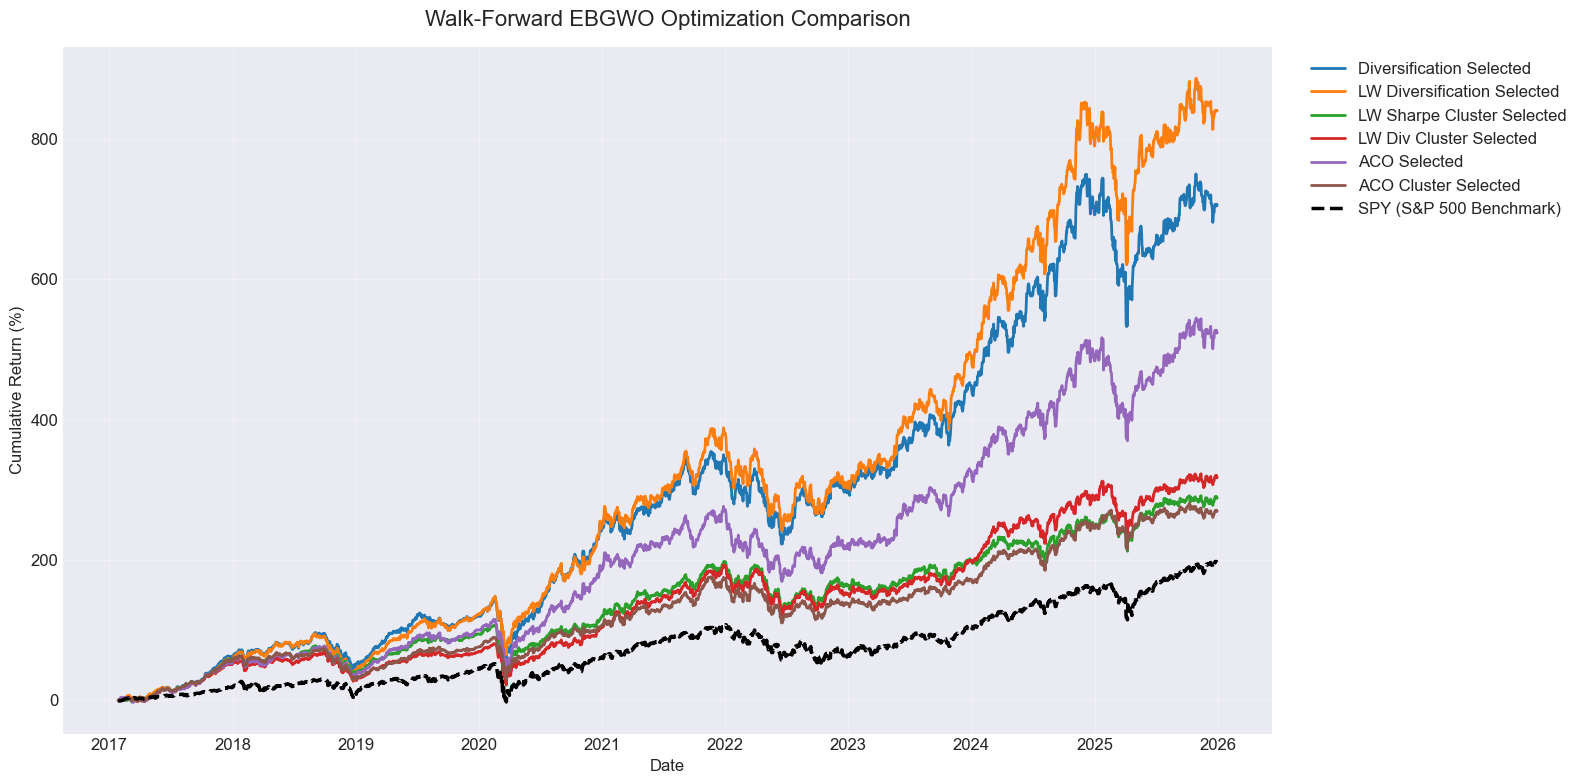


Strategy Name                       | Cum Return | Ann Ret  | Ann Vol  | Sharpe  | Max DD  
--------------------------------------------------------------------------------
Diversification Selected            |   706.05% |  17.61% |  17.12% |  1.0286 | -37.69%
LW Diversification Selected         |   839.96% |  18.78% |  17.03% |  1.1029 | -33.65%
LW Sharpe Cluster Selected          |   288.65% |  11.43% |  13.65% |  0.8374 | -35.31%
LW Div Cluster Selected             |   317.91% |  12.00% |  13.70% |  0.8761 | -32.65%
ACO Selected                        |   523.77% |  15.47% |  16.20% |  0.9550 | -34.99%
ACO Cluster Selected                |   269.59% |  10.97% |  13.08% |  0.8385 | -31.57%
--------------------------------------------------------------------------------
SPY (Benchmark)                     |   196.39% |   9.60% |  15.42% |  0.6222 | -35.75%


In [148]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance 

# ---------------------------------------------------------
# 1. ฟังก์ชัน EBGWO (เดิมของคุณ)
# ---------------------------------------------------------
def ledoit_wolf_covariance_gpu_dynamic(X):
    """ฟังก์ชัน Ledoit-Wolf Dynamic Shrinkage ที่คุณให้มา"""
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # 4. คำนวณ Dynamic Delta (Optimal Shrinkage)
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    X_squared = X_centered ** 2
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # 5. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()


def optimize_weights_ebgwo_monte_carlo_entropy(train_returns_gpu, max_weight=0.1, lambda_ent=0.05, num_wolves=500, iterations=1000):
    """
    EBGWO Optimization + Monte Carlo + Entropy Regularization
    *อัปเดต: ใช้ Ledoit-Wolf Shrinkage Covariance ในการคำนวณ Volatility*
    """
    num_days, num_assets = train_returns_gpu.shape
    device = train_returns_gpu.device
    RISK_FREE_RATE = 0.0434
    
    # log_n ป้องกันการหารด้วยศูนย์ถ้ามีสินทรัพย์เดียว
    log_n = math.log(num_assets) if num_assets > 1 else 1.0
    ST = 0.4
    eps = 1e-10 
    
    # 1. Initialize Wolves (Population)
    wolves = torch.rand((num_wolves, num_assets), dtype=torch.float32, device=device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True)
    
    best_weights_global = None
    best_fitness_global = -float('inf')
    convergence_best = []
    convergence_avg = []

    for iteration in range(iterations):
        
        # ========================================================
        # MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        mc_indices = torch.randint(0, num_days, (num_days,), device=device)
        mc_returns = train_returns_gpu[mc_indices]
        
        # --- 1. คำนวณ Portfolio Return ---
        # แทนที่จะคำนวณ Return รายวันของทุกตัว เราสามารถหาค่าเฉลี่ยของ mc_returns ได้เลย แล้วคูณน้ำหนักเพื่อความรวดเร็ว
        mc_mean_returns = mc_returns.mean(dim=0) # Shape: (num_assets)
        port_ann_return = torch.matmul(wolves, mc_mean_returns) * 252 # Shape: (num_wolves)
        
        # --- 2. คำนวณ Portfolio Volatility ด้วย Ledoit-Wolf ---
        # สร้าง LW Covariance matrix จากข้อมูล Monte Carlo รอบนี้
        shrunk_cov, _, _ = ledoit_wolf_covariance_gpu_dynamic(mc_returns) # Shape: (num_assets, num_assets)
        
        # คำนวณ Variance ของพอร์ตโฟลิโอสำหรับหมาป่า "ทุกตัว" พร้อมกัน: variance = w^T * Sigma * w
        # ใช้ Broadcasting เพื่อความรวดเร็วบน GPU
        port_variance = torch.sum(wolves * torch.matmul(wolves, shrunk_cov), dim=1) # Shape: (num_wolves)
        
        # แปลงเป็น Annualized Volatility
        port_ann_vol = torch.sqrt(port_variance * 252)
        
        # --- 3. คำนวณ Sharpe Ratio ---
        sharpe_ratios = torch.where(port_ann_vol > 0, 
                                    (port_ann_return - RISK_FREE_RATE) / port_ann_vol, 
                                    torch.zeros_like(port_ann_return))
        
        # --- 4. คำนวณ Normalised Entropy (H(w) / log(n)) ---
        entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
        norm_entropy = entropy / log_n
        
        # --- 5. คำนวณ Penalty (จำกัด max_weight) ---
        weight_penalties = torch.sum(torch.relu(wolves - max_weight), dim=1) * 100.0
        
        # ========================================================
        # TOTAL FITNESS
        # ========================================================
        fitnesses = sharpe_ratios + (lambda_ent * norm_entropy) - weight_penalties
        
        # 6. คัดเลือก Alpha, Beta, Delta (Top 3)
        sorted_indices = torch.argsort(fitnesses, descending=True)
        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        
        alpha_fitness = fitnesses[sorted_indices[0]].item()
        
        # [ส่วนที่เพิ่มใหม่] คำนวณ Average Fitness ของประชากรหมาป่าในรอบนี้ (ใช้ PyTorch คำนวณบน GPU)
        avg_fitness = fitnesses.mean().item()
        
        # อัปเดต Global Best
        if alpha_fitness > best_fitness_global:
            best_fitness_global = alpha_fitness
            best_weights_global = alpha_pos.cpu().numpy()
   
        convergence_best.append(best_fitness_global)
        convergence_avg.append(avg_fitness)

            
        # 7. อัปเดตตำแหน่งหมาป่า (EBGWO Core)
        a = 2.0 - iteration * (2.0 / iterations)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        
        exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
        random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    return best_weights_global, convergence_best, convergence_avg


# ---------------------------------------------------------
# 2. ดึง Ticker ทั้งหมดแบบไม่ซ้ำ และดาวน์โหลดข้อมูลครั้งเดียว
# ---------------------------------------------------------
print("--- Extracting Unique Tickers from all Portfolios ---")
all_unique_tickers = set()

for name, df in portfolio_dfs.items():
    # ตรวจสอบว่า Ticker อยู่ที่ Index หรือ Column
    tickers = df.index.tolist() if df.index.name == 'Ticker' else df['Ticker'].tolist()
    all_unique_tickers.update(tickers)

all_unique_tickers = list(all_unique_tickers)
print(f"Total unique assets to download: {len(all_unique_tickers)}")

start_date = '2015-01-01' 
end_date = '2025-12-31'
all_download_tickers = all_unique_tickers + ['SPY']

print(f"Downloading full dataset for Walk-Forward...")
ull_data = yf.download(all_tickers, start=start_date, end="2025-12-31")['Close']

# จัดการ Missing Data
max_gap = 365
mask = full_data.isnull().rolling(window=max_gap).sum()
cols_with_long_strips = (mask == max_gap).any()
data = full_data.loc[:, ~cols_with_long_strips].copy()
full_data = data.ffill().bfill()

# Currency Conversion: All Prices to THB
data_filtered = full_data.copy()
print("Downloading USD/THB exchange rate...")
try:
    usdthb_raw = yf.download("USDTHB=X", start=start_date, end=end_date, auto_adjust=True)
    if isinstance(usdthb_raw.columns, pd.MultiIndex):
        usdthb = usdthb_raw['Close'].iloc[:, 0]
    else:
        usdthb = usdthb_raw['Close']
    usdthb = usdthb.reindex(data_filtered.index).ffill().bfill()
    print(f"  USD/THB range: {float(usdthb.min()):.2f} - {float(usdthb.max()):.2f}")
except Exception as e:
    print(f"  Warning: Could not download USD/THB ({e})")
    print("  Using fixed rate: 35.00 THB/USD")
    usdthb = pd.Series(35.0, index=data_filtered.index)

full_data = data_filtered.copy()

thai_cols = [t for t in data_filtered.columns if t.endswith(".BK")]
usd_cols = [t for t in data_filtered.columns if not t.endswith(".BK")]

for ticker in usd_cols:
    data_thb[ticker] = data_filtered[ticker] * usdthb.values.flatten()

print(f"\nConverted {len(usd_cols)} USD assets to THB")
print(f"Thai assets ({len(thai_cols)}): already in THB")

data = data_thb

# คำนวณ Log Returns สำหรับหุ้นทั้งหมด
full_returns = np.log(full_data / full_data.shift(1)).dropna()
spy_full_returns = full_returns['SPY']

# ---------------------------------------------------------
# 3. สร้างฟังก์ชันเพื่อรัน Pipeline สำหรับแต่ละพอร์ต
# ---------------------------------------------------------
def run_walk_forward_for_portfolio(portfolio_name, selected_stocks, full_returns, spy_full_returns):
    print(f"\n[{portfolio_name}] Starting Walk-Forward Optimization...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # กรองเอาเฉพาะ Ticker ที่ถูกเลือกและมีข้อมูลอยู่จริง
    valid_selected_stocks = [t for t in selected_stocks if t in full_returns.columns]
    port_full_returns = full_returns[valid_selected_stocks]
    returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

    LOOKBACK_WINDOW = 252 * 3  
    STEP_SIZE = 21 * 3         
    total_days = returns_gpu_full.shape[0]
    
    out_of_sample_port_returns = []
    all_best_conv = []
    all_avg_conv = []
    # ปรับ max_weight แบบไดนามิก เพื่อป้องกัน error กรณีที่หุ้นในพอร์ตน้อยเกินไป
    dynamic_max_weight = max(0.05, (1.0 / len(valid_selected_stocks)) + 0.05)

    for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
        train_end = start_idx + LOOKBACK_WINDOW
        test_end = min(train_end + STEP_SIZE, total_days)
        
        train_returns = returns_gpu_full[start_idx:train_end]
        
        best_weights, conv_b, conv_a = optimize_weights_ebgwo_monte_carlo_entropy(
            train_returns, 
            max_weight=dynamic_max_weight, 
            lambda_ent=0.00,  
            num_wolves=500, 
            iterations=1000
        )
        
        # [ส่วนที่เพิ่มใหม่] บันทึก Convergence ของรอบนี้
        all_best_conv.append(conv_b)
        all_avg_conv.append(conv_a)

        test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
        period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
        out_of_sample_port_returns.extend(period_port_return)
        
    # คำนวณ Metrics
    port_returns_arr = np.array(out_of_sample_port_returns)
    cum_port_returns = np.cumprod(1 + port_returns_arr) - 1
    
    wf_cum_return = cum_port_returns[-1]
    wf_ann_return = np.mean(port_returns_arr) * 252
    wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
    wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
    
    rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
    drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
    wf_max_dd = np.min(drawdown_port)
    
    avg_best_conv_overall = np.mean(all_best_conv, axis=0)
    avg_avg_conv_overall = np.mean(all_avg_conv, axis=0)
    
    return {
        "Strategy": portfolio_name,
        "Cum Return": wf_cum_return,
        "Ann Return": wf_ann_return,
        "Ann Volatility": wf_ann_vol,
        "Sharpe Ratio": wf_sharpe,
        "Max Drawdown": wf_max_dd,
        "OOS_Returns_Array": port_returns_arr,
        "OOS_Cum_Returns_Array": cum_port_returns,
        "Avg_Best_Convergence": avg_best_conv_overall,
        "Avg_Avg_Convergence": avg_avg_conv_overall
    }
# ---------------------------------------------------------
# 4. วนลูปผ่านทุก DataFrame ใน portfolio_dfs
# ---------------------------------------------------------
all_strategy_results = []
spy_oos_returns = None
trade_dates = None

for name, df in portfolio_dfs.items():
    selected_stocks = df.index.tolist() if df.index.name == 'Ticker' else df['Ticker'].tolist()
    
    res = run_walk_forward_for_portfolio(name, selected_stocks, full_returns, spy_full_returns)
    all_strategy_results.append(res)
    
    # เก็บ Benchmark Date และ SPY Returns เพียงครั้งเดียวจากลูปแรก
    if spy_oos_returns is None:
        LOOKBACK_WINDOW = 252 * 3
        test_len = len(res["OOS_Returns_Array"])
        trade_dates = full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + test_len]
        
        # คราฟต์ SPY Out of sample ตามช่วงเวลาเดียวกัน
        spy_returns_arr = spy_full_returns.iloc[LOOKBACK_WINDOW : LOOKBACK_WINDOW + test_len].values
        spy_returns_daily_arr = spy_returns_arr # <--- เพิ่มบรรทัดนี้เพื่อเก็บรายวันไว้ใช้ใน Step 6
        spy_cum_returns = np.cumprod(1 + spy_returns_arr) - 1
        
        spy_ann_return = np.mean(spy_returns_arr) * 252
        spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)
        spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0
        
        rolling_max_spy = np.maximum.accumulate(1 + spy_cum_returns)
        spy_max_dd = np.min((1 + spy_cum_returns) / rolling_max_spy - 1)
        
        spy_oos_returns = spy_cum_returns


# =========================================================
# กราฟ Convergence (Average vs Best Fitness)
# =========================================================
print("\n--- Generating Convergence Graph ---")

plt.figure(figsize=(16, 8))

# ใช้สีที่แตกต่างกันสำหรับแต่ละพอร์ต
colors = plt.cm.tab10(np.linspace(0, 1, len(all_strategy_results)))

for idx, res in enumerate(all_strategy_results):
    strat_name = res["Strategy"]
    best_conv = res["Avg_Best_Convergence"]
    avg_conv = res["Avg_Avg_Convergence"]
    
    # พล็อต Best Fitness (เส้นทึบ)
    plt.plot(best_conv, label=f"{strat_name} (Best Fitness)", 
             color=colors[idx], linewidth=2.5)
    
    # พล็อต Average Fitness (เส้นประ ทึบแสงน้อยกว่า)
    plt.plot(avg_conv, label=f"{strat_name} (Avg Fitness)", 
             color=colors[idx], linewidth=1.5, linestyle='--', alpha=0.6)

plt.title('EBGWO Optimizer Convergence Curve\n(Averaged across all Walk-Forward windows)', fontsize=16, pad=15)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Fitness Value (Sharpe + Entropy - Penalty)', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10) # จัดให้อยู่ด้านขวากลาง ไม่บังเส้น
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 6. วิเคราะห์ผลตอบแทนเฉพาะปี 2025 (Year 2025 Only)
# =========================================================
print("\n" + "="*80)
print("--- Starting Phase 6: Year 2025 Analysis ---")

# สร้างเงื่อนไขเพื่อกรองเฉพาะวันที่อยู่ในปี 2025
mask_2025 = trade_dates.year == 2025

if not mask_2025.any():
    print("⚠️ ไม่มีข้อมูลสำหรับปี 2025 ในชุดทดสอบ (Out-of-Sample)")
else:
    dates_2025 = trade_dates[mask_2025]
    
    # ---------------------------------------------------------
    # คำนวณ SPY (Benchmark) เฉพาะปี 2025
    # ---------------------------------------------------------
    spy_returns_2025 = spy_returns_daily_arr[mask_2025]
    cum_spy_2025 = np.cumprod(1 + spy_returns_2025) - 1
    
    spy_cum_ret_25 = cum_spy_2025[-1] if len(cum_spy_2025) > 0 else 0
    spy_ann_ret_25 = np.mean(spy_returns_2025) * 252
    spy_ann_vol_25 = np.std(spy_returns_2025) * math.sqrt(252)
    spy_sharpe_25 = (spy_ann_ret_25 - 0.0434) / spy_ann_vol_25 if spy_ann_vol_25 > 0 else 0
    
    rolling_max_spy_25 = np.maximum.accumulate(1 + cum_spy_2025)
    spy_max_dd_25 = np.min((1 + cum_spy_2025) / rolling_max_spy_25 - 1) if len(cum_spy_2025) > 0 else 0
    
    results_2025 = []
    
    # ---------------------------------------------------------
    # คำนวณแต่ละ Portfolio และพล็อตกราฟเฉพาะปี 2025
    # ---------------------------------------------------------
    plt.figure(figsize=(16, 8))
    
    for res in all_strategy_results:
        # ดึง Daily Return เฉพาะปี 2025 จากที่เก็บไว้ใน Step 3-4
        port_returns_2025 = res["OOS_Returns_Array"][mask_2025]
        
        # 1. คำนวณ Cumulative Return (เริ่มนับ 0 ใหม่ใน 2025)
        cum_port_2025 = np.cumprod(1 + port_returns_2025) - 1
        
        wf_cum_ret_25 = cum_port_2025[-1] if len(cum_port_2025) > 0 else 0
        wf_ann_ret_25 = np.mean(port_returns_2025) * 252
        wf_ann_vol_25 = np.std(port_returns_2025) * math.sqrt(252)
        wf_sharpe_25 = (wf_ann_ret_25 - 0.0434) / wf_ann_vol_25 if wf_ann_vol_25 > 0 else 0
        
        rolling_max_port_25 = np.maximum.accumulate(1 + cum_port_2025)
        wf_max_dd_25 = np.min((1 + cum_port_2025) / rolling_max_port_25 - 1) if len(cum_port_2025) > 0 else 0
        
        # เก็บผลลัพธ์ลง List
        results_2025.append({
            "Strategy": res["Strategy"],
            "Cum Return": wf_cum_ret_25,
            "Ann Return": wf_ann_ret_25,
            "Ann Vol": wf_ann_vol_25,
            "Sharpe": wf_sharpe_25,
            "Max DD": wf_max_dd_25
        })
        
        # พล็อตกราฟสำหรับพอร์ตนี้
        plt.plot(dates_2025, cum_port_2025 * 100, label=res["Strategy"], linewidth=2)
        
    # พล็อต SPY
    plt.plot(dates_2025, cum_spy_2025 * 100, label='SPY (S&P 500 Benchmark)', color='black', linestyle='--', linewidth=2.5)
    
    # วาดเส้นประแสดงวัน Rebalance (เฉพาะปี 2025)
    # สมมติว่าดึงวันที่ Rebalance แรกสุดของพอร์ตแรกมาใช้เพื่อไม่ให้รกเกินไป
    # *ถ้าไม่ได้เก็บ rebalance_dates ไว้ใน Loop ก่อนหน้า สามารถข้ามการวาดเส้นประได้*
    
    plt.title('Walk-Forward Optimization: True Out-of-Sample (Year 2025 Only)', fontsize=16, pad=15)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (%)')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # แสดงตารางเปรียบเทียบปี 2025
    # ---------------------------------------------------------
    print("\n=== Walk-Forward Performance Metrics (Year 2025 Only) ===")
    print(f"{'Strategy Name':<35} | {'Cum Return':<10} | {'Ann Ret':<8} | {'Ann Vol':<8} | {'Sharpe':<7} | {'Max DD':<8}")
    print("-" * 85)

    for r25 in results_2025:
        print(f"{r25['Strategy']:<35} | {r25['Cum Return']:>9.2%} | {r25['Ann Return']:>7.2%} | {r25['Ann Vol']:>7.2%} | {r25['Sharpe']:>7.4f} | {r25['Max DD']:>7.2%}")

    print("-" * 85)
    print(f"{'SPY (Benchmark)':<35} | {spy_cum_ret_25:>9.2%} | {spy_ann_ret_25:>7.2%} | {spy_ann_vol_25:>7.2%} | {spy_sharpe_25:>7.4f} | {spy_max_dd_25:>7.2%}")
    print("=" * 85)

# กราฟรวมทุกพอร์ต
plt.figure(figsize=(16, 8))
for res in all_strategy_results:
    plt.plot(trade_dates, res["OOS_Cum_Returns_Array"] * 100, label=res["Strategy"], linewidth=2)

plt.plot(trade_dates, spy_oos_returns * 100, label='SPY (S&P 500 Benchmark)', color='black', linestyle='--', linewidth=2.5)

plt.title('Walk-Forward EBGWO Optimization Comparison', fontsize=16, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1)) # นำ Legend ไว้ด้านขวาไม่บังเส้น
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ตารางเปรียบเทียบ
print("\n" + "="*80)
print(f"{'Strategy Name':<35} | {'Cum Return':<10} | {'Ann Ret':<8} | {'Ann Vol':<8} | {'Sharpe':<7} | {'Max DD':<8}")
print("-" * 80)

for res in all_strategy_results:
    print(f"{res['Strategy']:<35} | {res['Cum Return']:>9.2%} | {res['Ann Return']:>7.2%} | {res['Ann Volatility']:>7.2%} | {res['Sharpe Ratio']:>7.4f} | {res['Max Drawdown']:>7.2%}")

# พิมพ์ SPY ท้ายตาราง
print("-" * 80)
print(f"{'SPY (Benchmark)':<35} | {spy_cum_returns[-1]:>9.2%} | {spy_ann_return:>7.2%} | {spy_ann_vol:>7.2%} | {spy_sharpe:>7.4f} | {spy_max_dd:>7.2%}")
print("=" * 80)


--- Extracting Unique Tickers from all Portfolios ---
Total unique assets to download: 61


[*********************100%***********************]  31 of 31 completed
[*********************100%***********************]  1 of 1 completed


  USD/THB range: 29.68 - 38.30

Converted 53 USD assets to THB
Thai assets (9): already in THB

[Diversification Selected] Starting Walk-Forward Optimization (ACO + EBGWO)...

--- Generating Convergence Graph ---


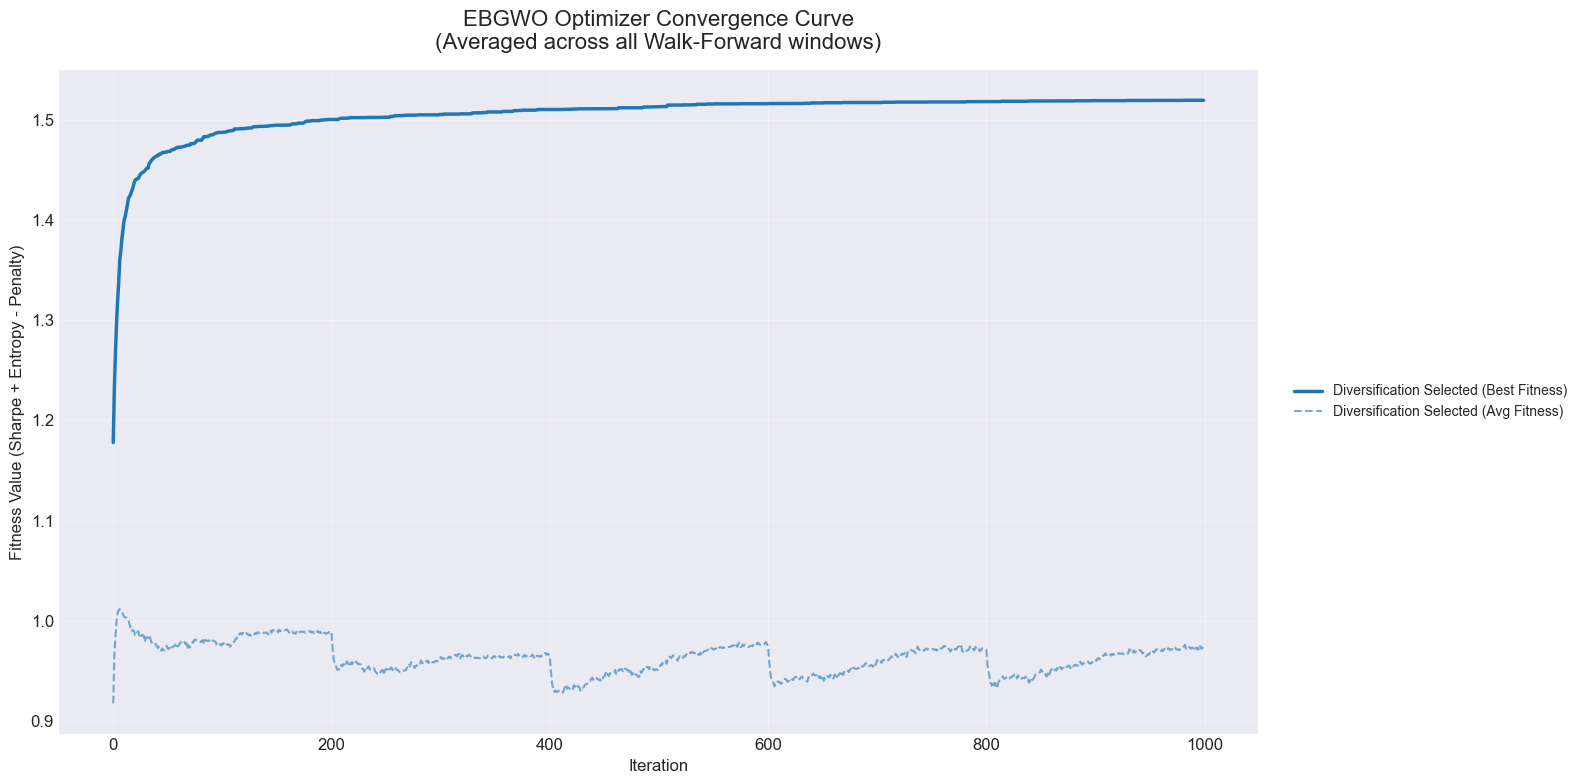


--- Starting Phase 6: Year 2025 Analysis ---


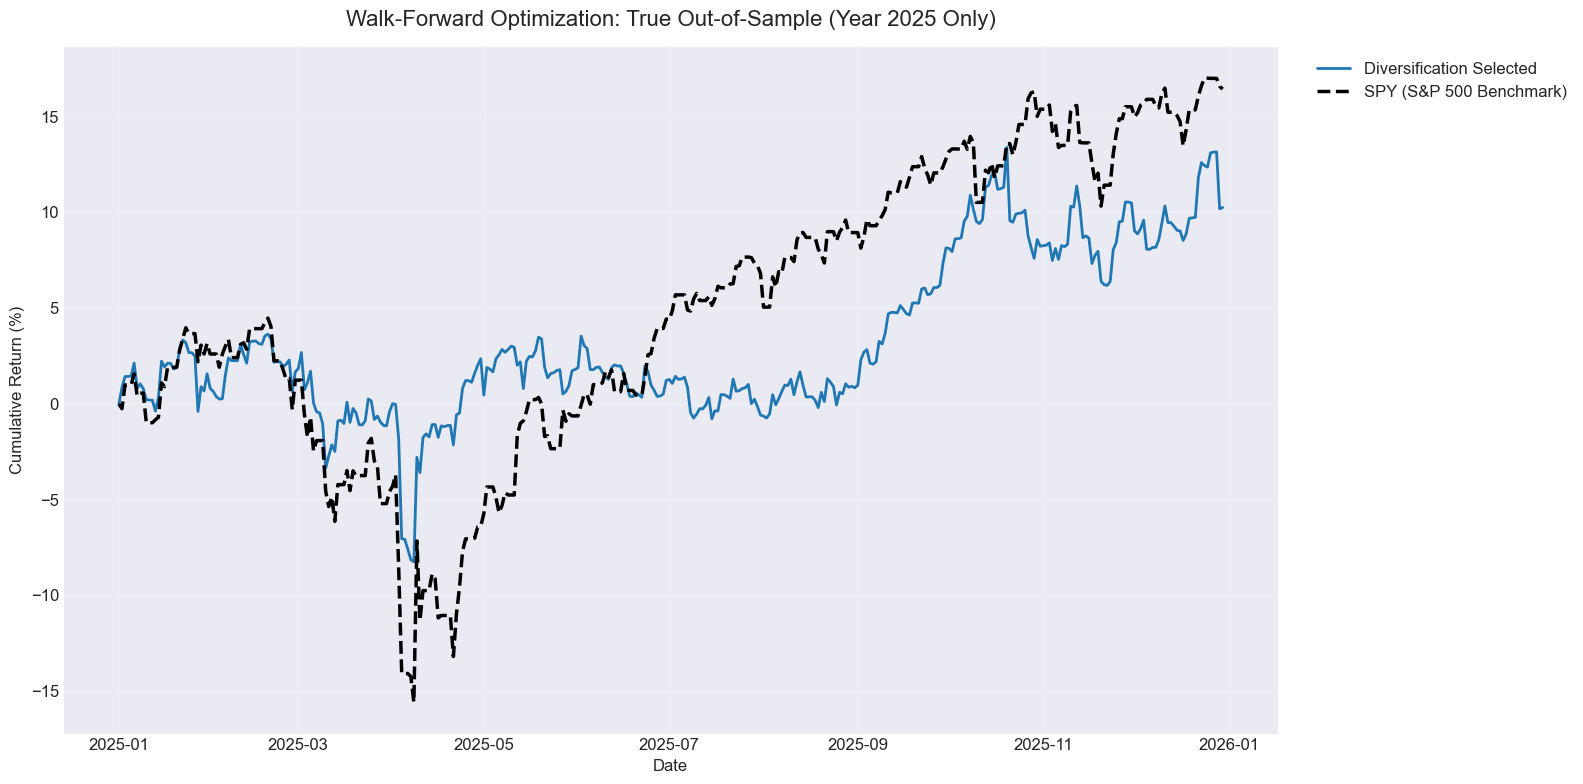


=== Walk-Forward Performance Metrics (Year 2025 Only) ===
Strategy Name                       | Cum Return | Ann Ret  | Ann Vol  | Sharpe  | Max DD  
-------------------------------------------------------------------------------------
Diversification Selected            |    10.26% |   7.60% |  12.98% |  0.2516 | -11.48%
-------------------------------------------------------------------------------------
SPY (Benchmark)                     |    16.44% |  11.81% |  15.98% |  0.4674 | -19.21%


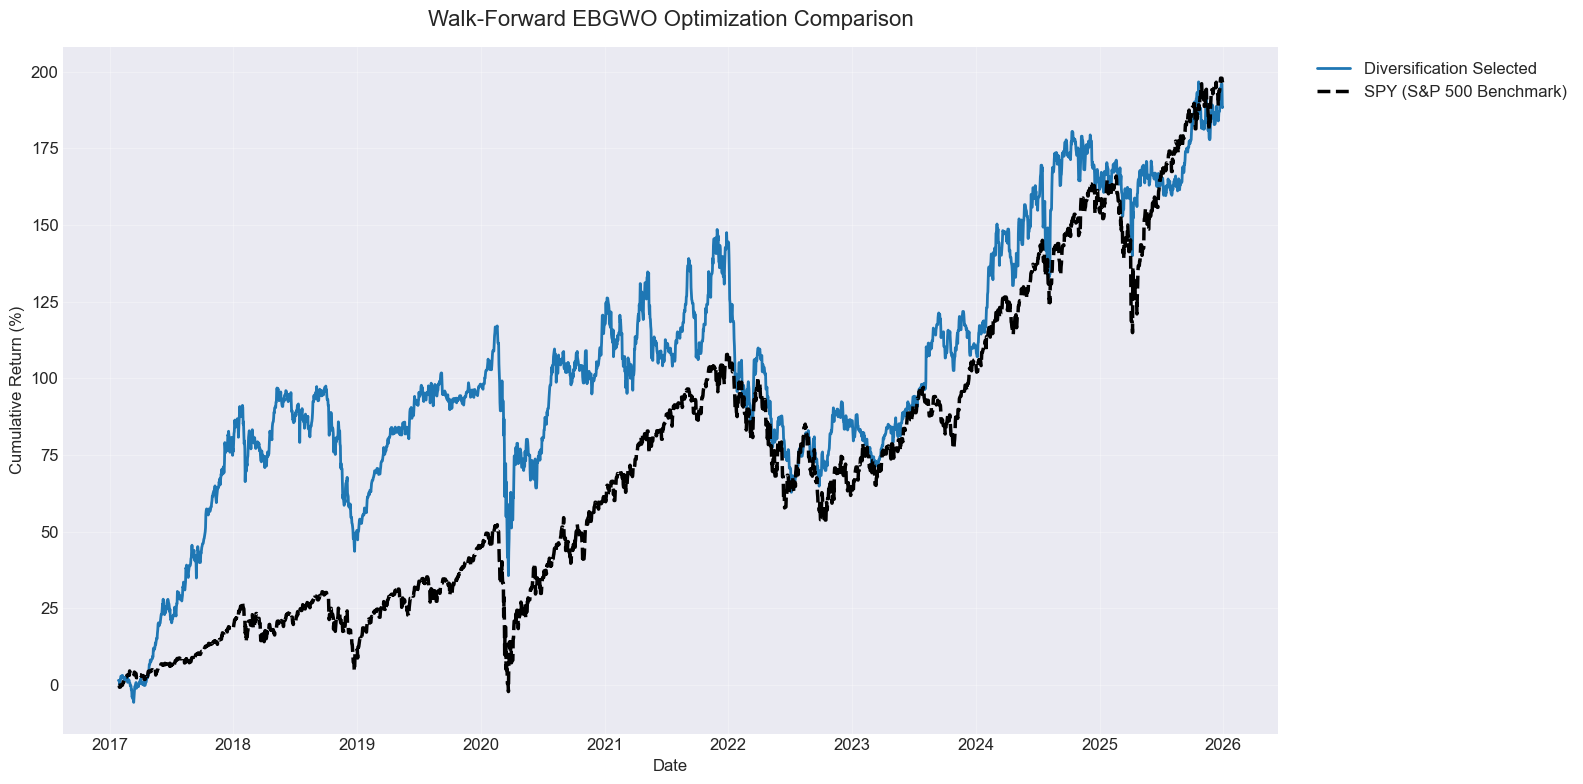


Strategy Name                       | Cum Return | Ann Ret  | Ann Vol  | Sharpe  | Max DD  
--------------------------------------------------------------------------------
Diversification Selected            |   188.40% |   9.66% |  17.09% |  0.5648 | -37.52%
--------------------------------------------------------------------------------
SPY (Benchmark)                     |   196.39% |   9.60% |  15.42% |  0.6222 | -35.75%


In [171]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance 

# ---------------------------------------------------------
# 1. ฟังก์ชัน EBGWO (เดิมของคุณ)
# ---------------------------------------------------------
def ledoit_wolf_covariance_gpu_dynamic(X):
    """ฟังก์ชัน Ledoit-Wolf Dynamic Shrinkage ที่คุณให้มา"""
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # 4. คำนวณ Dynamic Delta (Optimal Shrinkage)
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    X_squared = X_centered ** 2
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # 5. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()


import torch
import numpy as np
import math

def optimize_weights_aco_ebgwo(train_returns_gpu, target_assets, heuristic_tensor=None, sector_labels=None, 
                               num_iterations=2000, num_agents=500):
    """
    Co-Evolutionary Optimization: ACO (Asset Selection) + EBGWO (Weight Allocation)
    *อัปเดต: เพิ่มการเก็บค่า Convergence ทั้ง Best และ Average Fitness*
    """
    device = train_returns_gpu.device
    num_days, num_assets = train_returns_gpu.shape
    RISK_FREE_RATE = 0.0434
    
    # 1. เตรียม Correlation Matrix บน GPU
    mean_returns = train_returns_gpu.mean(dim=0, keepdim=True)
    centered_returns = train_returns_gpu - mean_returns
    cov_matrix = torch.matmul(centered_returns.T, centered_returns) / (num_days - 1)
    std_dev = torch.sqrt(torch.diag(cov_matrix))
    full_corr_tensor = cov_matrix / torch.outer(std_dev, std_dev)
    
    # 2. จัดการ Heuristic & Sectors
    if heuristic_tensor is None:
        train_ann_ret = train_returns_gpu.mean(dim=0) * 252
        train_ann_vol = train_returns_gpu.std(dim=0) * math.sqrt(252)
        heuristic_tensor = torch.clamp(train_ann_ret / (train_ann_vol + 1e-8), min=0.01)
        
    if sector_labels is None:
        sector_labels = torch.zeros(num_assets, dtype=torch.int64, device=device)
        unique_sectors = [0]
        min_per_sector = 0
    else:
        unique_sectors = torch.unique(sector_labels).tolist()
        min_per_sector = 1 

    # --- Hyperparameters ---
    alpha_aco = 1.0
    beta_aco = 2.0
    evaporation_rate = 0.1
    Q = 1.0
    PHEROMONE_MIN = 0.1
    PHEROMONE_MAX = 10.0
    pheromones = torch.ones(num_assets, dtype=torch.float32, device=device)

    # EBGWO Params
    ST = 0.3 
    wolves = torch.rand((num_agents, target_assets), dtype=torch.float32, device=device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True) 

    stagnation_counter = 0
    patience = 300 

    sqrt_252 = torch.tensor(math.sqrt(252), dtype=torch.float32, device=device)
    global_best_fitness = -float('inf')
    global_best_portfolio = None
    global_best_weights = None
    
    # [NEW] เตรียม List สำหรับเก็บข้อมูล Convergence
    convergence_curve = []
    avg_convergence_curve = [] 

    # =========================================================
    # Co-Evolutionary Loop
    # =========================================================
    for iteration in range(num_iterations):
        
        # --- 1. ACO: Asset Selection Phase ---
        probabilities = (pheromones ** alpha_aco) * (heuristic_tensor ** beta_aco)
        probabilities = probabilities / probabilities.sum()
        probs_batch = probabilities.unsqueeze(0).expand(num_agents, -1)
        
        probs_remaining = probs_batch.clone()
        mandatory_selections = []
        
        for sector_idx in unique_sectors:
            sector_mask = (sector_labels == sector_idx).float()
            probs_sector = probs_remaining * sector_mask.unsqueeze(0)
            
            epsilon = 1e-8
            probs_sector = probs_sector + (sector_mask.unsqueeze(0) * epsilon)
            
            available_in_sector = int(sector_mask.sum().item())
            actual_req = min(min_per_sector, available_in_sector)
            
            if actual_req > 0:
                selected_s = torch.multinomial(probs_sector, actual_req, replacement=False)
                mandatory_selections.append(selected_s)
                probs_remaining.scatter_(1, selected_s, 0.0)
                
        if mandatory_selections:
            selected_mandatory = torch.cat(mandatory_selections, dim=1)
        else:
            selected_mandatory = torch.empty((num_agents, 0), dtype=torch.int64, device=device)

        num_mandatory = selected_mandatory.shape[1]
        num_remaining = target_assets - num_mandatory
        
        if num_remaining > 0:
            selected_rem = torch.multinomial(probs_remaining, num_remaining, replacement=False)
            selected_indices = torch.cat([selected_mandatory, selected_rem], dim=1) 
        else:
            selected_indices = selected_mandatory[:, :target_assets]
            
        # --- 2. UNIFIED FITNESS CALCULATION ---
        idx_row = selected_indices.unsqueeze(2) 
        idx_col = selected_indices.unsqueeze(1) 
        batch_corr_matrices = full_corr_tensor[idx_row, idx_col] 
        sum_corrs = batch_corr_matrices.sum(dim=(1, 2))
        
        if target_assets > 1:
            avg_pairwise_corr = (sum_corrs - target_assets) / (target_assets * (target_assets - 1))
        else:
            avg_pairwise_corr = torch.ones_like(sum_corrs)

        decorrelation_fitness = 1.0 - avg_pairwise_corr
        
        mask = torch.zeros((num_agents, num_assets), device=device)
        mask.scatter_(1, selected_indices, wolves) 
        
        portfolio_returns = torch.matmul(train_returns_gpu, mask.T)
        port_ann_return = portfolio_returns.mean(dim=0) * 252
        port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
        
        portfolio_sharpe = torch.where(port_ann_vol > 0, 
                                      (port_ann_return - RISK_FREE_RATE) / port_ann_vol, 
                                      torch.zeros_like(port_ann_return))
        
        unified_fitness = portfolio_sharpe * decorrelation_fitness
        
        # --- 3. GLOBAL BEST TRACKING & STAGNATION CHECK ---
        sorted_indices = torch.argsort(unified_fitness, descending=True)
        best_agent_idx = sorted_indices[0]
        iter_best_fitness = unified_fitness[best_agent_idx].item()
        
        # [NEW] คำนวณค่าเฉลี่ย Fitness ของประชากรในรอบนี้
        avg_fitness = unified_fitness.mean().item()
        
        if iter_best_fitness > global_best_fitness:
            global_best_fitness = iter_best_fitness
            global_best_portfolio = selected_indices[best_agent_idx].clone()
            global_best_weights = wolves[best_agent_idx].clone()
            stagnation_counter = 0 
        else:
            stagnation_counter += 1 
            
        # [NEW] บันทึกข้อมูล Convergence
        convergence_curve.append(global_best_fitness)
        avg_convergence_curve.append(avg_fitness)
        
        # --- 4. ESCAPE MECHANISM ---
        if stagnation_counter > patience:
            mean_pheromone = pheromones.mean().item()
            pheromones = torch.ones_like(pheromones) * mean_pheromone
            
            num_reset = num_agents // 2
            reset_indices = sorted_indices[-num_reset:]
            new_random_wolves = torch.rand((num_reset, target_assets), dtype=torch.float32, device=device)
            new_random_wolves = new_random_wolves / new_random_wolves.sum(dim=1, keepdim=True)
            wolves[reset_indices] = new_random_wolves
            
            stagnation_counter = 0 

        # --- 5. UPDATES (ACO & EBGWO) ---
        pheromones *= (1 - evaporation_rate)
        pheromones[selected_indices[best_agent_idx]] += Q * iter_best_fitness
        pheromones = torch.clamp(pheromones, PHEROMONE_MIN, PHEROMONE_MAX)

        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        
        a = 2.0 * (1.0 - (iteration % (num_iterations // 5)) / (num_iterations // 5)) 
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        D_alpha = torch.abs(C1 * alpha_pos - wolves)
        X1 = alpha_pos - A1 * D_alpha
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        D_beta = torch.abs(C2 * beta_pos - wolves)
        X2 = beta_pos - A2 * D_beta
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        
        exploration_mask = torch.rand((num_agents, 1), device=device) < ST
        random_wolves = wolves[torch.randint(0, num_agents, (num_agents,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        
        D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
        X3 = delta_or_random_pos - A3 * D_delta
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    final_full_weights = torch.zeros(num_assets, device=device)
    if global_best_portfolio is not None and global_best_weights is not None:
        final_full_weights[global_best_portfolio] = global_best_weights
        
    # [NEW] รีเทิร์นค่าทั้ง Best และ Average Convergence กลับไป
    return final_full_weights.cpu().numpy(), convergence_curve, avg_convergence_curve

# ---------------------------------------------------------
# 2. ดึง Ticker ทั้งหมดแบบไม่ซ้ำ และดาวน์โหลดข้อมูลครั้งเดียว
# ---------------------------------------------------------
print("--- Extracting Unique Tickers from all Portfolios ---")
all_unique_tickers = set()

for name, df in portfolio_dfs.items():
    # ตรวจสอบว่า Ticker อยู่ที่ Index หรือ Column
    tickers = df.index.tolist() if df.index.name == 'Ticker' else df['Ticker'].tolist()
    all_unique_tickers.update(tickers)

all_unique_tickers = list(all_unique_tickers)
print(f"Total unique assets to download: {len(all_unique_tickers)}")

start_date = '2015-01-01' 
end_date = '2025-12-31'
all_download_tickers = all_unique_tickers + ['SPY']

print(f"Downloading full dataset for Walk-Forward...")
ull_data = yf.download(all_tickers, start=start_date, end="2025-12-31")['Close']

# จัดการ Missing Data
max_gap = 365
mask = full_data.isnull().rolling(window=max_gap).sum()
cols_with_long_strips = (mask == max_gap).any()
data = full_data.loc[:, ~cols_with_long_strips].copy()
full_data = data.ffill().bfill()

# Currency Conversion: All Prices to THB
data_filtered = full_data.copy()
print("Downloading USD/THB exchange rate...")
try:
    usdthb_raw = yf.download("USDTHB=X", start=start_date, end=end_date, auto_adjust=True)
    if isinstance(usdthb_raw.columns, pd.MultiIndex):
        usdthb = usdthb_raw['Close'].iloc[:, 0]
    else:
        usdthb = usdthb_raw['Close']
    usdthb = usdthb.reindex(data_filtered.index).ffill().bfill()
    print(f"  USD/THB range: {float(usdthb.min()):.2f} - {float(usdthb.max()):.2f}")
except Exception as e:
    print(f"  Warning: Could not download USD/THB ({e})")
    print("  Using fixed rate: 35.00 THB/USD")
    usdthb = pd.Series(35.0, index=data_filtered.index)

full_data = data_filtered.copy()

thai_cols = [t for t in data_filtered.columns if t.endswith(".BK")]
usd_cols = [t for t in data_filtered.columns if not t.endswith(".BK")]

for ticker in usd_cols:
    data_thb[ticker] = data_filtered[ticker] * usdthb.values.flatten()

print(f"\nConverted {len(usd_cols)} USD assets to THB")
print(f"Thai assets ({len(thai_cols)}): already in THB")

data = data_thb

# คำนวณ Log Returns สำหรับหุ้นทั้งหมด
full_returns = np.log(full_data / full_data.shift(1)).dropna()
spy_full_returns = full_returns['SPY']

# ---------------------------------------------------------
# 3. สร้างฟังก์ชันเพื่อรัน Pipeline สำหรับแต่ละพอร์ต
# ---------------------------------------------------------
def run_walk_forward_for_portfolio(portfolio_name, selected_stocks, full_returns, spy_full_returns):
    print(f"\n[{portfolio_name}] Starting Walk-Forward Optimization (ACO + EBGWO)...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    valid_selected_stocks = [t for t in selected_stocks if t in full_returns.columns]
    port_full_returns = full_returns[valid_selected_stocks]
    returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

    LOOKBACK_WINDOW = 252 * 3  
    STEP_SIZE = 21 * 3         
    total_days = returns_gpu_full.shape[0]
    
    target_assets_count = max(5, len(valid_selected_stocks) // 2) 
    
    out_of_sample_port_returns = []
    
    # ตัวแปรเก็บ convergence ของทุกๆ window
    all_best_conv = []
    all_avg_conv = []

    for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
        train_end = start_idx + LOOKBACK_WINDOW
        test_end = min(train_end + STEP_SIZE, total_days)
        
        train_returns = returns_gpu_full[start_idx:train_end]
        
        best_weights_full, conv_b, conv_a = optimize_weights_aco_ebgwo(
            train_returns_gpu=train_returns,
            target_assets=target_assets_count, 
            heuristic_tensor=None,
            sector_labels=None,    
            num_iterations=1000,  
            num_agents=500
        )
        
        # เก็บ convergence ไว้คำนวณตอนจบ
        all_best_conv.append(conv_b)
        all_avg_conv.append(conv_a) 

        test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
        period_port_return = (test_returns_cpu * best_weights_full).sum(axis=1)
        out_of_sample_port_returns.extend(period_port_return)
        
    # คำนวณ Metrics
    port_returns_arr = np.array(out_of_sample_port_returns)
    cum_port_returns = np.cumprod(1 + port_returns_arr) - 1
    
    wf_cum_return = cum_port_returns[-1]
    wf_ann_return = np.mean(port_returns_arr) * 252
    wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
    wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
    
    rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
    drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
    wf_max_dd = np.min(drawdown_port)
    
    # [NEW] คำนวณค่าเฉลี่ย Convergence (Best และ Average) ของทุก Windows
    max_len = max([len(c) for c in all_best_conv])
    
    padded_best_conv = [np.pad(c, (0, max_len - len(c)), 'edge') for c in all_best_conv]
    avg_best_conv_overall = np.mean(padded_best_conv, axis=0)
    
    padded_avg_conv = [np.pad(c, (0, max_len - len(c)), 'edge') for c in all_avg_conv]
    avg_avg_conv_overall = np.mean(padded_avg_conv, axis=0)
    
    return {
        "Strategy": portfolio_name,
        "Cum Return": wf_cum_return,
        "Ann Return": wf_ann_return,
        "Ann Volatility": wf_ann_vol,
        "Sharpe Ratio": wf_sharpe,
        "Max Drawdown": wf_max_dd,
        "OOS_Returns_Array": port_returns_arr,
        "OOS_Cum_Returns_Array": cum_port_returns,
        "Avg_Best_Convergence": avg_best_conv_overall,
        "Avg_Avg_Convergence": avg_avg_conv_overall  # ส่งกลับไปพล็อตกราฟได้เลย
    }
# ---------------------------------------------------------
# 4. วนลูปผ่านทุก DataFrame ใน portfolio_dfs
# ---------------------------------------------------------
all_strategy_results = []
spy_oos_returns = None
trade_dates = None

for name, df in portfolio_dfs.items():
    selected_stocks = returns.columns
    
    res = run_walk_forward_for_portfolio(name, selected_stocks, full_returns, spy_full_returns)
    all_strategy_results.append(res)
    
    # เก็บ Benchmark Date และ SPY Returns เพียงครั้งเดียวจากลูปแรก
    if spy_oos_returns is None:
        LOOKBACK_WINDOW = 252 * 3
        test_len = len(res["OOS_Returns_Array"])
        trade_dates = full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + test_len]
        
        # คราฟต์ SPY Out of sample ตามช่วงเวลาเดียวกัน
        spy_returns_arr = spy_full_returns.iloc[LOOKBACK_WINDOW : LOOKBACK_WINDOW + test_len].values
        spy_returns_daily_arr = spy_returns_arr # <--- เพิ่มบรรทัดนี้เพื่อเก็บรายวันไว้ใช้ใน Step 6
        spy_cum_returns = np.cumprod(1 + spy_returns_arr) - 1
        
        spy_ann_return = np.mean(spy_returns_arr) * 252
        spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)
        spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0
        
        rolling_max_spy = np.maximum.accumulate(1 + spy_cum_returns)
        spy_max_dd = np.min((1 + spy_cum_returns) / rolling_max_spy - 1)
        
        spy_oos_returns = spy_cum_returns
    break

# =========================================================
# กราฟ Convergence (Average vs Best Fitness)
# =========================================================
print("\n--- Generating Convergence Graph ---")

plt.figure(figsize=(16, 8))

# ใช้สีที่แตกต่างกันสำหรับแต่ละพอร์ต
colors = plt.cm.tab10(np.linspace(0, 1, len(all_strategy_results)))

for idx, res in enumerate(all_strategy_results):
    strat_name = res["Strategy"]
    best_conv = res["Avg_Best_Convergence"]
    avg_conv = res["Avg_Avg_Convergence"]
    
    # พล็อต Best Fitness (เส้นทึบ)
    plt.plot(best_conv, label=f"{strat_name} (Best Fitness)", 
             color=colors[idx], linewidth=2.5)
    
    # พล็อต Average Fitness (เส้นประ ทึบแสงน้อยกว่า)
    plt.plot(avg_conv, label=f"{strat_name} (Avg Fitness)", 
             color=colors[idx], linewidth=1.5, linestyle='--', alpha=0.6)

plt.title('EBGWO Optimizer Convergence Curve\n(Averaged across all Walk-Forward windows)', fontsize=16, pad=15)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Fitness Value (Sharpe + Entropy - Penalty)', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10) # จัดให้อยู่ด้านขวากลาง ไม่บังเส้น
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 6. วิเคราะห์ผลตอบแทนเฉพาะปี 2025 (Year 2025 Only)
# =========================================================
print("\n" + "="*80)
print("--- Starting Phase 6: Year 2025 Analysis ---")

# สร้างเงื่อนไขเพื่อกรองเฉพาะวันที่อยู่ในปี 2025
mask_2025 = trade_dates.year == 2025

if not mask_2025.any():
    print("⚠️ ไม่มีข้อมูลสำหรับปี 2025 ในชุดทดสอบ (Out-of-Sample)")
else:
    dates_2025 = trade_dates[mask_2025]
    
    # ---------------------------------------------------------
    # คำนวณ SPY (Benchmark) เฉพาะปี 2025
    # ---------------------------------------------------------
    spy_returns_2025 = spy_returns_daily_arr[mask_2025]
    cum_spy_2025 = np.cumprod(1 + spy_returns_2025) - 1
    
    spy_cum_ret_25 = cum_spy_2025[-1] if len(cum_spy_2025) > 0 else 0
    spy_ann_ret_25 = np.mean(spy_returns_2025) * 252
    spy_ann_vol_25 = np.std(spy_returns_2025) * math.sqrt(252)
    spy_sharpe_25 = (spy_ann_ret_25 - 0.0434) / spy_ann_vol_25 if spy_ann_vol_25 > 0 else 0
    
    rolling_max_spy_25 = np.maximum.accumulate(1 + cum_spy_2025)
    spy_max_dd_25 = np.min((1 + cum_spy_2025) / rolling_max_spy_25 - 1) if len(cum_spy_2025) > 0 else 0
    
    results_2025 = []
    
    # ---------------------------------------------------------
    # คำนวณแต่ละ Portfolio และพล็อตกราฟเฉพาะปี 2025
    # ---------------------------------------------------------
    plt.figure(figsize=(16, 8))
    
    for res in all_strategy_results:
        # ดึง Daily Return เฉพาะปี 2025 จากที่เก็บไว้ใน Step 3-4
        port_returns_2025 = res["OOS_Returns_Array"][mask_2025]
        
        # 1. คำนวณ Cumulative Return (เริ่มนับ 0 ใหม่ใน 2025)
        cum_port_2025 = np.cumprod(1 + port_returns_2025) - 1
        
        wf_cum_ret_25 = cum_port_2025[-1] if len(cum_port_2025) > 0 else 0
        wf_ann_ret_25 = np.mean(port_returns_2025) * 252
        wf_ann_vol_25 = np.std(port_returns_2025) * math.sqrt(252)
        wf_sharpe_25 = (wf_ann_ret_25 - 0.0434) / wf_ann_vol_25 if wf_ann_vol_25 > 0 else 0
        
        rolling_max_port_25 = np.maximum.accumulate(1 + cum_port_2025)
        wf_max_dd_25 = np.min((1 + cum_port_2025) / rolling_max_port_25 - 1) if len(cum_port_2025) > 0 else 0
        
        # เก็บผลลัพธ์ลง List
        results_2025.append({
            "Strategy": res["Strategy"],
            "Cum Return": wf_cum_ret_25,
            "Ann Return": wf_ann_ret_25,
            "Ann Vol": wf_ann_vol_25,
            "Sharpe": wf_sharpe_25,
            "Max DD": wf_max_dd_25
        })
        
        # พล็อตกราฟสำหรับพอร์ตนี้
        plt.plot(dates_2025, cum_port_2025 * 100, label=res["Strategy"], linewidth=2)
        
    # พล็อต SPY
    plt.plot(dates_2025, cum_spy_2025 * 100, label='SPY (S&P 500 Benchmark)', color='black', linestyle='--', linewidth=2.5)
    
    # วาดเส้นประแสดงวัน Rebalance (เฉพาะปี 2025)
    # สมมติว่าดึงวันที่ Rebalance แรกสุดของพอร์ตแรกมาใช้เพื่อไม่ให้รกเกินไป
    # *ถ้าไม่ได้เก็บ rebalance_dates ไว้ใน Loop ก่อนหน้า สามารถข้ามการวาดเส้นประได้*
    
    plt.title('Walk-Forward Optimization: True Out-of-Sample (Year 2025 Only)', fontsize=16, pad=15)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return (%)')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # แสดงตารางเปรียบเทียบปี 2025
    # ---------------------------------------------------------
    print("\n=== Walk-Forward Performance Metrics (Year 2025 Only) ===")
    print(f"{'Strategy Name':<35} | {'Cum Return':<10} | {'Ann Ret':<8} | {'Ann Vol':<8} | {'Sharpe':<7} | {'Max DD':<8}")
    print("-" * 85)

    for r25 in results_2025:
        print(f"{r25['Strategy']:<35} | {r25['Cum Return']:>9.2%} | {r25['Ann Return']:>7.2%} | {r25['Ann Vol']:>7.2%} | {r25['Sharpe']:>7.4f} | {r25['Max DD']:>7.2%}")

    print("-" * 85)
    print(f"{'SPY (Benchmark)':<35} | {spy_cum_ret_25:>9.2%} | {spy_ann_ret_25:>7.2%} | {spy_ann_vol_25:>7.2%} | {spy_sharpe_25:>7.4f} | {spy_max_dd_25:>7.2%}")
    print("=" * 85)

# กราฟรวมทุกพอร์ต
plt.figure(figsize=(16, 8))
for res in all_strategy_results:
    plt.plot(trade_dates, res["OOS_Cum_Returns_Array"] * 100, label=res["Strategy"], linewidth=2)

plt.plot(trade_dates, spy_oos_returns * 100, label='SPY (S&P 500 Benchmark)', color='black', linestyle='--', linewidth=2.5)

plt.title('Walk-Forward EBGWO Optimization Comparison', fontsize=16, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1)) # นำ Legend ไว้ด้านขวาไม่บังเส้น
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ตารางเปรียบเทียบ
print("\n" + "="*80)
print(f"{'Strategy Name':<35} | {'Cum Return':<10} | {'Ann Ret':<8} | {'Ann Vol':<8} | {'Sharpe':<7} | {'Max DD':<8}")
print("-" * 80)

for res in all_strategy_results:
    print(f"{res['Strategy']:<35} | {res['Cum Return']:>9.2%} | {res['Ann Return']:>7.2%} | {res['Ann Volatility']:>7.2%} | {res['Sharpe Ratio']:>7.4f} | {res['Max Drawdown']:>7.2%}")

# พิมพ์ SPY ท้ายตาราง
print("-" * 80)
print(f"{'SPY (Benchmark)':<35} | {spy_cum_returns[-1]:>9.2%} | {spy_ann_return:>7.2%} | {spy_ann_vol:>7.2%} | {spy_sharpe:>7.4f} | {spy_max_dd:>7.2%}")
print("=" * 80)


Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,...,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578,0.000578
2015-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-01-05,-0.011824,-0.021485,-0.011907,0.007314,0.001089,-0.009937,0.002103,-0.011261,-0.028123,0.006371,...,-0.000117,0.007091,-0.010074,-0.004325,-0.020652,-0.057167,-0.013436,0.043716,-0.007086,0.001070
2015-01-06,-0.021242,-0.005447,-0.010504,-0.016963,-0.003308,-0.012781,-0.025892,-0.029295,-0.025452,-0.013867,...,-0.010528,-0.006650,-0.027104,-0.000235,-0.010872,-0.011440,-0.017892,-0.014054,-0.012772,-0.015346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,-0.001001,-0.000555,0.000607,0.004041,-0.000665,0.000030,-0.004723,0.001338,-0.004116,-0.005080,...,-0.000195,0.002674,-0.005147,-0.004155,-0.005783,0.005594,0.003370,-0.003464,-0.000021,0.006063
2023-12-28,-0.008396,-0.005815,-0.008878,-0.002498,-0.000993,-0.014362,-0.008979,-0.003584,-0.006655,-0.004247,...,-0.004439,0.001695,0.004352,-0.002368,-0.022605,-0.008564,-0.010488,-0.003920,-0.009636,-0.006719
2023-12-29,-0.000844,-0.002665,0.004195,-0.000219,0.005606,0.000839,0.004586,-0.005651,0.002082,0.004837,...,0.010599,-0.006672,-0.004335,0.003097,0.000676,0.003124,0.003847,0.003350,-0.004589,0.003839


In [166]:
sector_labels = all_summary['Sector'].unique()  # ตัวอย่างสำหรับ 6 สินทรัพย์ แบ่งเป็น 3 sectors

In [167]:
sector_labels

<StringArray>
[           'Health Care', 'Information Technology',             'Financials',
       'Consumer Staples',            'Industrials',            'Thai Stocks',
              'Utilities',                  'Bonds',              'Materials',
            'Real Estate', 'Consumer Discretionary',                 'Energy',
         'Chinese Stocks',                 'Crypto', 'Communication Services',
            'Commodities',                 'US ETF',                 'EM ETF',
               'Intl ETF',              'China ETF',               'Thai ETF']
Length: 21, dtype: str